<a href="https://colab.research.google.com/github/ebrahimbasrai/S-P500-Analysis/blob/main/S%26P_500_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://tickericons.com/changes

https://en.wikipedia.org/wiki/List_of_S%26P_500_companies



In [ ]:
import pandas as pd

file_path = "/content/S&P 500 Data DUMP - Downloadable DAta.csv"

df = pd.read_csv(file_path)

print("COLUMNS:")
print(df.columns.tolist())

print("\nTABLE SIZE:")
print(df.shape)

print("\nFIRST 5 ROWS:")
print(df.head())

COLUMNS:
['Symbol', 'Price Jan 2019', 'Price Jan 2020', 'Price Jan 2021', 'Price Jan 2022', 'Price Jan 2023', 'Price Jan 2024', 'Price Jan 2025', 'Price Jan 2026']

TABLE SIZE:
(503, 9)

FIRST 5 ROWS:
  Symbol  Price Jan 2019  Price Jan 2020  Price Jan 2021  Price Jan 2022  \
0    BAX           65.30           85.87           80.12           86.87   
1    ARE          111.37          159.73          170.77          219.83   
2   VTRS           27.92           20.65           18.54           14.21   
3   ILMN          286.26          317.83          357.44          370.18   
4    IFF          134.58          127.55          105.08          149.12   

   Price Jan 2023  Price Jan 2024  Price Jan 2025  Price Jan 2026  
0           51.04           38.85           29.26           19.50  
1          144.11          129.31           97.50           48.97  
2           11.38           11.39           12.42           12.46  
3          195.23          133.75          130.93          134.35  
4 

In [ ]:
import pandas as pd
import numpy as np

# Ensure price columns are numeric
df["Price Jan 2019"] = pd.to_numeric(
    df["Price Jan 2019"],
    errors="coerce"
)

df["Price Jan 2026"] = pd.to_numeric(
    df["Price Jan 2026"],
    errors="coerce"
)

# Keep stocks with valid prices in both years
price_change_df = df[
    df["Price Jan 2019"].notna()
    & df["Price Jan 2026"].notna()
    & df["Price Jan 2019"].ne(0)
].copy()

# Calculate dollar and percentage changes
price_change_df["Dollar Change"] = (
    price_change_df["Price Jan 2026"]
    - price_change_df["Price Jan 2019"]
)

price_change_df["Percent Change"] = (
    price_change_df["Dollar Change"]
    / price_change_df["Price Jan 2019"]
) * 100

# Sort from biggest percentage loser to biggest winner
price_change_df = price_change_df.sort_values(
    "Percent Change",
    ascending=True
).reset_index(drop=True)

# Round calculated values
price_change_df["Dollar Change"] = (
    price_change_df["Dollar Change"].round(2)
)

price_change_df["Percent Change"] = (
    price_change_df["Percent Change"].round(2)
)

# Select output columns
price_change_df = price_change_df[
    [
        "Symbol",
        "Price Jan 2019",
        "Price Jan 2026",
        "Dollar Change",
        "Percent Change"
    ]
]

# Biggest loser
biggest_loser = price_change_df.iloc[0]

print("BIGGEST LOSER:")
print(biggest_loser)

print("\nTOP 10 BIGGEST LOSERS:")
print(price_change_df.head(10).to_string(index=False))

BIGGEST LOSER:
Symbol              BAX
Price Jan 2019     65.3
Price Jan 2026     19.5
Dollar Change     -45.8
Percent Change   -70.14
Name: 0, dtype: object

TOP 10 BIGGEST LOSERS:
Symbol  Price Jan 2019  Price Jan 2026  Dollar Change  Percent Change
   BAX           65.30           19.50         -45.80          -70.14
   ARE          111.37           48.97         -62.40          -56.03
  VTRS           27.92           12.46         -15.46          -55.37
  ILMN          286.26          134.35        -151.91          -53.07
   IFF          134.58           68.03         -66.55          -49.45
   LYB           83.89           44.39         -39.50          -47.09
  NCLH           42.38           22.78         -19.60          -46.25
   KHC           43.34           24.39         -18.95          -43.72
   HRL           41.33           23.39         -17.94          -43.41
  BF.B           46.07           26.14         -19.93          -43.26


In [ ]:
import pandas as pd
import numpy as np

# Define the years in chronological order
years = list(range(2019, 2027))

# Convert all price columns to numeric
for year in years:
    column = f"Price Jan {year}"
    df[column] = pd.to_numeric(df[column], errors="coerce")

yearly_changes = []

# Calculate changes between consecutive years
for previous_year, current_year in zip(years[:-1], years[1:]):
    previous_column = f"Price Jan {previous_year}"
    current_column = f"Price Jan {current_year}"

    valid_rows = (
        df[previous_column].notna()
        & df[current_column].notna()
        & df[previous_column].ne(0)
    )

    yearly_df = df.loc[
        valid_rows,
        ["Symbol", previous_column, current_column]
    ].copy()

    yearly_df["Period"] = (
        f"{previous_year}-{current_year}"
    )

    yearly_df["Dollar Change"] = (
        yearly_df[current_column]
        - yearly_df[previous_column]
    )

    yearly_df["Percent Change"] = (
        yearly_df["Dollar Change"]
        / yearly_df[previous_column]
        * 100
    )

    yearly_df = yearly_df.rename(
        columns={
            previous_column: "Starting Price",
            current_column: "Ending Price"
        }
    )

    yearly_changes.append(
        yearly_df[
            [
                "Symbol",
                "Period",
                "Starting Price",
                "Ending Price",
                "Dollar Change",
                "Percent Change"
            ]
        ]
    )

# Combine all year-to-year changes
yearly_changes_df = pd.concat(
    yearly_changes,
    ignore_index=True
)

# Round calculated values
yearly_changes_df["Dollar Change"] = (
    yearly_changes_df["Dollar Change"].round(2)
)

yearly_changes_df["Percent Change"] = (
    yearly_changes_df["Percent Change"].round(2)
)

# Find the largest positive and negative percentage changes
biggest_positive_change = yearly_changes_df.loc[
    yearly_changes_df["Percent Change"].idxmax()
]

biggest_negative_change = yearly_changes_df.loc[
    yearly_changes_df["Percent Change"].idxmin()
]

print("BIGGEST POSITIVE YEAR-TO-YEAR CHANGE:")
print(biggest_positive_change)

print("\nBIGGEST NEGATIVE YEAR-TO-YEAR CHANGE:")
print(biggest_negative_change)

print("\nTOP 10 POSITIVE CHANGES:")
print(
    yearly_changes_df
    .sort_values("Percent Change", ascending=False)
    .head(10)
    .to_string(index=False)
)

print("\nTOP 10 NEGATIVE CHANGES:")
print(
    yearly_changes_df
    .sort_values("Percent Change", ascending=True)
    .head(10)
    .to_string(index=False)
)

BIGGEST POSITIVE YEAR-TO-YEAR CHANGE:
Symbol                 CVNA
Period            2023-2024
Starting Price         0.93
Ending Price           9.77
Dollar Change          8.84
Percent Change       950.54
Name: 2386, dtype: object

BIGGEST NEGATIVE YEAR-TO-YEAR CHANGE:
Symbol                 CVNA
Period            2022-2023
Starting Price        47.93
Ending Price           0.93
Dollar Change         -47.0
Percent Change       -98.06
Name: 1897, dtype: object

TOP 10 POSITIVE CHANGES:
Symbol    Period  Starting Price  Ending Price  Dollar Change  Percent Change
  CVNA 2023-2024            0.93          9.77           8.84          950.54
   APP 2024-2025           38.78        341.78         303.00          781.33
  TSLA 2020-2021           28.68        243.26         214.58          748.19
  MRNA 2020-2021           19.23        111.73          92.50          481.02
  ECHO 2025-2026           22.75        112.18          89.43          393.10
  COIN 2023-2024           33.60        1

In [ ]:
import pandas as pd

# Load the CSV
file_path = "/content/S&P 500 Data DUMP - Downloadable DAta.csv"
df = pd.read_csv(file_path)

# Define the available years
years = list(range(2019, 2027))

# Convert price columns to numeric
for year in years:
    price_column = f"Price Jan {year}"
    df[price_column] = pd.to_numeric(
        df[price_column],
        errors="coerce"
    )

# Create year-over-year percentage-change columns
for previous_year, current_year in zip(years[:-1], years[1:]):
    previous_column = f"Price Jan {previous_year}"
    current_column = f"Price Jan {current_year}"
    yoy_column = f"YoY {previous_year}-{current_year}"

    df[yoy_column] = (
        (df[current_column] - df[previous_column])
        / df[previous_column]
        * 100
    ).round(2)

# Save the updated dataset
output_path = "/content/sp500_data_with_yoy_changes.csv"

df.to_csv(
    output_path,
    index=False)



In [ ]:
import pandas as pd

yoy = pd.read_csv("/content/sp500_data_with_yoy_changes.csv")

yoy.head()

,Symbol,Price Jan 2019,Price Jan 2020,Price Jan 2021,Price Jan 2022,Price Jan 2023,Price Jan 2024,Price Jan 2025,Price Jan 2026,YoY 2019-2020,YoY 2020-2021,YoY 2021-2022,YoY 2022-2023,YoY 2023-2024,YoY 2024-2025,YoY 2025-2026
0,BAX,65.30,85.87,80.12,86.87,51.04,38.85,29.26,19.50,31.50,-6.70,8.42,-41.25,-23.88,-24.68,-33.36
1,ARE,111.37,159.73,170.77,219.83,144.11,129.31,97.50,48.97,43.42,6.91,28.73,-34.44,-10.27,-24.60,-49.77
2,VTRS,27.92,20.65,18.54,14.21,11.38,11.39,12.42,12.46,-26.04,-10.22,-23.35,-19.92,0.09,9.04,0.32
3,ILMN,286.26,317.83,357.44,370.18,195.23,133.75,130.93,134.35,11.03,12.46,3.56,-47.26,-31.49,-2.11,2.61
4,IFF,134.58,127.55,105.08,149.12,105.64,81.42,83.09,68.03,-5.22,-17.62,41.91,-29.16,-22.93,2.05,-18.12


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = "/content/sp500_data_with_yoy_changes.csv"
yoy = pd.read_csv(file_path)

# Price columns must be numeric
for year in range(2019, 2027):
    column = f"Price Jan {year}"
    yoy[column] = pd.to_numeric(
        yoy[column],
        errors="coerce"
    )

starting_balance = 1000.00
current_balance = starting_balance
trade_results = []

# 2020 selection uses 2019-2020 performance,
# then buys in January 2020 and sells in January 2021.
for selection_year in range(2020, 2026):
    performance_start_column = f"Price Jan {selection_year - 1}"
    purchase_column = f"Price Jan {selection_year}"
    sale_column = f"Price Jan {selection_year + 1}"

    valid_stocks = yoy[
        yoy[performance_start_column].notna()
        & yoy[purchase_column].notna()
        & yoy[sale_column].notna()
        & yoy[performance_start_column].gt(0)
        & yoy[purchase_column].gt(0)
    ].copy()

    # Calculate the previous year's return used for selection
    valid_stocks["Selection Return (%)"] = (
        (
            valid_stocks[purchase_column]
            - valid_stocks[performance_start_column]
        )
        / valid_stocks[performance_start_column]
        * 100
    )

    # Select the best-performing stock
    selected_stock = valid_stocks.loc[
        valid_stocks["Selection Return (%)"].idxmax()
    ]

    symbol = selected_stock["Symbol"]
    purchase_price = selected_stock[purchase_column]
    sale_price = selected_stock[sale_column]
    selection_return = selected_stock["Selection Return (%)"]

    # Invest the entire balance, including fractional shares
    shares_purchased = current_balance / purchase_price
    ending_balance = shares_purchased * sale_price

    investment_return = (
        (sale_price - purchase_price)
        / purchase_price
        * 100
    )

    trade_results.append({
        "Selection Period": (
            f"{selection_year - 1}-{selection_year}"
        ),
        "Investment Period": (
            f"{selection_year}-{selection_year + 1}"
        ),
        "Selected Stock": symbol,
        "Prior Year Performance (%)": round(selection_return, 2),
        "Purchase Price": round(purchase_price, 2),
        "Sale Price": round(sale_price, 2),
        "Shares Purchased": round(shares_purchased, 6),
        "Starting Balance": round(current_balance, 2),
        "Investment Return (%)": round(investment_return, 2),
        "Ending Balance": round(ending_balance, 2)
    })

    # Roll all proceeds into the next investment
    current_balance = ending_balance

# Create results table
strategy_results_df = pd.DataFrame(trade_results)

# Save results
output_path = "/content/best_previous_year_strategy_results.csv"

strategy_results_df.to_csv(
    output_path,
    index=False
)

print("STRATEGY RESULTS:")
print(strategy_results_df.to_string(index=False))

print("\nFINAL RESULT:")
print(f"Starting investment: ${starting_balance:,.2f}")
print(f"Final investment value: ${current_balance:,.2f}")
print(
    f"Total return: "
    f"{((current_balance / starting_balance) - 1) * 100:,.2f}%"
)

print(f"\nSaved to: {output_path}")

STRATEGY RESULTS:
Selection Period Investment Period Selected Stock  Prior Year Performance (%)  Purchase Price  Sale Price  Shares Purchased  Starting Balance  Investment Return (%)  Ending Balance
       2019-2020         2020-2021           CVNA                      200.62           19.39       47.25         51.572976           1000.00                 143.68         2436.82
       2020-2021         2021-2022           TSLA                      748.19          243.26      399.93         10.017360           2436.82                  64.40         4006.24
       2021-2022         2022-2023            DVN                      182.52           45.57       58.12         87.914044           4006.24                  27.54         5109.56
       2022-2023         2023-2024            OXY                       96.56           61.05       60.05         83.694746           5109.56                  -1.64         5025.87
       2023-2024         2024-2025           CVNA                      950.54

In [ ]:
# Find stocks with valid 2025 and 2026 prices
valid_2025_2026 = yoy[
    yoy["Price Jan 2025"].notna()
    & yoy["Price Jan 2026"].notna()
    & yoy["Price Jan 2025"].gt(0)
].copy()

# Calculate 2025-2026 percentage return
valid_2025_2026["Return 2025-2026 (%)"] = (
    (
        valid_2025_2026["Price Jan 2026"]
        - valid_2025_2026["Price Jan 2025"]
    )
    / valid_2025_2026["Price Jan 2025"]
    * 100
).round(2)

# Find the best-performing stock
best_2025_2026 = valid_2025_2026.loc[
    valid_2025_2026["Return 2025-2026 (%)"].idxmax(),
    [
        "Symbol",
        "Price Jan 2025",
        "Price Jan 2026",
        "Return 2025-2026 (%)"
    ]
]

print("BEST-PERFORMING STOCK FROM 2025 TO 2026:")
print(best_2025_2026)

print("\nThis stock is shown for reference only and is not added to the investment calculation.")

BEST-PERFORMING STOCK FROM 2025 TO 2026:
Symbol                    ECHO
Price Jan 2025           22.75
Price Jan 2026          112.18
Return 2025-2026 (%)     393.1
Name: 380, dtype: object

This stock is shown for reference only and is not added to the investment calculation.


In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/sp500_data_with_yoy_changes.csv"
yoy = pd.read_csv(file_path)

# Convert price columns to numeric
for year in range(2019, 2027):
    price_column = f"Price Jan {year}"

    yoy[price_column] = pd.to_numeric(
        yoy[price_column],
        errors="coerce"
    )

starting_balance = 1000.00
current_balance = starting_balance

portfolio_results = []
stock_results = []

# Example:
# 2019-2020 performance selects stocks bought in January 2020
# Those stocks are sold in January 2021
for selection_year in range(2020, 2026):
    prior_price_column = f"Price Jan {selection_year - 1}"
    purchase_price_column = f"Price Jan {selection_year}"
    sale_price_column = f"Price Jan {selection_year + 1}"

    # Require all three prices for selection and investment
    valid_stocks = yoy[
        yoy[prior_price_column].notna()
        & yoy[purchase_price_column].notna()
        & yoy[sale_price_column].notna()
        & yoy[prior_price_column].gt(0)
        & yoy[purchase_price_column].gt(0)
    ].copy()

    # Calculate the prior-year return used to rank stocks
    valid_stocks["Prior Year Return (%)"] = (
        (
            valid_stocks[purchase_price_column]
            - valid_stocks[prior_price_column]
        )
        / valid_stocks[prior_price_column]
        * 100
    )

    # Select the five best-performing stocks
    top_five = (
        valid_stocks
        .sort_values(
            "Prior Year Return (%)",
            ascending=False
        )
        .head(5)
        .copy()
    )

    # Split the full portfolio equally across the five stocks
    investment_per_stock = current_balance / len(top_five)
    period_starting_balance = current_balance
    period_ending_balance = 0.0

    for _, stock in top_five.iterrows():
        symbol = stock["Symbol"]
        purchase_price = stock[purchase_price_column]
        sale_price = stock[sale_price_column]

        shares_purchased = investment_per_stock / purchase_price
        ending_value = shares_purchased * sale_price

        investment_return = (
            (sale_price - purchase_price)
            / purchase_price
            * 100
        )

        period_ending_balance += ending_value

        stock_results.append({
            "Selection Period": (
                f"{selection_year - 1}-{selection_year}"
            ),
            "Investment Period": (
                f"{selection_year}-{selection_year + 1}"
            ),
            "Symbol": symbol,
            "Prior Year Return (%)": round(
                stock["Prior Year Return (%)"],
                2
            ),
            "Purchase Price": round(purchase_price, 2),
            "Sale Price": round(sale_price, 2),
            "Amount Invested": round(investment_per_stock, 2),
            "Shares Purchased": round(shares_purchased, 6),
            "Investment Return (%)": round(
                investment_return,
                2
            ),
            "Ending Value": round(ending_value, 2)
        })

    portfolio_return = (
        (period_ending_balance / period_starting_balance) - 1
    ) * 100

    portfolio_results.append({
        "Selection Period": (
            f"{selection_year - 1}-{selection_year}"
        ),
        "Investment Period": (
            f"{selection_year}-{selection_year + 1}"
        ),
        "Selected Stocks": ", ".join(
            top_five["Symbol"].astype(str)
        ),
        "Starting Balance": round(
            period_starting_balance,
            2
        ),
        "Investment Per Stock": round(
            investment_per_stock,
            2
        ),
        "Portfolio Return (%)": round(
            portfolio_return,
            2
        ),
        "Ending Balance": round(
            period_ending_balance,
            2
        )
    })

    # Roll all proceeds into the next year
    current_balance = period_ending_balance

# Create result tables
portfolio_results_df = pd.DataFrame(portfolio_results)
stock_results_df = pd.DataFrame(stock_results)

# Save both result tables
portfolio_output_path = (
    "/content/top_5_strategy_portfolio_results.csv"
)

stock_output_path = (
    "/content/top_5_strategy_stock_details.csv"
)

portfolio_results_df.to_csv(
    portfolio_output_path,
    index=False
)

stock_results_df.to_csv(
    stock_output_path,
    index=False
)

print("ANNUAL PORTFOLIO RESULTS:")
print(portfolio_results_df.to_string(index=False))

print("\nFINAL RESULT:")
print(f"Starting investment: ${starting_balance:,.2f}")
print(f"Final investment value: ${current_balance:,.2f}")

print(
    f"Total return: "
    f"{((current_balance / starting_balance) - 1) * 100:,.2f}%"
)

print("\nFILES SAVED:")
print(portfolio_output_path)
print(stock_output_path)

ANNUAL PORTFOLIO RESULTS:
Selection Period Investment Period            Selected Stocks  Starting Balance  Investment Per Stock  Portfolio Return (%)  Ending Balance
       2019-2020         2020-2021 CVNA, AMD, PODD, TER, LRCX           1000.00                200.00                 82.28         1822.78
       2020-2021         2021-2022  TSLA, MRNA, CRWD, XYZ, BE           1822.78                364.56                 25.80         2293.04
       2021-2022         2022-2023   DVN, F, NVDA, FTNT, FANG           2293.04                458.61                -16.19         1921.74
       2022-2023         2023-2024   OXY, SMCI, MPC, XOM, TPL           1921.74                384.35                 49.69         2876.57
       2023-2024         2024-2025 CVNA, COIN, APP, VRT, SMCI           2876.57                575.31                263.65        10460.56
       2024-2025         2025-2026 APP, PLTR, CVNA, VST, HOOD          10460.56               2092.11                101.45        210

In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/sp500_data_with_yoy_changes.csv"
yoy = pd.read_csv(file_path)

# Convert price columns to numeric
for year in range(2019, 2027):
    price_column = f"Price Jan {year}"

    yoy[price_column] = pd.to_numeric(
        yoy[price_column],
        errors="coerce"
    )

starting_balance = 1000.00
current_balance = starting_balance
short_results = []

for selection_year in range(2020, 2026):
    prior_price_column = f"Price Jan {selection_year - 1}"
    short_price_column = f"Price Jan {selection_year}"
    cover_price_column = f"Price Jan {selection_year + 1}"

    valid_stocks = yoy[
        yoy[prior_price_column].notna()
        & yoy[short_price_column].notna()
        & yoy[cover_price_column].notna()
        & yoy[prior_price_column].gt(0)
        & yoy[short_price_column].gt(0)
    ].copy()

    # Calculate prior-year performance
    valid_stocks["Prior Year Return (%)"] = (
        (
            valid_stocks[short_price_column]
            - valid_stocks[prior_price_column]
        )
        / valid_stocks[prior_price_column]
        * 100
    )

    # Select the worst-performing stock
    selected_stock = valid_stocks.loc[
        valid_stocks["Prior Year Return (%)"].idxmin()
    ]

    symbol = selected_stock["Symbol"]
    short_price = selected_stock[short_price_column]
    cover_price = selected_stock[cover_price_column]
    prior_year_return = selected_stock["Prior Year Return (%)"]

    shares_shorted = current_balance / short_price

    short_profit_loss = (
        shares_shorted
        * (short_price - cover_price)
    )

    calculated_balance = (
        current_balance + short_profit_loss
    )

    # Prevent the portfolio from falling below $0
    ending_balance = max(0.0, calculated_balance)

    # Limit the recorded loss to the available balance
    actual_profit_loss = ending_balance - current_balance

    actual_short_return = (
        actual_profit_loss
        / current_balance
        * 100
    )

    short_results.append({
        "Selection Period": (
            f"{selection_year - 1}-{selection_year}"
        ),
        "Short Period": (
            f"{selection_year}-{selection_year + 1}"
        ),
        "Shorted Stock": symbol,
        "Prior Year Performance (%)": round(
            prior_year_return,
            2
        ),
        "Short Price": round(short_price, 2),
        "Cover Price": round(cover_price, 2),
        "Shares Shorted": round(shares_shorted, 6),
        "Starting Balance": round(current_balance, 2),
        "Short Return (%)": round(actual_short_return, 2),
        "Profit/Loss": round(actual_profit_loss, 2),
        "Ending Balance": round(ending_balance, 2)
    })

    current_balance = ending_balance

    # Stop once the portfolio reaches $0
    if current_balance == 0:
        print(
            f"Portfolio reached $0 during "
            f"{selection_year}-{selection_year + 1}. "
            f"Simulation stopped."
        )
        break

# Create results table
short_strategy_results_df = pd.DataFrame(short_results)

# Save results
output_path = "/content/worst_previous_year_short_strategy.csv"

short_strategy_results_df.to_csv(
    output_path,
    index=False
)

print("\nSHORT STRATEGY RESULTS:")
print(short_strategy_results_df.to_string(index=False))

print("\nFINAL RESULT:")
print(f"Starting balance: ${starting_balance:,.2f}")
print(f"Final balance: ${current_balance:,.2f}")

print(
    f"Total return: "
    f"{((current_balance / starting_balance) - 1) * 100:,.2f}%"
)

print(f"\nSaved to: {output_path}")

Portfolio reached $0 during 2023-2024. Simulation stopped.

SHORT STRATEGY RESULTS:
Selection Period Short Period Shorted Stock  Prior Year Performance (%)  Short Price  Cover Price  Shares Shorted  Starting Balance  Short Return (%)  Profit/Loss  Ending Balance
       2019-2020    2020-2021           PCG                      -54.41        10.85        12.21       92.165899           1000.00            -12.53      -125.35          874.65
       2020-2021    2021-2022           CCL                      -60.28        20.38        21.41       42.917290            874.65             -5.05       -44.20          830.45
       2021-2022    2022-2023           LVS                      -32.96        38.85        49.33       21.375793            830.45            -26.98      -224.02          606.43
       2022-2023    2023-2024          CVNA                      -98.06         0.93         9.77      652.076619            606.43           -100.00      -606.43            0.00

FINAL RESULT:
Starti

In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/sp500_data_with_yoy_changes.csv"
yoy = pd.read_csv(file_path)

# Convert price columns to numeric
for year in range(2019, 2027):
    price_column = f"Price Jan {year}"
    yoy[price_column] = pd.to_numeric(
        yoy[price_column],
        errors="coerce"
    )

starting_balance = 1000.00
current_balance = starting_balance

portfolio_results = []
stock_results = []

for selection_year in range(2020, 2026):
    prior_price_column = f"Price Jan {selection_year - 1}"
    short_price_column = f"Price Jan {selection_year}"
    cover_price_column = f"Price Jan {selection_year + 1}"

    # Keep stocks with valid prices for all required years
    valid_stocks = yoy[
        yoy[prior_price_column].notna()
        & yoy[short_price_column].notna()
        & yoy[cover_price_column].notna()
        & yoy[prior_price_column].gt(0)
        & yoy[short_price_column].gt(0)
    ].copy()

    # Calculate prior-year returns used for selection
    valid_stocks["Prior Year Return (%)"] = (
        (
            valid_stocks[short_price_column]
            - valid_stocks[prior_price_column]
        )
        / valid_stocks[prior_price_column]
        * 100
    )

    # Select the five worst prior-year performers
    worst_five = (
        valid_stocks
        .sort_values(
            "Prior Year Return (%)",
            ascending=True
        )
        .head(5)
        .copy()
    )

    period_starting_balance = current_balance
    amount_per_short = current_balance / len(worst_five)
    period_profit_loss = 0.0

    for _, stock in worst_five.iterrows():
        symbol = stock["Symbol"]
        short_price = stock[short_price_column]
        cover_price = stock[cover_price_column]

        shares_shorted = amount_per_short / short_price

        raw_profit_loss = (
            shares_shorted
            * (short_price - cover_price)
        )

        # Limit each position's loss to its allocated capital
        actual_profit_loss = max(
            -amount_per_short,
            raw_profit_loss
        )

        ending_value = (
            amount_per_short + actual_profit_loss
        )

        short_return = (
            actual_profit_loss
            / amount_per_short
            * 100
        )

        period_profit_loss += actual_profit_loss

        stock_results.append({
            "Selection Period": (
                f"{selection_year - 1}-{selection_year}"
            ),
            "Short Period": (
                f"{selection_year}-{selection_year + 1}"
            ),
            "Symbol": symbol,
            "Prior Year Return (%)": round(
                stock["Prior Year Return (%)"],
                2
            ),
            "Short Price": round(short_price, 2),
            "Cover Price": round(cover_price, 2),
            "Amount Allocated": round(amount_per_short, 2),
            "Shares Shorted": round(shares_shorted, 6),
            "Short Return (%)": round(short_return, 2),
            "Profit/Loss": round(actual_profit_loss, 2),
            "Ending Value": round(ending_value, 2)
        })

    calculated_balance = (
        period_starting_balance + period_profit_loss
    )

    # Prevent the portfolio from falling below zero
    current_balance = max(0.0, calculated_balance)

    portfolio_return = (
        (
            current_balance
            / period_starting_balance
            - 1
        )
        * 100
    )

    portfolio_results.append({
        "Selection Period": (
            f"{selection_year - 1}-{selection_year}"
        ),
        "Short Period": (
            f"{selection_year}-{selection_year + 1}"
        ),
        "Shorted Stocks": ", ".join(
            worst_five["Symbol"].astype(str)
        ),
        "Starting Balance": round(
            period_starting_balance,
            2
        ),
        "Amount Per Short": round(
            amount_per_short,
            2
        ),
        "Portfolio Return (%)": round(
            portfolio_return,
            2
        ),
        "Profit/Loss": round(
            period_profit_loss,
            2
        ),
        "Ending Balance": round(
            current_balance,
            2
        )
    })

    if current_balance == 0:
        print(
            f"Portfolio reached $0 during "
            f"{selection_year}-{selection_year + 1}. "
            f"Simulation stopped."
        )
        break

# Convert results to DataFrames
short_five_portfolio_df = pd.DataFrame(
    portfolio_results
)

short_five_details_df = pd.DataFrame(
    stock_results
)

# Save results
portfolio_output_path = (
    "/content/worst_5_short_portfolio_results.csv"
)

details_output_path = (
    "/content/worst_5_short_stock_details.csv"
)

short_five_portfolio_df.to_csv(
    portfolio_output_path,
    index=False
)

short_five_details_df.to_csv(
    details_output_path,
    index=False
)

print("\nANNUAL SHORT PORTFOLIO RESULTS:")
print(
    short_five_portfolio_df.to_string(
        index=False
    )
)

print("\nFINAL RESULT:")
print(f"Starting balance: ${starting_balance:,.2f}")
print(f"Final balance: ${current_balance:,.2f}")

total_return = (
    (current_balance / starting_balance) - 1
) * 100

print(f"Total return: {total_return:,.2f}%")

print("\nFILES SAVED:")
print(portfolio_output_path)
print(details_output_path)


ANNUAL SHORT PORTFOLIO RESULTS:
Selection Period Short Period              Shorted Stocks  Starting Balance  Amount Per Short  Portfolio Return (%)  Profit/Loss  Ending Balance
       2019-2020    2020-2021     PCG, EQT, OXY, KHC, MOS           1000.00            200.00                 -0.34        -3.40          996.60
       2020-2021    2021-2022   CCL, NCLH, OXY, UAL, ECHO            996.60            199.32                -22.75      -226.71          769.90
       2021-2022    2022-2023   LVS, GPN, XYZ, VTRS, PLTR            769.90            153.98                 29.67       228.41          998.31
       2022-2023    2023-2024 CVNA, APP, COIN, TSLA, GNRC            998.31            199.66                -86.07      -859.25          139.05
       2023-2024    2024-2025      DG, EL, PFE, MRNA, ALB            139.05             27.81                 42.08        58.52          197.57
       2024-2025    2025-2026   MRNA, INTC, EL, DLTR, HUM            197.57             39.51    

In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/sp500_data_with_yoy_changes.csv"
yoy = pd.read_csv(file_path)

# Convert price columns to numeric
for year in range(2019, 2027):
    price_column = f"Price Jan {year}"

    yoy[price_column] = pd.to_numeric(
        yoy[price_column],
        errors="coerce"
    )

starting_balance = 1000.00
current_balance = starting_balance

minimum_growth = 10.0
maximum_growth = 15.0

portfolio_results = []
stock_results = []

# 2019-2020 performance selects stocks purchased in January 2020
# Selected stocks are sold in January 2021
for selection_year in range(2020, 2026):
    prior_price_column = f"Price Jan {selection_year - 1}"
    purchase_price_column = f"Price Jan {selection_year}"
    sale_price_column = f"Price Jan {selection_year + 1}"

    # Keep stocks with valid prices for selection and investment
    valid_stocks = yoy[
        yoy[prior_price_column].notna()
        & yoy[purchase_price_column].notna()
        & yoy[sale_price_column].notna()
        & yoy[prior_price_column].gt(0)
        & yoy[purchase_price_column].gt(0)
    ].copy()

    # Calculate the prior-year return used for selection
    valid_stocks["Prior Year Return (%)"] = (
        (
            valid_stocks[purchase_price_column]
            - valid_stocks[prior_price_column]
        )
        / valid_stocks[prior_price_column]
        * 100
    )

    # Select stocks with prior-year growth between 10% and 15%
    selected_stocks = valid_stocks[
        valid_stocks["Prior Year Return (%)"].between(
            minimum_growth,
            maximum_growth,
            inclusive="both"
        )
    ].copy()

    period_starting_balance = current_balance

    # If no stocks qualify, hold the balance unchanged
    if selected_stocks.empty:
        portfolio_results.append({
            "Selection Period": (
                f"{selection_year - 1}-{selection_year}"
            ),
            "Investment Period": (
                f"{selection_year}-{selection_year + 1}"
            ),
            "Number of Stocks": 0,
            "Selected Stocks": "None",
            "Starting Balance": round(
                period_starting_balance,
                2
            ),
            "Investment Per Stock": 0.00,
            "Portfolio Return (%)": 0.00,
            "Ending Balance": round(
                current_balance,
                2
            )
        })

        continue

    # Split the portfolio equally among qualifying stocks
    investment_per_stock = (
        period_starting_balance / len(selected_stocks)
    )

    period_ending_balance = 0.0

    for _, stock in selected_stocks.iterrows():
        symbol = stock["Symbol"]
        purchase_price = stock[purchase_price_column]
        sale_price = stock[sale_price_column]

        shares_purchased = (
            investment_per_stock / purchase_price
        )

        ending_value = (
            shares_purchased * sale_price
        )

        investment_return = (
            (sale_price - purchase_price)
            / purchase_price
            * 100
        )

        period_ending_balance += ending_value

        stock_results.append({
            "Selection Period": (
                f"{selection_year - 1}-{selection_year}"
            ),
            "Investment Period": (
                f"{selection_year}-{selection_year + 1}"
            ),
            "Symbol": symbol,
            "Prior Year Return (%)": round(
                stock["Prior Year Return (%)"],
                2
            ),
            "Purchase Price": round(
                purchase_price,
                2
            ),
            "Sale Price": round(
                sale_price,
                2
            ),
            "Amount Invested": round(
                investment_per_stock,
                2
            ),
            "Shares Purchased": round(
                shares_purchased,
                6
            ),
            "Investment Return (%)": round(
                investment_return,
                2
            ),
            "Ending Value": round(
                ending_value,
                2
            )
        })

    portfolio_return = (
        (
            period_ending_balance
            / period_starting_balance
        )
        - 1
    ) * 100

    portfolio_results.append({
        "Selection Period": (
            f"{selection_year - 1}-{selection_year}"
        ),
        "Investment Period": (
            f"{selection_year}-{selection_year + 1}"
        ),
        "Number of Stocks": len(selected_stocks),
        "Selected Stocks": ", ".join(
            selected_stocks["Symbol"].astype(str)
        ),
        "Starting Balance": round(
            period_starting_balance,
            2
        ),
        "Investment Per Stock": round(
            investment_per_stock,
            2
        ),
        "Portfolio Return (%)": round(
            portfolio_return,
            2
        ),
        "Ending Balance": round(
            period_ending_balance,
            2
        )
    })

    # Roll all proceeds into the following year
    current_balance = period_ending_balance

# Create result tables
growth_range_portfolio_df = pd.DataFrame(
    portfolio_results
)

growth_range_details_df = pd.DataFrame(
    stock_results
)

# Save the results
portfolio_output_path = (
    "/content/growth_10_to_15_strategy_results.csv"
)

details_output_path = (
    "/content/growth_10_to_15_stock_details.csv"
)

growth_range_portfolio_df.to_csv(
    portfolio_output_path,
    index=False
)

growth_range_details_df.to_csv(
    details_output_path,
    index=False
)

print("ANNUAL PORTFOLIO RESULTS:")
print(
    growth_range_portfolio_df.to_string(
        index=False
    )
)

print("\nFINAL RESULT:")
print(f"Starting investment: ${starting_balance:,.2f}")
print(f"Final investment value: ${current_balance:,.2f}")

total_return = (
    (current_balance / starting_balance) - 1
) * 100

print(f"Total return: {total_return:,.2f}%")

print("\nFILES SAVED:")
print(portfolio_output_path)
print(details_output_path)

ANNUAL PORTFOLIO RESULTS:
Selection Period Investment Period  Number of Stocks                                                                                                                                                                                                                                  Selected Stocks  Starting Balance  Investment Per Stock  Portfolio Return (%)  Ending Balance
       2019-2020         2020-2021                38                                                ILMN, LYB, STZ, IP, KDP, HST, XYZ, CVS, HSIC, EVRG, GPC, CL, PRU, ADM, DLR, JNJ, DVN, YUM, MCD, CSCO, DRI, CF, WFC, GD, LII, SNA, GM, BRK.B, WAB, TSCO, RL, COR, CAH, TRGP, DELL, STLD, COHR, FIX           1000.00                 26.32                  9.12         1091.19
       2020-2021         2021-2022                40                                              ILMN, PCG, GPN, MOS, CMCSA, HUM, MKC, SJM, WY, GIS, DD, COO, DLTR, IEX, DLR, PG, AOS, ROP, UNP, EW, BG, ECL, ITW, IQV, JBHT, DGX, MA

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the current dataset
file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(
    file_path,
    keep_default_na=False
)

# Available years
years = list(range(2003, 2027))

# Convert valid prices to numeric
for year in years:
    price_column = f"Price Jan {year}"

    df[price_column] = pd.to_numeric(
        df[price_column].replace({
            "N/A": pd.NA,
            "Not Found": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )

# Define the 11 growth and loss categories
category_order = [
    "Below -50%",
    "-50% to -30%",
    "-30% to -20%",
    "-20% to -10%",
    "-10% to <0%",
    "0% to 10%",
    ">10% to 20%",
    ">20% to 30%",
    ">30% to 50%",
    ">50% to 100%",
    "Above 100%"
]

category_results = []

# Calculate returns and category counts for each year
for previous_year, current_year in zip(
    years[:-1],
    years[1:]
):
    previous_column = f"Price Jan {previous_year}"
    current_column = f"Price Jan {current_year}"

    valid_rows = (
        df[previous_column].notna()
        & df[current_column].notna()
        & df[previous_column].gt(0)
    )

    period_df = df.loc[
        valid_rows,
        ["Symbol", previous_column, current_column]
    ].copy()

    period_df["YoY Return (%)"] = (
        (
            period_df[current_column]
            - period_df[previous_column]
        )
        / period_df[previous_column]
        * 100
    )

    conditions = [
        period_df["YoY Return (%)"] < -50,

        period_df["YoY Return (%)"].between(
            -50,
            -30,
            inclusive="left"
        ),

        period_df["YoY Return (%)"].between(
            -30,
            -20,
            inclusive="left"
        ),

        period_df["YoY Return (%)"].between(
            -20,
            -10,
            inclusive="left"
        ),

        period_df["YoY Return (%)"].between(
            -10,
            0,
            inclusive="left"
        ),

        period_df["YoY Return (%)"].between(
            0,
            10,
            inclusive="both"
        ),

        (
            (period_df["YoY Return (%)"] > 10)
            & (period_df["YoY Return (%)"] <= 20)
        ),

        (
            (period_df["YoY Return (%)"] > 20)
            & (period_df["YoY Return (%)"] <= 30)
        ),

        (
            (period_df["YoY Return (%)"] > 30)
            & (period_df["YoY Return (%)"] <= 50)
        ),

        (
            (period_df["YoY Return (%)"] > 50)
            & (period_df["YoY Return (%)"] <= 100)
        ),

        period_df["YoY Return (%)"] > 100
    ]

    period_df["Growth Category"] = np.select(
        conditions,
        category_order,
        default="Uncategorized"
    )

    category_counts = (
        period_df["Growth Category"]
        .value_counts()
        .reindex(
            category_order,
            fill_value=0
        )
    )

    result_row = {
        "Period": f"{previous_year}-{current_year}",
        "Stocks With Valid Data": len(period_df)
    }

    result_row.update(
        category_counts.to_dict()
    )

    category_results.append(result_row)

# Recreate the missing DataFrame
growth_category_counts_df = pd.DataFrame(
    category_results
)

# Arrange columns
growth_category_counts_df = (
    growth_category_counts_df[
        ["Period", "Stocks With Valid Data"]
        + category_order
    ]
)

# Add positive and negative totals
growth_category_counts_df["Total Negative"] = (
    growth_category_counts_df[
        category_order[:5]
    ].sum(axis=1)
)

growth_category_counts_df[
    "Total Positive or Flat"
] = (
    growth_category_counts_df[
        category_order[5:]
    ].sum(axis=1)
)

# Create all-years total row
total_row = {
    "Period": "All Years Total",
    "Stocks With Valid Data": (
        growth_category_counts_df[
            "Stocks With Valid Data"
        ].sum()
    )
}

for category_name in category_order:
    total_row[category_name] = (
        growth_category_counts_df[
            category_name
        ].sum()
    )

total_row["Total Negative"] = (
    growth_category_counts_df[
        "Total Negative"
    ].sum()
)

total_row["Total Positive or Flat"] = (
    growth_category_counts_df[
        "Total Positive or Flat"
    ].sum()
)

# Add total row
growth_category_counts_with_total_df = pd.concat(
    [
        growth_category_counts_df,
        pd.DataFrame([total_row])
    ],
    ignore_index=True
)

# Save results
output_path = (
    "/content/"
    "stock_growth_category_counts_2003_2026.csv"
)

growth_category_counts_with_total_df.to_csv(
    output_path,
    index=False
)

print("STOCK COUNTS BY GROWTH CATEGORY:")

print(
    growth_category_counts_with_total_df.to_string(
        index=False
    )
)

print(f"\nSaved to: {output_path}")

STOCK COUNTS BY GROWTH CATEGORY:
         Period  Stocks With Valid Data  Below -50%  -50% to -30%  -30% to -20%  -20% to -10%  -10% to <0%  0% to 10%  >10% to 20%  >20% to 30%  >30% to 50%  >50% to 100%  Above 100%  Total Negative  Total Positive or Flat
      2003-2004                     340           0             0             3             9           21         36           55           61           72            61          22              33                     307
      2004-2005                     346           5             7             8            21           30         60           68           55           61            25           6              71                     275
      2005-2006                     352           2             5            11            31           51         73           61           34           48            30           6             100                     252
      2006-2007                     363           1            10          

In [ ]:
import pandas as pd
from pathlib import Path

# Locate the dataset
possible_files = [
    Path("/content/sp500_data_with_yoy_changes.csv"),
    Path("/content/S&P 500 Data DUMP - Downloadable DAta.csv")
]

file_path = next(
    (path for path in possible_files if path.exists()),
    None
)

if file_path is None:
    matching_files = list(
        Path("/content").glob("*S&P 500 Data DUMP*.csv")
    )

    if not matching_files:
        raise FileNotFoundError(
            "Upload the S&P 500 data CSV to Colab and rerun this cell."
        )

    file_path = matching_files[0]

# Load the dataset
yoy = pd.read_csv(file_path)

print(f"Loaded: {file_path.name}")

# Convert price columns to numeric
years = list(range(2019, 2027))

for year in years:
    price_column = f"Price Jan {year}"

    yoy[price_column] = pd.to_numeric(
        yoy[price_column],
        errors="coerce"
    )

# Strategy settings
starting_balance = 1000.00
current_balance = starting_balance
minimum_prior_return = 100.00

portfolio_results = []
stock_results = []

# Prior-year performance selects stocks for the following year
for selection_year in range(2020, 2026):
    prior_price_column = f"Price Jan {selection_year - 1}"
    purchase_price_column = f"Price Jan {selection_year}"
    sale_price_column = f"Price Jan {selection_year + 1}"

    # Require valid prices for selection, purchase, and sale
    valid_stocks = yoy[
        yoy[prior_price_column].notna()
        & yoy[purchase_price_column].notna()
        & yoy[sale_price_column].notna()
        & yoy[prior_price_column].gt(0)
        & yoy[purchase_price_column].gt(0)
    ].copy()

    # Calculate prior-year performance
    valid_stocks["Prior Year Return (%)"] = (
        (
            valid_stocks[purchase_price_column]
            - valid_stocks[prior_price_column]
        )
        / valid_stocks[prior_price_column]
        * 100
    )

    # Select every stock that gained at least 100%
    selected_stocks = valid_stocks[
        valid_stocks["Prior Year Return (%)"]
        >= minimum_prior_return
    ].copy()

    period_starting_balance = current_balance

    # Keep the balance unchanged if no stocks qualify
    if selected_stocks.empty:
        portfolio_results.append({
            "Selection Period": (
                f"{selection_year - 1}-{selection_year}"
            ),
            "Investment Period": (
                f"{selection_year}-{selection_year + 1}"
            ),
            "Number of Stocks": 0,
            "Selected Stocks": "None",
            "Starting Balance": round(
                period_starting_balance,
                2
            ),
            "Investment Per Stock": 0.00,
            "Portfolio Return (%)": 0.00,
            "Ending Balance": round(
                period_starting_balance,
                2
            )
        })

        continue

    # Split the full balance equally among qualifying stocks
    investment_per_stock = (
        period_starting_balance / len(selected_stocks)
    )

    period_ending_balance = 0.0

    for _, stock in selected_stocks.iterrows():
        symbol = stock["Symbol"]
        purchase_price = stock[purchase_price_column]
        sale_price = stock[sale_price_column]

        shares_purchased = (
            investment_per_stock / purchase_price
        )

        ending_value = (
            shares_purchased * sale_price
        )

        investment_return = (
            (sale_price - purchase_price)
            / purchase_price
            * 100
        )

        period_ending_balance += ending_value

        stock_results.append({
            "Selection Period": (
                f"{selection_year - 1}-{selection_year}"
            ),
            "Investment Period": (
                f"{selection_year}-{selection_year + 1}"
            ),
            "Symbol": symbol,
            "Prior Year Return (%)": round(
                stock["Prior Year Return (%)"],
                2
            ),
            "Purchase Price": round(
                purchase_price,
                2
            ),
            "Sale Price": round(
                sale_price,
                2
            ),
            "Amount Invested": round(
                investment_per_stock,
                2
            ),
            "Shares Purchased": round(
                shares_purchased,
                6
            ),
            "Investment Return (%)": round(
                investment_return,
                2
            ),
            "Ending Value": round(
                ending_value,
                2
            )
        })

    portfolio_return = (
        (
            period_ending_balance
            / period_starting_balance
        )
        - 1
    ) * 100

    portfolio_results.append({
        "Selection Period": (
            f"{selection_year - 1}-{selection_year}"
        ),
        "Investment Period": (
            f"{selection_year}-{selection_year + 1}"
        ),
        "Number of Stocks": len(selected_stocks),
        "Selected Stocks": ", ".join(
            selected_stocks["Symbol"].astype(str)
        ),
        "Starting Balance": round(
            period_starting_balance,
            2
        ),
        "Investment Per Stock": round(
            investment_per_stock,
            2
        ),
        "Portfolio Return (%)": round(
            portfolio_return,
            2
        ),
        "Ending Balance": round(
            period_ending_balance,
            2
        )
    })

    # Roll all proceeds into the next period
    current_balance = period_ending_balance

# Create output tables
over_100_portfolio_df = pd.DataFrame(
    portfolio_results
)

over_100_stock_details_df = pd.DataFrame(
    stock_results
)

# Save results
portfolio_output = (
    "/content/over_100_percent_growth_strategy.csv"
)

details_output = (
    "/content/over_100_percent_growth_stock_details.csv"
)

over_100_portfolio_df.to_csv(
    portfolio_output,
    index=False
)

over_100_stock_details_df.to_csv(
    details_output,
    index=False
)

print("\nANNUAL PORTFOLIO RESULTS:")
print(
    over_100_portfolio_df.to_string(
        index=False
    )
)

print("\nFINAL RESULT:")
print(f"Starting investment: ${starting_balance:,.2f}")
print(f"Final investment value: ${current_balance:,.2f}")

total_return = (
    (current_balance / starting_balance) - 1
) * 100

print(f"Total return: {total_return:,.2f}%")

print("\nFILES SAVED:")
print(portfolio_output)
print(details_output)

Loaded: sp500_data_with_yoy_changes.csv

ANNUAL PORTFOLIO RESULTS:
Selection Period Investment Period  Number of Stocks                                                                                   Selected Stocks  Starting Balance  Investment Per Stock  Portfolio Return (%)  Ending Balance
       2019-2020         2020-2021                 9                                                GNRC, PODD, TER, FICO, ARES, AMD, CVNA, LRCX, KLAC           1000.00                111.11                 70.82         1708.19
       2020-2021         2021-2022                14                     PYPL, XYZ, ALB, MRNA, GNRC, FCX, COHR, MPWR, BE, CVNA, TSLA, NVDA, CRWD, DDOG           1708.19                122.01                 36.89         2338.26
       2021-2022         2022-2023                12                                       FANG, DVN, F, IT, MRNA, NUE, ON, TRGP, BX, FTNT, ANET, NVDA           2338.26                194.85                 -9.87         2107.52
       2022-2023 

In [ ]:
import pandas as pd
from pathlib import Path

# Load your current table
file_path = Path(
    "/content/S&P 500 Data DUMP - Downloadable DAta.csv"
)

current_df = pd.read_csv(file_path)

current_tickers = set(
    current_df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Tickers removed from the S&P 500 from 2019 onward
removed_by_year = {
    2019: [
        "AMG", "TRIP", "MAC", "STI", "VIAB", "CELG", "NKTR",
        "JEF", "TSS", "APC", "FL", "RHT", "LLL", "BMS", "MAT",
        "DWDP", "FLR", "BHF", "GT", "NFX", "PCG", "SCG"
    ],
    2020: [
        "AIV", "NBL", "ETFC", "HRB", "COTY", "KSS", "ADS",
        "HOG", "JWN", "HP", "CPRI", "AGN", "M", "RTN", "ARNC",
        "XEC", "WCG"
    ],
    2021: [
        "LEG", "HBI", "WU", "KSU", "PRGO", "UNM", "NOV", "MXIM",
        "ALXN", "HFC", "FLIR", "VAR", "FLS", "SLG", "XRX", "VNT",
        "FTI", "CXO", "TIF"
    ],
    2022: [
        "ABMD", "FBHS", "MBC", "TWTR", "NLSN", "CTXS", "DRE",
        "PVH", "PENN", "UA", "UAA", "IPGP", "CERN", "DISCA",
        "DISCK", "PBCT", "INFO", "XLNX", "GPS"
    ],
    2023: [
        "SEE", "ALK", "SEDG", "OGN", "ATVI", "DXC", "LNC", "NWL",
        "AAP", "RE", "DISH", "FRC", "LUMN", "SBNY", "SIVB", "VNO"
    ],
    2024: [
        "QRVO", "AMTM", "CTLT", "MRO", "BBWI", "AAL", "ETSY",
        "BIO", "RHI", "CMA", "ILMN", "PXD", "XRAY", "VFC", "WHR",
        "ZION"
    ],
    2025: [
        "LKQ", "SOLS", "MHK", "K", "IPG", "EMN", "KMX", "ENPH",
        "CZR", "MKTX", "WBA", "HES", "ANSS", "JNPR", "DFS",
        "BWA", "TFX", "CE", "FMC"
    ],
    2026: [
        "TAP", "TTD", "BLDR", "AVB", "EA", "CAG", "POOL", "CPB",
        "EPAM", "CTRA", "HOLX", "MTCH", "MOH", "LW", "PAYC", "DAY"
    ]
}

# Convert dictionary into a table
historical_rows = []

for removal_year, tickers in removed_by_year.items():
    for ticker in tickers:
        historical_rows.append({
            "Symbol": ticker,
            "Removal Year": removal_year
        })

removed_tickers_df = pd.DataFrame(historical_rows)

# Keep only tickers missing from the current price table
missing_historical_df = (
    removed_tickers_df[
        ~removed_tickers_df["Symbol"].isin(current_tickers)
    ]
    .drop_duplicates(subset=["Symbol"])
    .sort_values(["Removal Year", "Symbol"])
    .reset_index(drop=True)
)

print("MISSING HISTORICAL TICKERS:")
print(missing_historical_df.to_string(index=False))

print("\nRESULTS:")
print(f"Current table tickers: {len(current_tickers):,}")
print(
    f"Missing historical tickers to add: "
    f"{len(missing_historical_df):,}"
)

# Create rows matching your current table structure
price_columns = [
    f"Price Jan {year}"
    for year in range(2019, 2027)
]

rows_to_add_df = missing_historical_df[
    ["Symbol"]
].copy()

for column in price_columns:
    rows_to_add_df[column] = "N/A"

# Save the missing rows separately
missing_output = "/content/missing_historical_sp500_rows.csv"

rows_to_add_df.to_csv(
    missing_output,
    index=False
)

# Add them to the bottom of the current table
expanded_df = pd.concat(
    [
        current_df,
        rows_to_add_df
    ],
    ignore_index=True
)

expanded_df = expanded_df.drop_duplicates(
    subset=["Symbol"],
    keep="first"
)

expanded_output = "/content/sp500_with_historical_rows.csv"

expanded_df.to_csv(
    expanded_output,
    index=False
)

print("\nFILES SAVED:")
print(missing_output)
print(expanded_output)

MISSING HISTORICAL TICKERS:
Symbol  Removal Year
   AMG          2019
   APC          2019
   BHF          2019
   BMS          2019
  CELG          2019
  DWDP          2019
    FL          2019
   FLR          2019
    GT          2019
   JEF          2019
   LLL          2019
   MAC          2019
   MAT          2019
   NFX          2019
  NKTR          2019
   RHT          2019
   SCG          2019
   STI          2019
  TRIP          2019
   TSS          2019
  VIAB          2019
   ADS          2020
   AGN          2020
   AIV          2020
  ARNC          2020
  COTY          2020
  CPRI          2020
  ETFC          2020
   HOG          2020
    HP          2020
   HRB          2020
   JWN          2020
   KSS          2020
     M          2020
   NBL          2020
   RTN          2020
   WCG          2020
   XEC          2020
  ALXN          2021
   CXO          2021
  FLIR          2021
   FLS          2021
   FTI          2021
   HBI          2021
   HFC          2021
   KSU

In [ ]:
import pandas as pd
from pathlib import Path

# Find the current 2003-2026 Google Finance dataset
matching_files = list(
    Path("/content").glob(
        "*sp500_googlefinance_2003_2026*.csv"
    )
)

if not matching_files:
    raise FileNotFoundError(
        "No sp500_googlefinance_2003_2026 CSV was found. "
        "Upload the file to the current Colab session."
    )

# Use the first matching file
file_path = matching_files[0]

df = pd.read_csv(
    file_path,
    keep_default_na=False
)

print(f"Loaded file: {file_path}")
print(f"Table size: {df.shape}")

print("\nCOLUMNS:")
print(df.columns.tolist())

print("\nFIRST 5 ROWS:")
print(df.head().to_string(index=False))


Loaded file: /content/sp500_googlefinance_2003_2026 - sp500_googlefinance_2003_2026.csv
Table size: (860, 25)

COLUMNS:
['Symbol', 'Price Jan 2003', 'Price Jan 2004', 'Price Jan 2005', 'Price Jan 2006', 'Price Jan 2007', 'Price Jan 2008', 'Price Jan 2009', 'Price Jan 2010', 'Price Jan 2011', 'Price Jan 2012', 'Price Jan 2013', 'Price Jan 2014', 'Price Jan 2015', 'Price Jan 2016', 'Price Jan 2017', 'Price Jan 2018', 'Price Jan 2019', 'Price Jan 2020', 'Price Jan 2021', 'Price Jan 2022', 'Price Jan 2023', 'Price Jan 2024', 'Price Jan 2025', 'Price Jan 2026']

FIRST 5 ROWS:
Symbol Price Jan 2003 Price Jan 2004 Price Jan 2005 Price Jan 2006 Price Jan 2007 Price Jan 2008 Price Jan 2009 Price Jan 2010 Price Jan 2011 Price Jan 2012 Price Jan 2013 Price Jan 2014 Price Jan 2015 Price Jan 2016 Price Jan 2017 Price Jan 2018 Price Jan 2019 Price Jan 2020 Price Jan 2021 Price Jan 2022 Price Jan 2023 Price Jan 2024 Price Jan 2025 Price Jan 2026
     A           12.9           19.4          16.09    

In [ ]:
import pandas as pd
from pathlib import Path

# ============================================================
# 1. LOAD THE CURRENT PRICE TABLE
# ============================================================

input_path = Path(
    "/content/S&P 500 Data DUMP - Downloadable DAta.csv"
)

if not input_path.exists():
    raise FileNotFoundError(
        f"File not found: {input_path}"
    )

current_df = pd.read_csv(
    input_path,
    keep_default_na=False
)

current_df["Symbol"] = (
    current_df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2019, 2027))

price_columns = [
    f"Price Jan {year}"
    for year in years
]

# Create missing price columns if necessary
for column in price_columns:
    if column not in current_df.columns:
        current_df[column] = ""

    # Allow numbers, formulas, N/A, and Not Found
    current_df[column] = current_df[column].astype("object")


# ============================================================
# 2. S&P 500 ADDITIONS BY CALENDAR YEAR
# ============================================================
# A stock added during a calendar year is not considered a
# January member until the following year.

added_by_year = {
    2019: [
        "LYV", "ZBRA", "STE", "ODFL", "WRB", "NOW", "LVS",
        "NVR", "CDW", "LDOS", "IEX", "TMUS", "MKTX", "AMCR",
        "BMS", "DD", "CTVA", "DOW", "FOXA", "FOX", "WAB",
        "ATO", "TFX", "FRC"
    ],
    2020: [
        "TSLA", "VNT", "POOL", "ETSY", "TER", "CTLT", "BIO",
        "TDY", "TYL", "WST", "DPZ", "DXCM", "OTIS", "CARR",
        "HWM", "IR", "PAYC"
    ],
    2021: [
        "SBNY", "SEDG", "FDS", "EPAM", "MTCH", "CDAY", "BRO",
        "TECH", "MRNA", "OGN", "CRL", "PTC", "NXPI", "PENN",
        "GNRC", "CZR", "MPWR", "TRMB", "ENPH"
    ],
    2022: [
        "STLD", "FSLR", "MBC", "ACGL", "TRGP", "PCG", "EQT",
        "CSGP", "INVH", "KDP", "ON", "VICI", "WBD", "CPT",
        "MOH", "NDSN", "CEG"
    ],
    2023: [
        "UBER", "JBL", "BLDR", "HUBB", "LULU", "VLTO", "BX",
        "ABNB", "KVUE", "EG", "PANW", "AXON", "FICO", "BG",
        "PODD", "GEHC"
    ],
    2024: [
        "APO", "WDAY", "LII", "TPL", "AMTM", "PLTR", "DELL",
        "ERIE", "KKR", "CRWD", "GDDY", "VST", "GEV", "SOLV",
        "SMCI", "DECK"
    ],
    2025: [
        "CRH", "CVNA", "FIX", "ARES", "SNDK", "Q", "SOLS",
        "EME", "HOOD", "APP", "IBKR", "XYZ", "TTD", "DDOG",
        "COIN", "DASH", "TKO", "WSM", "EXE"
    ],
    2026: [
        "BE", "ILMN", "P", "RDDT", "FERG", "HONA", "MRVL",
        "FLEX", "FDXF", "VEEV", "CASY", "VRT", "LITE",
        "COHR", "ECHO", "CIEN"
    ]
}


# ============================================================
# 3. S&P 500 REMOVALS BY CALENDAR YEAR
# ============================================================
# A stock removed during a calendar year remains a January
# member for that year and is excluded beginning next year.

removed_by_year = {
    2019: [
        "AMG", "TRIP", "MAC", "STI", "VIAB", "CELG", "NKTR",
        "JEF", "TSS", "APC", "FL", "RHT", "LLL", "BMS", "MAT",
        "DWDP", "FLR", "BHF", "FOXA", "FOX", "GT", "NFX",
        "PCG", "SCG"
    ],
    2020: [
        "AIV", "NBL", "ETFC", "HRB", "COTY", "KSS", "ADS",
        "HOG", "JWN", "HP", "CPRI", "AGN", "M", "RTN", "ARNC",
        "XEC", "WCG"
    ],
    2021: [
        "LEG", "HBI", "WU", "KSU", "PRGO", "UNM", "NOV",
        "MXIM", "ALXN", "HFC", "FLIR", "VAR", "FLS", "SLG",
        "XRX", "VNT", "FTI", "CXO", "TIF"
    ],
    2022: [
        "ABMD", "FBHS", "MBC", "TWTR", "NLSN", "CTXS", "DRE",
        "PVH", "PENN", "UA", "UAA", "IPGP", "CERN", "DISCA",
        "DISCK", "PBCT", "INFO", "XLNX", "GPS"
    ],
    2023: [
        "SEE", "ALK", "SEDG", "OGN", "ATVI", "DXC", "LNC",
        "NWL", "AAP", "RE", "DISH", "FRC", "LUMN", "SBNY",
        "SIVB", "VNO"
    ],
    2024: [
        "QRVO", "AMTM", "CTLT", "MRO", "BBWI", "AAL", "ETSY",
        "BIO", "RHI", "CMA", "ILMN", "PXD", "XRAY", "VFC",
        "WHR", "ZION"
    ],
    2025: [
        "LKQ", "SOLS", "MHK", "K", "IPG", "EMN", "KMX",
        "ENPH", "CZR", "MKTX", "WBA", "HES", "ANSS", "JNPR",
        "DFS", "BWA", "TFX", "CE", "FMC"
    ],
    2026: [
        "TAP", "TTD", "BLDR", "AVB", "EA", "CAG", "POOL",
        "CPB", "EPAM", "CTRA", "HOLX", "MTCH", "MOH", "LW",
        "PAYC", "DAY"
    ]
}


# ============================================================
# 4. COLLECT ALL CURRENT AND HISTORICAL TICKERS
# ============================================================

current_members = set(
    current_df["Symbol"]
    .replace("", pd.NA)
    .dropna()
)

historical_tickers = set()

for ticker_list in added_by_year.values():
    historical_tickers.update(ticker_list)

for ticker_list in removed_by_year.values():
    historical_tickers.update(ticker_list)

all_tickers = sorted(
    current_members | historical_tickers
)


# ============================================================
# 5. RECONSTRUCT JANUARY MEMBERSHIP
# ============================================================

membership_by_year = {}

working_members = current_members.copy()

for year in range(2026, 2018, -1):

    # Undo additions made during this calendar year
    for ticker in added_by_year.get(year, []):
        working_members.discard(ticker)

    # Undo removals made during this calendar year
    for ticker in removed_by_year.get(year, []):
        working_members.add(ticker)

    membership_by_year[year] = working_members.copy()


# ============================================================
# 6. MANUAL MEMBERSHIP OVERRIDES
# ============================================================
# These handle tickers with same-year additions/removals,
# ticker restructurings, or multiple membership events.

manual_membership = {
    "AMTM": {
        2019: False, 2020: False, 2021: False, 2022: False,
        2023: False, 2024: False, 2025: False, 2026: False
    },
    "MBC": {
        2019: False, 2020: False, 2021: False, 2022: False,
        2023: False, 2024: False, 2025: False, 2026: False
    },
    "SOLS": {
        2019: False, 2020: False, 2021: False, 2022: False,
        2023: False, 2024: False, 2025: False, 2026: False
    },
    "BMS": {
        2019: True, 2020: False, 2021: False, 2022: False,
        2023: False, 2024: False, 2025: False, 2026: False
    },
    "FOX": {
        2019: True, 2020: True, 2021: True, 2022: True,
        2023: True, 2024: True, 2025: True, 2026: True
    },
    "FOXA": {
        2019: True, 2020: True, 2021: True, 2022: True,
        2023: True, 2024: True, 2025: True, 2026: True
    },
    "ILMN": {
        2019: True, 2020: True, 2021: True, 2022: True,
        2023: True, 2024: True, 2025: False, 2026: False
    },
    "TTD": {
        2019: False, 2020: False, 2021: False, 2022: False,
        2023: False, 2024: False, 2025: False, 2026: True
    },
    "BLDR": {
        2019: False, 2020: False, 2021: False, 2022: False,
        2023: False, 2024: True, 2025: True, 2026: True
    },
    "EPAM": {
        2019: False, 2020: False, 2021: False, 2022: True,
        2023: True, 2024: True, 2025: True, 2026: True
    }
}

# Apply manual membership overrides
for symbol, yearly_status in manual_membership.items():
    for year, was_member in yearly_status.items():
        if was_member:
            membership_by_year[year].add(symbol)
        else:
            membership_by_year[year].discard(symbol)


# ============================================================
# 7. BUILD THE COMPLETE PRICE TABLE
# ============================================================

all_symbols_df = pd.DataFrame({
    "Symbol": all_tickers
})

output_df = all_symbols_df.merge(
    current_df[["Symbol"] + price_columns],
    on="Symbol",
    how="left"
)

# Explicit object dtype prevents pandas FutureWarnings
for column in price_columns:
    output_df[column] = output_df[column].astype("object")


# ============================================================
# 8. GOOGLE FINANCE FORMULA
# ============================================================

def create_googlefinance_formula(sheet_row, year):
    return (
        f'=IFERROR(INDEX(GOOGLEFINANCE('
        f'$A{sheet_row},"close",'
        f'DATE({year},1,1),'
        f'DATE({year},1,10),'
        f'"DAILY"),2,2),"Not Found")'
    )


# ============================================================
# 9. APPLY FORMULAS AND N/A PLACEHOLDERS
# ============================================================

for row_index in output_df.index:
    symbol = output_df.at[row_index, "Symbol"]
    sheet_row = row_index + 2

    for year in years:
        price_column = f"Price Jan {year}"
        was_member = symbol in membership_by_year[year]

        # Nonmember year
        if not was_member:
            output_df.at[
                row_index,
                price_column
            ] = "N/A"

            continue

        existing_value = output_df.at[
            row_index,
            price_column
        ]

        value_text = (
            str(existing_value).strip()
            if pd.notna(existing_value)
            else ""
        )

        missing_value = (
            value_text == ""
            or value_text.upper() == "N/A"
            or value_text.upper() == "NAN"
            or value_text.upper() == "NOT FOUND"
        )

        # Member year with missing price
        if missing_value:
            output_df.at[
                row_index,
                price_column
            ] = create_googlefinance_formula(
                sheet_row,
                year
            )


# ============================================================
# 10. CREATE MEMBERSHIP AUDIT TABLE
# ============================================================

membership_check_df = pd.DataFrame({
    "Symbol": all_tickers
})

for year in years:
    membership_check_df[
        f"In SP500 Jan {year}"
    ] = (
        membership_check_df["Symbol"]
        .isin(membership_by_year[year])
        .map({
            True: "Yes",
            False: "No"
        })
    )


# ============================================================
# 11. CREATE CHANGE AUDIT TABLE
# ============================================================

changed_tickers = sorted(
    {
        ticker
        for ticker_list in added_by_year.values()
        for ticker in ticker_list
    }
    |
    {
        ticker
        for ticker_list in removed_by_year.values()
        for ticker in ticker_list
    }
)

change_audit_rows = []

for ticker in changed_tickers:
    addition_years = [
        year
        for year, ticker_list in added_by_year.items()
        if ticker in ticker_list
    ]

    removal_years = [
        year
        for year, ticker_list in removed_by_year.items()
        if ticker in ticker_list
    ]

    audit_row = {
        "Symbol": ticker,
        "Addition Years": (
            ", ".join(map(str, addition_years))
            if addition_years
            else "Before 2019"
        ),
        "Removal Years": (
            ", ".join(map(str, removal_years))
            if removal_years
            else "Not Removed"
        ),
        "Manually Overridden": (
            "Yes"
            if ticker in manual_membership
            else "No"
        )
    }

    for year in years:
        audit_row[f"In SP500 Jan {year}"] = (
            "Yes"
            if ticker in membership_by_year[year]
            else "No"
        )

    change_audit_rows.append(audit_row)

change_audit_df = pd.DataFrame(
    change_audit_rows
)


# ============================================================
# 12. SAVE OUTPUT FILES
# ============================================================

main_output_path = Path(
    "/content/sp500_googlefinance_final.csv"
)

membership_output_path = Path(
    "/content/sp500_membership_check_final.csv"
)

audit_output_path = Path(
    "/content/sp500_ticker_changes_audit_final.csv"
)

output_df.to_csv(
    main_output_path,
    index=False
)

membership_check_df.to_csv(
    membership_output_path,
    index=False
)

change_audit_df.to_csv(
    audit_output_path,
    index=False
)


# ============================================================
# 13. VALIDATION
# ============================================================

print("JANUARY MEMBERSHIP COUNTS:")

for year in years:
    print(
        f"{year}: "
        f"{len(membership_by_year[year]):,}"
    )

formula_counts = {}
not_applicable_counts = {}

for year in years:
    column = f"Price Jan {year}"

    formula_counts[year] = (
        output_df[column]
        .astype(str)
        .str.startswith("=")
        .sum()
    )

    not_applicable_counts[year] = (
        output_df[column]
        .astype(str)
        .str.upper()
        .eq("N/A")
        .sum()
    )

print("\nFORMULAS TO CALCULATE:")

for year in years:
    print(
        f"{year}: {formula_counts,}"
    )

print("\nNONMEMBER N/A CELLS:")

for year in years:
    print(
        f"{year}: {not_applicable_counts,}"
    )

print("\nTABLE RESULTS:")
print(f"Original rows: {len(current_df):,}")
print(
    f"Historical rows added: "
    f"{len(output_df) - len(current_df):,}"
)
print(f"Final rows: {len(output_df):,}")

print("\nFILES SAVED:")
print(main_output_path)
print(membership_output_path)
print(audit_output_path)

JANUARY MEMBERSHIP COUNTS:
2019: 507
2020: 506
2021: 506
2022: 505
2023: 503
2024: 503
2025: 503
2026: 503

FORMULAS TO CALCULATE:
2019: ({2019: np.int64(123), 2020: np.int64(103), 2021: np.int64(92), 2022: np.int64(81), 2023: np.int64(64), 2024: np.int64(49), 2025: np.int64(34), 2026: np.int64(16)},)
2020: ({2019: np.int64(123), 2020: np.int64(103), 2021: np.int64(92), 2022: np.int64(81), 2023: np.int64(64), 2024: np.int64(49), 2025: np.int64(34), 2026: np.int64(16)},)
2021: ({2019: np.int64(123), 2020: np.int64(103), 2021: np.int64(92), 2022: np.int64(81), 2023: np.int64(64), 2024: np.int64(49), 2025: np.int64(34), 2026: np.int64(16)},)
2022: ({2019: np.int64(123), 2020: np.int64(103), 2021: np.int64(92), 2022: np.int64(81), 2023: np.int64(64), 2024: np.int64(49), 2025: np.int64(34), 2026: np.int64(16)},)
2023: ({2019: np.int64(123), 2020: np.int64(103), 2021: np.int64(92), 2022: np.int64(81), 2023: np.int64(64), 2024: np.int64(49), 2025: np.int64(34), 2026: np.int64(16)},)
2024: ({2

In [ ]:
import pandas as pd

file_path = (
    "/content/"
    "sp500_googlefinance_final - S&P 500 All tickers and data.csv"
)

sp500_df = pd.read_csv(
    file_path,
    keep_default_na=False
)

print("TABLE SIZE:")
print(sp500_df.shape)

print("\nCOLUMNS:")
print(sp500_df.columns.tolist())

print("\nFIRST 10 ROWS:")
print(sp500_df.head(10).to_string(index=False))

print("\nVALUE COUNTS:")
print(f"N/A cells: {(sp500_df == 'N/A').sum().sum():,}")
print(f"Not Found cells: {(sp500_df == 'Not Found').sum().sum():,}")

TABLE SIZE:
(646, 9)

COLUMNS:
['Symbol', 'Price Jan 2019', 'Price Jan 2020', 'Price Jan 2021', 'Price Jan 2022', 'Price Jan 2023', 'Price Jan 2024', 'Price Jan 2025', 'Price Jan 2026']

FIRST 10 ROWS:
Symbol Price Jan 2019 Price Jan 2020 Price Jan 2021 Price Jan 2022 Price Jan 2023 Price Jan 2024 Price Jan 2025 Price Jan 2026
     A          65.69          85.95         118.64         156.48         150.04         138.75         133.43         137.95
   AAL          32.48          29.09          15.13          18.75          12.74          13.44            N/A            N/A
   AAP         157.92         159.41         157.34         236.78         151.54            N/A            N/A            N/A
  AAPL          39.48          75.09         129.41         182.01         125.07         185.64         243.85         271.01
  ABBV          89.23          89.55         105.41         135.42         162.38         159.82         179.44         229.31
  ABMD      Not Found      Not Found

In [ ]:
import pandas as pd

# Work from the loaded table
analysis_df = sp500_df.copy()

price_columns = [
    column
    for column in analysis_df.columns
    if column.startswith("Price Jan ")
]

# Convert N/A and Not Found to missing values,
# then convert valid prices to numeric
for column in price_columns:
    analysis_df[column] = pd.to_numeric(
        analysis_df[column].replace(
            {
                "N/A": pd.NA,
                "Not Found": pd.NA,
                "": pd.NA
            }
        ),
        errors="coerce"
    )

# Check usable price counts by year
price_coverage_df = pd.DataFrame({
    "Year": [
        int(column.replace("Price Jan ", ""))
        for column in price_columns
    ],
    "Prices Available": [
        analysis_df[column].notna().sum()
        for column in price_columns
    ],
    "Prices Missing": [
        analysis_df[column].isna().sum()
        for column in price_columns
    ]
})

# Save the analysis-ready dataset
output_path = "/content/sp500_analysis_ready.csv"

analysis_df.to_csv(
    output_path,
    index=False
)

print("PRICE COVERAGE:")
print(price_coverage_df.to_string(index=False))

print("\nANALYSIS-READY TABLE:")
print(analysis_df.head(10).to_string(index=False))

print(f"\nSaved to: {output_path}")

PRICE COVERAGE:
 Year  Prices Available  Prices Missing
 2019               458             188
 2020               464             182
 2021               470             176
 2022               478             168
 2023               487             159
 2024               491             155
 2025               495             151
 2026               500             146

ANALYSIS-READY TABLE:
Symbol  Price Jan 2019  Price Jan 2020  Price Jan 2021  Price Jan 2022  Price Jan 2023  Price Jan 2024  Price Jan 2025  Price Jan 2026
     A           65.69           85.95          118.64          156.48          150.04          138.75          133.43          137.95
   AAL           32.48           29.09           15.13           18.75           12.74           13.44             NaN             NaN
   AAP          157.92          159.41          157.34          236.78          151.54             NaN             NaN             NaN
  AAPL           39.48           75.09          129.41       

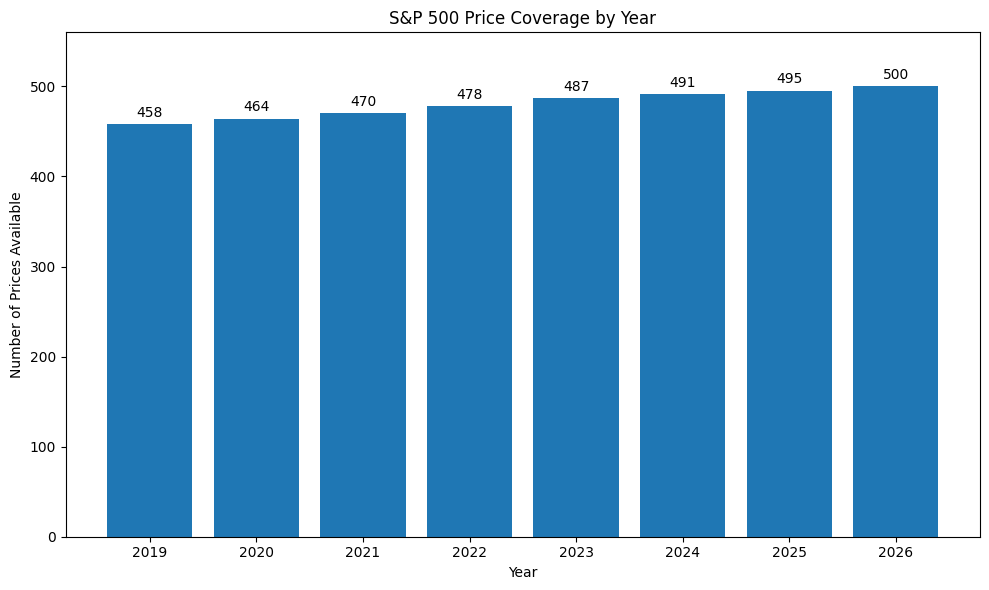

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the analysis-ready dataset
file_path = "/content/sp500_analysis_ready.csv"
analysis_df = pd.read_csv(file_path)

# Identify yearly price columns
price_columns = [
    column
    for column in analysis_df.columns
    if column.startswith("Price Jan ")
]

# Calculate price coverage
price_coverage_df = pd.DataFrame({
    "Year": [
        int(column.replace("Price Jan ", ""))
        for column in price_columns
    ],
    "Prices Available": [
        analysis_df[column].notna().sum()
        for column in price_columns
    ]
})

# Plot price coverage
plt.figure(figsize=(10, 6))

bars = plt.bar(
    price_coverage_df["Year"],
    price_coverage_df["Prices Available"]
)

plt.title("S&P 500 Price Coverage by Year")
plt.xlabel("Year")
plt.ylabel("Number of Prices Available")
plt.xticks(price_coverage_df["Year"])
plt.ylim(
    0,
    price_coverage_df["Prices Available"].max() * 1.12
)

# Add counts above each bar
for bar, count in zip(
    bars,
    price_coverage_df["Prices Available"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

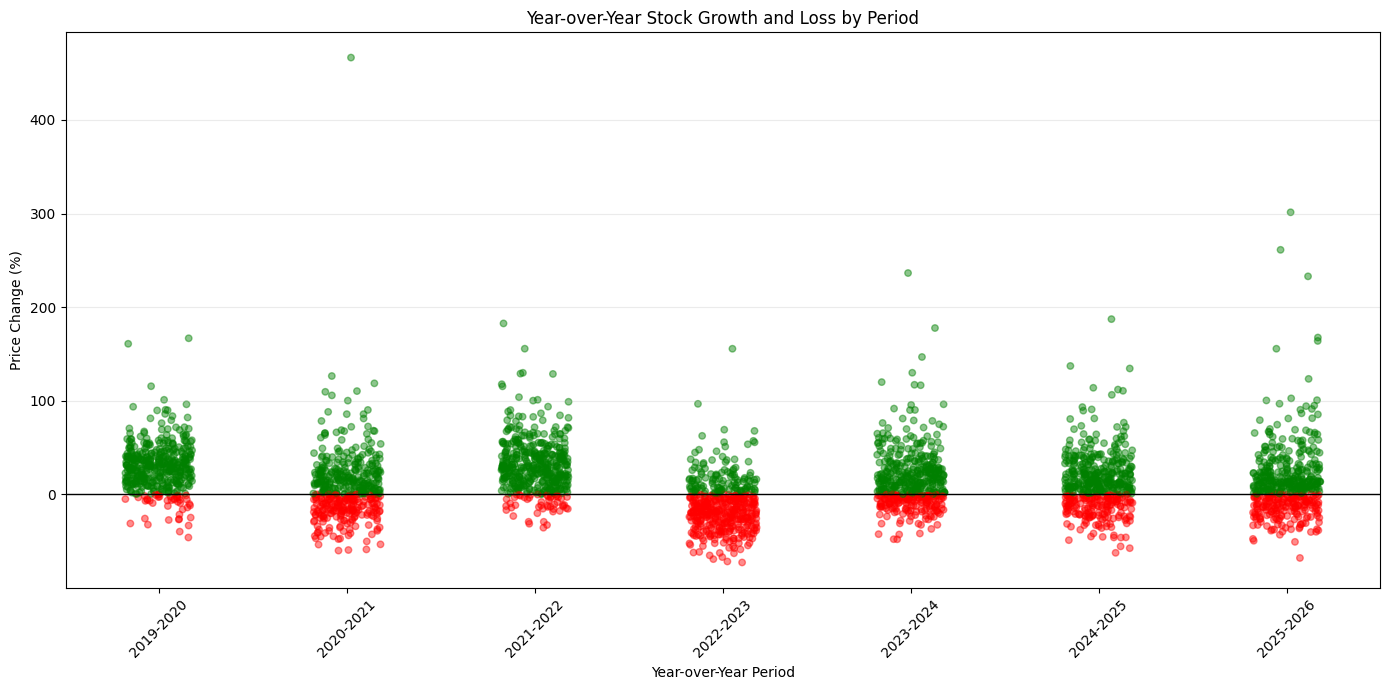

Saved scatter data to: /content/sp500_yoy_scatter_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the analysis-ready dataset
file_path = "/content/sp500_analysis_ready.csv"
analysis_df = pd.read_csv(file_path)

years = list(range(2019, 2027))
scatter_data = []

# Calculate each stock's year-over-year percentage change
for previous_year, current_year in zip(years[:-1], years[1:]):
    previous_column = f"Price Jan {previous_year}"
    current_column = f"Price Jan {current_year}"
    period = f"{previous_year}-{current_year}"

    valid_rows = (
        analysis_df[previous_column].notna()
        & analysis_df[current_column].notna()
        & analysis_df[previous_column].gt(0)
    )

    period_df = analysis_df.loc[
        valid_rows,
        ["Symbol", previous_column, current_column]
    ].copy()

    period_df["Period"] = period

    period_df["YoY Change (%)"] = (
        (
            period_df[current_column]
            - period_df[previous_column]
        )
        / period_df[previous_column]
        * 100
    )

    scatter_data.append(
        period_df[
            [
                "Symbol",
                "Period",
                "YoY Change (%)"
            ]
        ]
    )

# Combine all periods
yoy_scatter_df = pd.concat(
    scatter_data,
    ignore_index=True
)

period_order = [
    f"{previous_year}-{current_year}"
    for previous_year, current_year
    in zip(years[:-1], years[1:])
]

period_positions = {
    period: position
    for position, period in enumerate(period_order)
}

# Create slight horizontal jitter so overlapping points are visible
np.random.seed(42)

yoy_scatter_df["X Position"] = (
    yoy_scatter_df["Period"]
    .map(period_positions)
    .astype(float)
    + np.random.uniform(
        -0.18,
        0.18,
        size=len(yoy_scatter_df)
    )
)

# Use different colors for gains and losses
point_colors = np.where(
    yoy_scatter_df["YoY Change (%)"] >= 0,
    "green",
    "red"
)

# Plot
plt.figure(figsize=(14, 7))

plt.scatter(
    yoy_scatter_df["X Position"],
    yoy_scatter_df["YoY Change (%)"],
    c=point_colors,
    alpha=0.45,
    s=22
)

# Add zero-return reference line
plt.axhline(
    y=0,
    color="black",
    linewidth=1
)

plt.title("Year-over-Year Stock Growth and Loss by Period")
plt.xlabel("Year-over-Year Period")
plt.ylabel("Price Change (%)")

plt.xticks(
    range(len(period_order)),
    period_order,
    rotation=45
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

# Save the calculated year-over-year data
output_path = "/content/sp500_yoy_scatter_data.csv"

yoy_scatter_df[
    ["Symbol", "Period", "YoY Change (%)"]
].to_csv(
    output_path,
    index=False
)

print(f"Saved scatter data to: {output_path}")

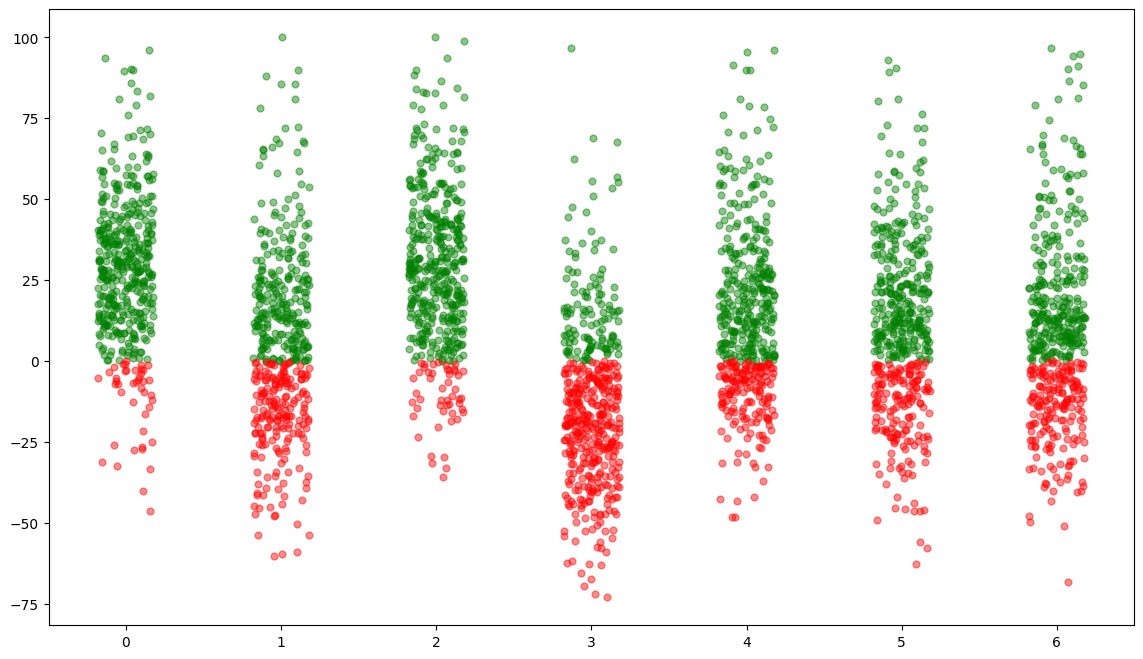

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the analysis-ready dataset
file_path = "/content/sp500_analysis_ready.csv"
analysis_df = pd.read_csv(file_path)

years = list(range(2019, 2027))
scatter_data = []

# Calculate year-over-year percentage changes
for previous_year, current_year in zip(years[:-1], years[1:]):
    previous_column = f"Price Jan {previous_year}"
    current_column = f"Price Jan {current_year}"
    period = f"{previous_year}-{current_year}"

    valid_rows = (
        analysis_df[previous_column].notna()
        & analysis_df[current_column].notna()
        & analysis_df[previous_column].gt(0)
    )

    period_df = analysis_df.loc[
        valid_rows,
        ["Symbol", previous_column, current_column]
    ].copy()

    period_df["Period"] = period

    period_df["YoY Change (%)"] = (
        (
            period_df[current_column]
            - period_df[previous_column]
        )
        / period_df[previous_column]
        * 100
    )

    scatter_data.append(
        period_df[
            ["Symbol", "Period", "YoY Change (%)"]
        ]
    )

# Combine all periods
yoy_scatter_df = pd.concat(
    scatter_data,
    ignore_index=True
)

period_order = [
    f"{previous_year}-{current_year}"
    for previous_year, current_year
    in zip(years[:-1], years[1:])
]

period_positions = {
    period: position
    for position, period in enumerate(period_order)
}

# Add slight horizontal jitter
np.random.seed(42)

yoy_scatter_df["X Position"] = (
    yoy_scatter_df["Period"]
    .map(period_positions)
    .astype(float)
    + np.random.uniform(
        -0.18,
        0.18,
        size=len(yoy_scatter_df)
    )
)

# Separate regular observations and outliers
regular_points = yoy_scatter_df[
    yoy_scatter_df["YoY Change (%)"].between(-100, 100)
].copy()

positive_outliers = yoy_scatter_df[
    yoy_scatter_df["YoY Change (%)"] > 100
].copy()

negative_outliers = yoy_scatter_df[
    yoy_scatter_df["YoY Change (%)"] < -100
].copy()

# Plot
plt.figure(figsize=(14, 8))

# Regular gains
positive_regular = regular_points[
    regular_points["YoY Change (%)"] >= 0
]

plt.scatter(
    positive_regular["X Position"],
    positive_regular["YoY Change (%)"],
    color="green",
    alpha=0.45,
    s=24,
    label="Growth"
)

# Regular losses
negative_regular = regular_points[
    regular_points["YoY Change (%)"] < 0
]

plt.scatter(
    negative_regular["X Position"],
    negative_regular["YoY Change (%)"],
    color="red",
    alpha=0.45,
    s=24,
    label="Loss"
)

# Positive outliers

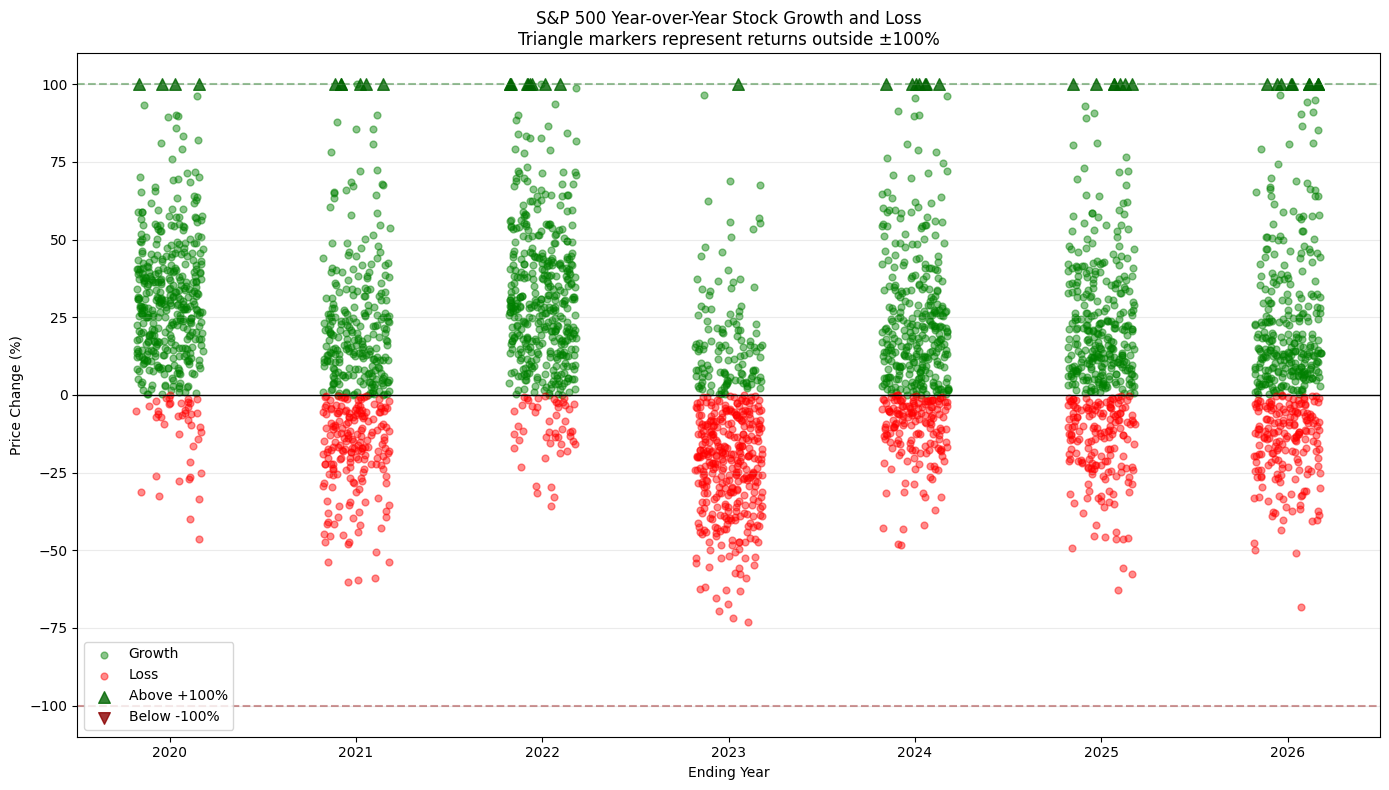

OUTLIER COUNTS BY YEAR:
 Year  Above +100%  Below -100%
 2020            4            0
 2021            6            0
 2022            9            0
 2023            1            0
 2024            7            0
 2025            7            0
 2026           10            0

Saved scatter data to: /content/sp500_yoy_scatter_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the analysis-ready dataset
file_path = "/content/sp500_analysis_ready.csv"
analysis_df = pd.read_csv(file_path)

years = list(range(2019, 2027))
scatter_data = []

# Calculate each stock's year-over-year percentage change
for previous_year, current_year in zip(years[:-1], years[1:]):
    previous_column = f"Price Jan {previous_year}"
    current_column = f"Price Jan {current_year}"

    valid_rows = (
        analysis_df[previous_column].notna()
        & analysis_df[current_column].notna()
        & analysis_df[previous_column].gt(0)
    )

    period_df = analysis_df.loc[
        valid_rows,
        ["Symbol", previous_column, current_column]
    ].copy()

    # Use the ending year for the x-axis
    period_df["Year"] = current_year

    period_df["YoY Change (%)"] = (
        (
            period_df[current_column]
            - period_df[previous_column]
        )
        / period_df[previous_column]
        * 100
    )

    scatter_data.append(
        period_df[
            ["Symbol", "Year", "YoY Change (%)"]
        ]
    )

# Combine all years
yoy_scatter_df = pd.concat(
    scatter_data,
    ignore_index=True
)

# Create x-axis positions
x_axis_years = years[1:]  # 2020 through 2026

year_positions = {
    year: position
    for position, year in enumerate(x_axis_years)
}

# Add slight horizontal jitter so overlapping stocks are visible
np.random.seed(42)

yoy_scatter_df["X Position"] = (
    yoy_scatter_df["Year"]
    .map(year_positions)
    .astype(float)
    + np.random.uniform(
        -0.18,
        0.18,
        size=len(yoy_scatter_df)
    )
)

# Separate regular observations and outliers
regular_points = yoy_scatter_df[
    yoy_scatter_df["YoY Change (%)"].between(-100, 100)
].copy()

positive_outliers = yoy_scatter_df[
    yoy_scatter_df["YoY Change (%)"] > 100
].copy()

negative_outliers = yoy_scatter_df[
    yoy_scatter_df["YoY Change (%)"] < -100
].copy()

# Separate regular gains and losses
positive_regular = regular_points[
    regular_points["YoY Change (%)"] >= 0
]

negative_regular = regular_points[
    regular_points["YoY Change (%)"] < 0
]

# Create the chart
plt.figure(figsize=(14, 8))

# Positive returns
plt.scatter(
    positive_regular["X Position"],
    positive_regular["YoY Change (%)"],
    color="green",
    alpha=0.45,
    s=24,
    label="Growth"
)

# Negative returns
plt.scatter(
    negative_regular["X Position"],
    negative_regular["YoY Change (%)"],
    color="red",
    alpha=0.45,
    s=24,
    label="Loss"
)

# Returns above 100% shown at the top boundary
plt.scatter(
    positive_outliers["X Position"],
    np.full(len(positive_outliers), 100),
    color="darkgreen",
    marker="^",
    s=70,
    alpha=0.8,
    label="Above +100%"
)

# Returns below -100% shown at the bottom boundary
plt.scatter(
    negative_outliers["X Position"],
    np.full(len(negative_outliers), -100),
    color="darkred",
    marker="v",
    s=70,
    alpha=0.8,
    label="Below -100%"
)

# Reference lines
plt.axhline(
    y=0,
    color="black",
    linewidth=1
)

plt.axhline(
    y=100,
    color="darkgreen",
    linestyle="--",
    alpha=0.4
)

plt.axhline(
    y=-100,
    color="darkred",
    linestyle="--",
    alpha=0.4
)

# Titles and axis labels
plt.title(
    "S&P 500 Year-over-Year Stock Growth and Loss\n"
    "Triangle markers represent returns outside ±100%"
)

plt.xlabel("Ending Year")
plt.ylabel("Price Change (%)")

# Display years on the x-axis
plt.xticks(
    range(len(x_axis_years)),
    x_axis_years
)

# Limit the visible y-axis
plt.ylim(-110, 110)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()
plt.tight_layout()
plt.show()

# Count positive outliers by year
outlier_counts_df = pd.DataFrame({
    "Year": x_axis_years,
    "Above +100%": [
        (
            positive_outliers["Year"] == year
        ).sum()
        for year in x_axis_years
    ],
    "Below -100%": [
        (
            negative_outliers["Year"] == year
        ).sum()
        for year in x_axis_years
    ]
})

print("OUTLIER COUNTS BY YEAR:")
print(outlier_counts_df.to_string(index=False))

# Save the scatter data
output_path = "/content/sp500_yoy_scatter_data.csv"

yoy_scatter_df[
    ["Symbol", "Year", "YoY Change (%)"]
].to_csv(
    output_path,
    index=False
)

print(f"\nSaved scatter data to: {output_path}")

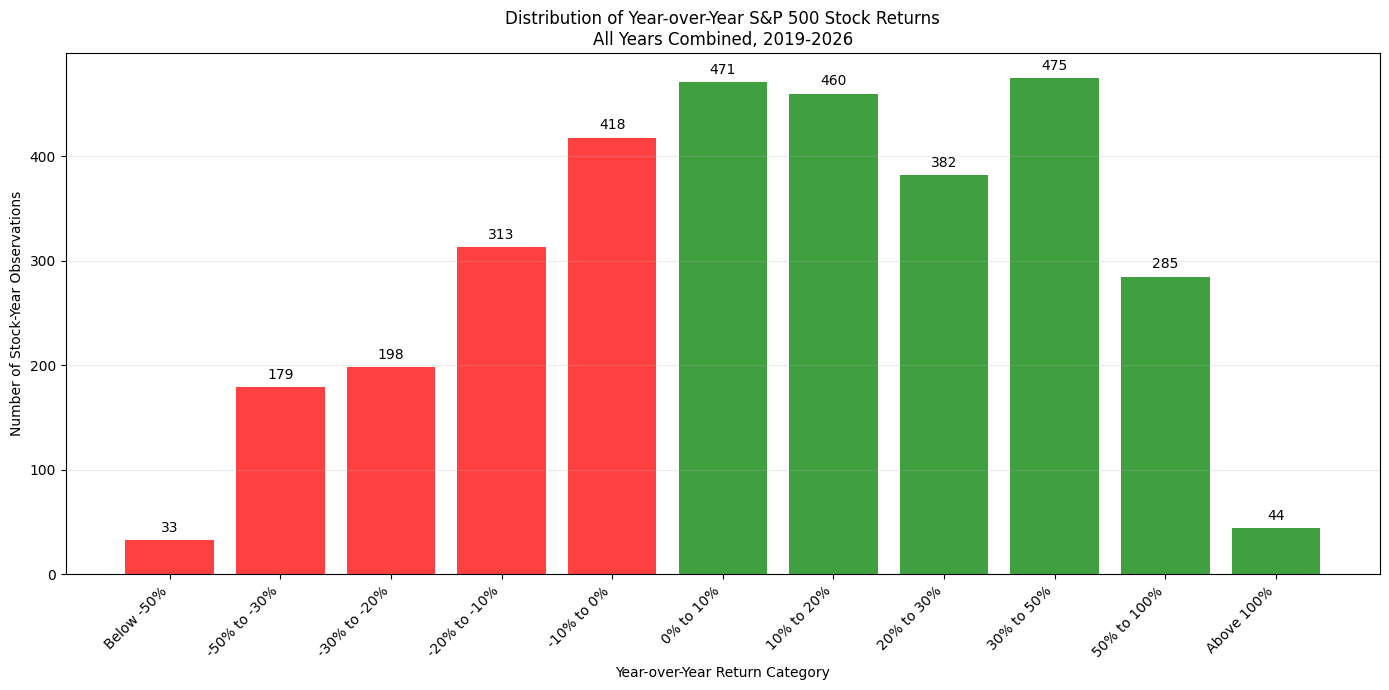

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the analysis-ready dataset
file_path = "/content/sp500_analysis_ready.csv"
analysis_df = pd.read_csv(file_path)

years = list(range(2019, 2027))
all_returns = []

# Calculate year-over-year returns for every valid stock and year
for previous_year, current_year in zip(years[:-1], years[1:]):
    previous_column = f"Price Jan {previous_year}"
    current_column = f"Price Jan {current_year}"

    valid_rows = (
        analysis_df[previous_column].notna()
        & analysis_df[current_column].notna()
        & analysis_df[previous_column].gt(0)
    )

    period_df = analysis_df.loc[
        valid_rows,
        ["Symbol", previous_column, current_column]
    ].copy()

    period_df["Year"] = current_year

    period_df["YoY Change (%)"] = (
        (
            period_df[current_column]
            - period_df[previous_column]
        )
        / period_df[previous_column]
        * 100
    )

    all_returns.append(
        period_df[
            ["Symbol", "Year", "YoY Change (%)"]
        ]
    )

# Combine returns from all years
combined_returns_df = pd.concat(
    all_returns,
    ignore_index=True
)

# Define percentage-change categories
bins = [
    -np.inf,
    -50,
    -30,
    -20,
    -10,
    0,
    10,
    20,
    30,
    50,
    100,
    np.inf
]

category_labels = [
    "Below -50%",
    "-50% to -30%",
    "-30% to -20%",
    "-20% to -10%",
    "-10% to 0%",
    "0% to 10%",
    "10% to 20%",
    "20% to 30%",
    "30% to 50%",
    "50% to 100%",
    "Above 100%"
]

# Assign each return to a category
combined_returns_df["Return Category"] = pd.cut(
    combined_returns_df["YoY Change (%)"],
    bins=bins,
    labels=category_labels,
    right=True,
    include_lowest=True
)

# Count observations in each category
category_counts = (
    combined_returns_df["Return Category"]
    .value_counts()
    .reindex(category_labels, fill_value=0)
)

# Use red for negative categories and green for positive categories
bar_colors = [
    "red",
    "red",
    "red",
    "red",
    "red",
    "green",
    "green",
    "green",
    "green",
    "green",
    "green"
]

# Create the column chart
plt.figure(figsize=(14, 7))

bars = plt.bar(
    category_counts.index,
    category_counts.values,
    color=bar_colors,
    alpha=0.75
)

plt.title(
    "Distribution of Year-over-Year S&P 500 Stock Returns\n"
    "All Years Combined, 2019-2026"
)

plt.xlabel("Year-over-Year Return Category")
plt.ylabel("Number of Stock-Year Observations")

plt.xticks(
    rotation=45,
    ha="right"
)

# Add the count above each column
for bar, count in zip(bars, category_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

# Create and display the count table
return_distribution_df = pd.DataFrame({
    "Return Category": category_labels,
    "Stock-Year Count": category_counts.values
})



In [ ]:
# In a NEW Colab code cell, enter this as the first line:
%%writefile /content/sp500_changes_raw.txt

# Paste the full change-log data directly below this line.
2019-12-23 | LYV   | AMG2019-12-23 | ZBRA  | TRIP2019-12-23 | STE   | MAC2019-12-09 | ODFL  | STI2019-12-05 | WRB   | VIAB2019-11-21 | NOW   | CELG2019-10-03 | LVS   | NKTR2019-09-26 | NVR   | JEF2019-09-23 | CDW   | TSS2019-08-09 | LDOS  | APC2019-08-09 | IEX   | FL2019-07-15 | TMUS  | RHT2019-07-01 | MKTX  | LLL2019-06-11 | AMCR  | BMS2019-06-07 | BMS   | MAT2019-06-03 | DD    | DWDP2019-06-03 | CTVA  | FLR2019-04-02 | DOW   | BHF2019-03-19 | FOXA  | FOXA2019-03-19 | FOX   | FOX2019-02-27 | WAB   | GT2019-02-15 | ATO   | NFX2019-01-18 | TFX   | PCG2019-01-02 | FRC   | SCG2018-12-24 | CE    | ESRX2018-12-03 | LW    | COL2018-12-03 | MXIM  | AET2018-12-03 | FANG  | SRCL2018-11-13 | JKHY  | EQT2018-11-06 | KEYS  | CA2018-10-11 | FTNT  | EVHC2018-10-01 | ROL   | ANDV2018-09-14 | WCG   | XL2018-08-28 | ANET  | GGP2018-07-02 | CPRT  | DPS2018-06-20 | FLT   | TWX2018-06-18 | BR    | RRC2018-06-18 | HFC   | AYI2018-06-07 | TWTR  | MON2018-06-05 | EVRG  | NAVI2018-05-31 | ABMD  | WYN2018-04-04 | MSCI  | CSRA2018-03-19 | TTWO  | SIG2018-03-19 | SIVB  | PDCO2018-03-19 | NKTR  | CHK2018-03-07 | IPGP  | SNI2018-01-03 | HII   | BCR2017-10-13 | NCLH  | LVLT2017-09-18 | CDNS  | SPLS2017-09-01 | DWDP  | DOW2017-09-01 | SBAC  | DD2017-08-29 | Q     | WFM2017-08-08 | BHF   | AN2017-07-26 | DRE   | RIG2017-07-26 | AOS   | BBBY2017-07-26 | PKG   | MUR2017-07-26 | RMD   | MNK2017-07-26 | MGM   | RAI2017-07-07 | BKR   | BHI2017-06-19 | HLT   | YHOO2017-06-19 | ALGN  | TDC2017-06-19 | ANSS  | R2017-06-19 | RE    | MJN2017-06-02 | INFO  | TGNA2017-04-05 | IT    | DNB2017-04-04 | DXC   | SWN2017-03-20 | AMD   | URBN2017-03-20 | RJF   | FTR2017-03-20 | ARE   | FSLR2017-03-16 | SNPS  | HAR2017-03-13 | DISH  | LLTC2017-03-02 | REG   | ENDP2017-03-01 | CBOE  | PBI2017-02-28 | INCY  | SE2017-01-05 | IDXX  | STJ2016-12-02 | MAA   | OI2016-12-02 | EVHC  | LM2016-11-01 | ARNC  | AA2016-09-30 | COTY  | DO2016-09-22 | COO   | HOT2016-09-08 | CHTR  | EMC2016-09-06 | MTD   | TYC2016-07-05 | FTV   | CPGX2016-07-01 | LNT   | GAS2016-07-01 | ALB   | TE2016-06-22 | FBHS  | CVC2016-06-03 | TDG   | BXLT2016-05-31 | AJG   | CCE2016-05-23 | LKQ   | ARG2016-05-18 | DLR   | TWC2016-05-13 | ALK   | SNDK2016-05-03 | AYI   | ADT2016-04-25 | GPN   | GME2016-04-18 | ULTA  | THC2016-04-08 | UA    | —2016-04-04 | FL    | CAM2016-03-30 | HOLX  | POM2016-03-30 | CNC   | ESV2016-03-07 | UDR   | GMCR2016-03-04 | AWK   | CNX2016-02-22 | CXO   | PCL2016-02-01 | CFG   | PCP2016-02-01 | FRT   | BRCM2016-01-19 | EXR   | ACE2016-01-05 | WLTW  | FOSL2015-12-29 | CHD   | ALTR2015-12-15 | —     | CMCSK2015-12-01 | CSRA  | CSC2015-11-19 | ILMN  | SIAL2015-11-18 | SYF   | GNW2015-11-02 | HPE   | HCBK2015-10-07 | VRSK  | JOY2015-09-18 | CMCSK | —2015-09-18 | FOX   | —2015-09-18 | NWS   | —2015-09-02 | UAL   | HSP2015-08-28 | ATVI  | PLL2015-07-29 | SIG   | DTV2015-07-20 | PYPL  | NE2015-07-08 | AAP   | FDO2015-07-06 | KHC   | KRFT2015-07-02 | CPGX  | ATI2015-07-01 | JBHT  | TEG2015-07-01 | BXLT  | QEP2015-06-11 | QRVO  | LO2015-04-07 | O     | WIN2015-03-23 | AAL   | AGN2015-03-23 | EQIX  | DNR2015-03-23 | SLG   | NBR2015-03-23 | HBI   | AVP2015-03-18 | HSIC  | CFN2015-03-12 | SWKS  | PETM2015-01-27 | HCA   | SWY2015-01-27 | ENDP  | COV2014-12-05 | RCL   | BMS2014-11-05 | LVLT  | JBL2014-09-20 | URI   | BTU2014-09-20 | UHS   | GHC2014-08-18 | MNK   | RDC2014-08-06 | DISCK | —2014-07-02 | MLM   | X2014-07-01 | AMG   | FRX2014-06-20 | XEC   | IGT2014-05-08 | AVGO  | LSI2014-05-01 | UA    | BEAM2014-05-01 | NAVI  | SLM2014-04-03 | GOOGL | —2014-04-02 | ESS   | CLF2014-03-21 | GMCR  | WPX2014-01-24 | TSCO  | LIFE2013-12-23 | ADS   | ANF2013-12-23 | MHK   | JDSU2013-12-23 | FB    | TER2013-12-10 | GGP   | MOLX2013-12-02 | ALLE  | JCP2013-11-13 | KORS  | NYX2013-10-29 | RIG   | DELL2013-09-20 | VRTX  | AMD2013-09-20 | AME   | SAI2013-09-10 | DAL   | BMC2013-07-08 | NLSN  | S2013-07-01 | NWSA  | APOL2013-06-21 | ZTS   | FHN2013-06-06 | GM    | HNZ2013-05-23 | KSU   | DF2013-05-08 | MAC   | CVH2013-04-30 | REGN  | PCS2013-02-15 | PVH   | BIG2013-01-02 | ABBV  | FII2012-12-21 | DLPH  | TIE2012-12-11 | GRMN  | RRD2012-12-03 | DG    | CBE2012-10-10 | PETM  | SUN2012-10-02 | KRFT  | ANR2012-10-02 | MDLZ  | KFT2012-10-01 | ADT   | LXK2012-10-01 | PNR   | DV2012-09-05 | LYB   | SHLD2012-07-31 | ESV   | GR2012-07-02 | STX   | PGN2012-06-29 | MNST  | SLE2012-06-05 | LRCX  | NVLS2012-05-21 | ALXN  | MMI2012-05-17 | KMI   | EP2012-04-23 | PSX   | SVU2012-04-03 | FOSL  | MHS2012-03-13 | CCI   | CEG2011-12-31 | WPX   | CPWR2011-12-20 | TRIP  | TLAB2011-12-16 | BWA   | AKS2011-12-16 | PRGO  | MWW2011-12-16 | DLTR  | WFR2011-12-12 | GAS   | GAS2011-11-18 | CBE   | JNS2011-10-31 | XYL   | ITT2011-10-14 | TEL   | CEPH2011-09-23 | MOS   | NSM2011-07-05 | ACN   | MI2011-06-30 | MPC   | RSH2011-06-01 | ANR   | MEE2011-04-27 | CMG   | NOVL2011-04-01 | BLK   | GENZ2011-03-31 | EW    | Q2011-02-28 | COV   | MFE2011-02-25 | JOYG  | AYE2011-01-03 | MMI   | MDP2010-12-17 | CVC   | KG2010-12-17 | FFIV  | EK2010-12-17 | NFLX  | ODP2010-12-17 | NFX   | NYT2010-11-17 | IR    | PTV2010-08-26 | TYC   | SII2010-07-14 | CB    | MIL2010-06-30 | QEP   | STR2010-06-28 | KMX   | XTO2010-04-29 | CERN  | BJS2010-02-26 | HP    | RX2009-12-18 | V     | CIEN2009-12-18 | MJN   | DYN2009-12-18 | CLF   | KBH2009-12-18 | SAI   | CVG2009-12-18 | ROST  | MBI2009-11-03 | PCLN  | SGP2009-09-28 | ARG   | CBE2009-08-19 | FMC   | CTX2009-06-29 | PCS   | —2009-06-25 | —     | TEL2009-06-05 | FTI   | COV2009-03-03 | HRL   | ACAS2009-03-03 | VTR   | JNY2008-12-31 | OI    | WB2008-09-16 | HRS   | LEH2008-09-12 | CRM   | FRE2008-09-12 | FAST  | FNM2008-07-01 | AKS   | CFC2008-06-23 | COG   | BC2008-06-23 | MEE   | OMX2008-06-10 | LO    | ABK2007-12-20 | RRC   | TRB2007-12-13 | GME   | DJ2007-10-26 | JEC   | AV2007-10-02 | EXPE  | SLR2007-10-01 | TDC   | NCR2007-09-27 | TSO   | MXIM2007-09-26 | ICE   | FDC2007-08-24 | LUK   | KSE2007-07-02 | DFS   | ADCT2007-03-30 | KFT   | TSG2007-01-10 | AVB   | SBL2006-06-02 | JNPR  | ABS2005-11-18 | AMZN  | T2005-07-01 | STZ   | GLK2003-09-25 | ESRX  | QTRN

Overwriting /content/sp500_changes_raw.txt


In [ ]:
from pathlib import Path

file_path = Path("/content/sp500_changes_raw.txt")

print(f"File exists: {file_path.exists()}")
print(f"File size: {file_path.stat().st_size:,} bytes")

with open(file_path, "r", encoding="utf-8") as file:
    lines = [
        line.strip()
        for line in file
        if line.strip()
        and not line.lstrip().startswith("#")
    ]

print(f"Nonblank data lines: {len(lines):,}")
print("\nFirst 5 lines:")
print("\n".join(lines[:5]))

print("\nLast 5 lines:")
print("\n".join(lines[-5:]))

File exists: True
File size: 6,591 bytes
Nonblank data lines: 1

First 5 lines:
2019-12-23 | LYV   | AMG2019-12-23 | ZBRA  | TRIP2019-12-23 | STE   | MAC2019-12-09 | ODFL  | STI2019-12-05 | WRB   | VIAB2019-11-21 | NOW   | CELG2019-10-03 | LVS   | NKTR2019-09-26 | NVR   | JEF2019-09-23 | CDW   | TSS2019-08-09 | LDOS  | APC2019-08-09 | IEX   | FL2019-07-15 | TMUS  | RHT2019-07-01 | MKTX  | LLL2019-06-11 | AMCR  | BMS2019-06-07 | BMS   | MAT2019-06-03 | DD    | DWDP2019-06-03 | CTVA  | FLR2019-04-02 | DOW   | BHF2019-03-19 | FOXA  | FOXA2019-03-19 | FOX   | FOX2019-02-27 | WAB   | GT2019-02-15 | ATO   | NFX2019-01-18 | TFX   | PCG2019-01-02 | FRC   | SCG2018-12-24 | CE    | ESRX2018-12-03 | LW    | COL2018-12-03 | MXIM  | AET2018-12-03 | FANG  | SRCL2018-11-13 | JKHY  | EQT2018-11-06 | KEYS  | CA2018-10-11 | FTNT  | EVHC2018-10-01 | ROL   | ANDV2018-09-14 | WCG   | XL2018-08-28 | ANET  | GGP2018-07-02 | CPRT  | DPS2018-06-20 | FLT   | TWX2018-06-18 | BR    | RRC2018-06-18 | HFC   | AYI20

In [ ]:
import re
from pathlib import Path

input_path = Path("/content/sp500_changes_raw.txt")
output_path = Path("/content/sp500_changes_raw_fixed.txt")

# Read the concatenated text
raw_text = input_path.read_text(encoding="utf-8").strip()

# Insert a line break before every date except the first date
fixed_text = re.sub(
    r"(?<!^)(?=\d{4}-\d{2}-\d{2}\s*\|)",
    "\n",
    raw_text
)

# Clean spaces around each record
fixed_lines = [
    line.strip()
    for line in fixed_text.splitlines()
    if line.strip()
]

# Save the corrected file
output_path.write_text(
    "\n".join(fixed_lines) + "\n",
    encoding="utf-8"
)

print(f"Corrected file: {output_path}")
print(f"Records recovered: {len(fixed_lines):,}")

print("\nFIRST 5 RECORDS:")
for line in fixed_lines[:5]:
    print(line)

print("\nLAST 5 RECORDS:")
for line in fixed_lines[-5:]:
    print(line)

Corrected file: /content/sp500_changes_raw_fixed.txt
Records recovered: 254

FIRST 5 RECORDS:
# Paste the full change-log data directly below this line.
2019-12-23 | LYV   | AMG
2019-12-23 | ZBRA  | TRIP
2019-12-23 | STE   | MAC
2019-12-09 | ODFL  | STI

LAST 5 RECORDS:
2007-01-10 | AVB   | SBL
2006-06-02 | JNPR  | ABS
2005-11-18 | AMZN  | T
2005-07-01 | STZ   | GLK
2003-09-25 | ESRX  | QTRN


In [ ]:
import pandas as pd
from pathlib import Path

input_path = Path("/content/sp500_changes_raw_fixed.txt")
output_path = Path("/content/sp500_changes_2003_2019.csv")

records = []
invalid_lines = []

with open(input_path, "r", encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        line = line.strip()

        if not line:
            continue

        parts = [
            part.strip()
            for part in line.split("|")
        ]

        if len(parts) != 3:
            invalid_lines.append({
                "line_number": line_number,
                "content": line
            })
            continue

        date_text, added, removed = parts

        if added in {"—", "-", ""}:
            added = pd.NA

        if removed in {"—", "-", ""}:
            removed = pd.NA

        records.append({
            "Date": date_text,
            "Added": added,
            "Removed": removed
        })

changes_df = pd.DataFrame(records)

changes_df["Date"] = pd.to_datetime(
    changes_df["Date"],
    format="%Y-%m-%d",
    errors="coerce"
)

for column in ["Added", "Removed"]:
    changes_df[column] = (
        changes_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )

changes_df = (
    changes_df
    .dropna(subset=["Date"])
    .drop_duplicates()
    .sort_values("Date")
    .reset_index(drop=True)
)

changes_df.to_csv(
    output_path,
    index=False,
    date_format="%Y-%m-%d"
)

print("RESULTS:")
print(f"Valid change events: {len(changes_df):,}")
print(f"Invalid lines: {len(invalid_lines):,}")
print(f"First date: {changes_df['Date'].min().date()}")
print(f"Last date: {changes_df['Date'].max().date()}")

print("\nFIRST 5 EVENTS:")
print(changes_df.head().to_string(index=False))

print("\nLAST 5 EVENTS:")
print(changes_df.tail().to_string(index=False))

print(f"\nSaved to: {output_path}")

RESULTS:
Valid change events: 253
Invalid lines: 1
First date: 2003-09-25
Last date: 2019-12-23

FIRST 5 EVENTS:
      Date Added Removed
2003-09-25  ESRX    QTRN
2005-07-01   STZ     GLK
2005-11-18  AMZN       T
2006-06-02  JNPR     ABS
2007-01-10   AVB     SBL

LAST 5 EVENTS:
      Date Added Removed
2019-12-05   WRB    VIAB
2019-12-09  ODFL     STI
2019-12-23   STE     MAC
2019-12-23  ZBRA    TRIP
2019-12-23   LYV     AMG

Saved to: /content/sp500_changes_2003_2019.csv


In [ ]:
import pandas as pd
from pathlib import Path

# ============================================================
# 1. FILE PATHS
# ============================================================

current_data_path = Path(
    "/content/"
    "sp500_googlefinance_final - S&P 500 All tickers and data.csv"
)

historical_changes_path = Path(
    "/content/sp500_changes_2003_2019.csv"
)

if not current_data_path.exists():
    raise FileNotFoundError(
        f"Current data file not found: {current_data_path}"
    )

if not historical_changes_path.exists():
    raise FileNotFoundError(
        f"Historical change file not found: {historical_changes_path}"
    )


# ============================================================
# 2. LOAD CURRENT TABLE AND HISTORICAL CHANGES
# ============================================================

current_df = pd.read_csv(
    current_data_path,
    keep_default_na=False
)

changes_df = pd.read_csv(
    historical_changes_path
)

current_df["Symbol"] = (
    current_df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

changes_df["Date"] = pd.to_datetime(
    changes_df["Date"],
    errors="coerce"
)

for column in ["Added", "Removed"]:
    changes_df[column] = (
        changes_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
        .replace({
            "": pd.NA,
            "NAN": pd.NA,
            "—": pd.NA,
            "-": pd.NA
        })
    )

changes_df = (
    changes_df
    .dropna(subset=["Date"])
    .sort_values("Date")
    .reset_index(drop=True)
)


# ============================================================
# 3. DEFINE YEARS
# ============================================================

start_year = 2003
end_year = 2026

years = list(range(start_year, end_year + 1))

existing_years = list(range(2019, 2027))

all_price_columns = [
    f"Price Jan {year}"
    for year in years
]


# ============================================================
# 4. DERIVE JANUARY 2019 MEMBERSHIP
# ============================================================
# A ticker is treated as a January 2019 member when its
# Price Jan 2019 cell is not N/A.
#
# "Not Found" still means the ticker was a member.

jan_2019_members = set(
    current_df.loc[
        current_df["Price Jan 2019"]
        .astype(str)
        .str.strip()
        .str.upper()
        .ne("N/A"),
        "Symbol"
    ]
)

print(
    f"January 2019 anchor membership: "
    f"{len(jan_2019_members):,}"
)


# ============================================================
# 5. RECONSTRUCT JANUARY 2003-2018 MEMBERSHIP
# ============================================================
# Start with January 2019.
#
# To reconstruct January 2018, undo every event that occurred
# during 2018:
#   - Remove the ticker that was added
#   - Restore the ticker that was removed
#
# Repeat backward one year at a time.

membership_by_year = {
    2019: jan_2019_members.copy()
}

working_members = jan_2019_members.copy()

for year in range(2018, 2002, -1):

    # Events that occurred after January 1 of the target year
    events_to_undo = changes_df[
        (changes_df["Date"] >= pd.Timestamp(year, 1, 1))
        & (changes_df["Date"] < pd.Timestamp(year + 1, 1, 1))
    ].sort_values(
        "Date",
        ascending=False
    )

    for _, event in events_to_undo.iterrows():
        added_ticker = event["Added"]
        removed_ticker = event["Removed"]

        # Undo the addition
        if pd.notna(added_ticker):
            working_members.discard(added_ticker)

        # Undo the removal
        if pd.notna(removed_ticker):
            working_members.add(removed_ticker)

    membership_by_year[year] = working_members.copy()


# ============================================================
# 6. DERIVE 2020-2026 MEMBERSHIP FROM EXISTING N/A CELLS
# ============================================================

for year in range(2020, 2027):
    price_column = f"Price Jan {year}"

    membership_by_year[year] = set(
        current_df.loc[
            current_df[price_column]
            .astype(str)
            .str.strip()
            .str.upper()
            .ne("N/A"),
            "Symbol"
        ]
    )


# ============================================================
# 7. COLLECT ALL CURRENT AND HISTORICAL TICKERS
# ============================================================

historical_tickers = set(
    pd.concat(
        [
            changes_df["Added"],
            changes_df["Removed"]
        ],
        ignore_index=True
    )
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
)

current_tickers = set(
    current_df["Symbol"].dropna()
)

membership_tickers = set()

for members in membership_by_year.values():
    membership_tickers.update(members)

all_tickers = sorted(
    current_tickers
    | historical_tickers
    | membership_tickers
)

print(
    f"Total current and historical tickers: "
    f"{len(all_tickers):,}"
)


# ============================================================
# 8. CREATE FULL MEMBERSHIP TABLE
# ============================================================

membership_df = pd.DataFrame({
    "Symbol": all_tickers
})

for year in years:
    membership_df[f"In SP500 Jan {year}"] = (
        membership_df["Symbol"]
        .isin(membership_by_year[year])
        .map({
            True: "Yes",
            False: "No"
        })
    )


# ============================================================
# 9. CREATE GOOGLE FINANCE-READY PRICE TABLE
# ============================================================

price_df = pd.DataFrame({
    "Symbol": all_tickers
})

# Add all price columns as object columns
for year in years:
    price_df[f"Price Jan {year}"] = pd.Series(
        [""] * len(price_df),
        dtype="object"
    )

# Preserve existing 2019-2026 values
existing_price_columns = [
    f"Price Jan {year}"
    for year in existing_years
]

existing_prices_df = current_df[
    ["Symbol"] + existing_price_columns
].copy()

price_df = price_df.drop(
    columns=existing_price_columns
).merge(
    existing_prices_df,
    on="Symbol",
    how="left"
)

# Restore the correct chronological column order
for year in range(2003, 2019):
    column = f"Price Jan {year}"

    if column not in price_df.columns:
        price_df[column] = ""

price_df = price_df[
    ["Symbol"] + all_price_columns
]

for column in all_price_columns:
    price_df[column] = price_df[column].astype("object")


# ============================================================
# 10. GOOGLE FINANCE FORMULA FUNCTION
# ============================================================

def create_googlefinance_formula(sheet_row, year):
    return (
        f'=IFERROR(INDEX(GOOGLEFINANCE('
        f'$A{sheet_row},"close",'
        f'DATE({year},1,1),'
        f'DATE({year},1,10),'
        f'"DAILY"),2,2),"Not Found")'
    )


# ============================================================
# 11. INSERT FORMULAS AND N/A PLACEHOLDERS
# ============================================================

for row_index in price_df.index:
    symbol = price_df.at[row_index, "Symbol"]

    # Google Sheets row number includes the header
    sheet_row = row_index + 2

    for year in years:
        price_column = f"Price Jan {year}"
        was_member = symbol in membership_by_year[year]

        if not was_member:
            price_df.at[
                row_index,
                price_column
            ] = "N/A"

            continue

        existing_value = price_df.at[
            row_index,
            price_column
        ]

        value_text = (
            str(existing_value).strip()
            if pd.notna(existing_value)
            else ""
        )

        missing_value = (
            value_text == ""
            or value_text.upper() == "NAN"
            or value_text.upper() == "N/A"
        )

        if missing_value:
            price_df.at[
                row_index,
                price_column
            ] = create_googlefinance_formula(
                sheet_row,
                year
            )


# ============================================================
# 12. CREATE COMBINED MEMBERSHIP AND PRICE TABLE
# ============================================================

combined_df = pd.DataFrame({
    "Symbol": all_tickers
})

for year in years:
    membership_column = f"In SP500 Jan {year}"
    price_column = f"Price Jan {year}"

    combined_df[membership_column] = (
        membership_df[membership_column]
    )

    combined_df[price_column] = (
        price_df[price_column]
    )


# ============================================================
# 13. VALIDATION TABLE
# ============================================================

validation_rows = []

for year in years:
    members = membership_by_year[year]

    validation_rows.append({
        "Year": year,
        "January Members": len(members),
        "Member Formulas": (
            price_df[f"Price Jan {year}"]
            .astype(str)
            .str.startswith("=")
            .sum()
        ),
        "Numeric Prices": pd.to_numeric(
            price_df[f"Price Jan {year}"],
            errors="coerce"
        ).notna().sum(),
        "N/A Nonmember Cells": (
            price_df[f"Price Jan {year}"]
            .astype(str)
            .str.strip()
            .str.upper()
            .eq("N/A")
            .sum()
        )
    })

validation_df = pd.DataFrame(
    validation_rows
)


# ============================================================
# 14. SAVE OUTPUT FILES
# ============================================================

membership_output = Path(
    "/content/sp500_membership_2003_2026.csv"
)

price_output = Path(
    "/content/sp500_googlefinance_2003_2026.csv"
)

combined_output = Path(
    "/content/sp500_membership_and_prices_2003_2026.csv"
)

validation_output = Path(
    "/content/sp500_membership_validation_2003_2026.csv"
)

membership_df.to_csv(
    membership_output,
    index=False
)

price_df.to_csv(
    price_output,
    index=False
)

combined_df.to_csv(
    combined_output,
    index=False
)

validation_df.to_csv(
    validation_output,
    index=False
)


# ============================================================
# 15. DISPLAY RESULTS
# ============================================================

print("\nJANUARY MEMBERSHIP VALIDATION:")
print(validation_df.to_string(index=False))

print("\nTABLE RESULTS:")
print(f"Years covered: {start_year}-{end_year}")
print(f"Total ticker rows: {len(price_df):,}")
print(f"Membership columns: {len(years):,}")
print(f"Price columns: {len(years):,}")

print("\nSAMPLE MEMBERSHIP TABLE:")
print(
    membership_df.head(10).to_string(
        index=False
    )
)

print("\nFILES SAVED:")
print(membership_output)
print(price_output)
print(combined_output)
print(validation_output)

January 2019 anchor membership: 507
Total current and historical tickers: 860

JANUARY MEMBERSHIP VALIDATION:
 Year  January Members  Member Formulas  Numeric Prices  N/A Nonmember Cells
 2003              514              514               0                  346
 2004              514              514               0                  346
 2005              514              514               0                  346
 2006              515              515               0                  345
 2007              515              515               0                  345
 2008              512              512               0                  348
 2009              510              510               0                  350
 2010              509              509               0                  351
 2011              508              508               0                  352
 2012              507              507               0                  353
 2013              506              506    

In [ ]:
import pandas as pd
from pathlib import Path

# Colab path provided
file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(
        f"File not found: {file_path}\n"
        "Confirm the file is uploaded to the current Colab session."
    )

# Preserve text placeholders exactly
df = pd.read_csv(
    file_path,
    keep_default_na=False
)

# Clean ticker symbols
df["Symbol"] = (
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

price_columns = [
    column
    for column in df.columns
    if column.startswith("Price Jan ")
]

summary_rows = []

for column in price_columns:
    year = int(column.replace("Price Jan ", ""))

    cleaned = (
        df[column]
        .astype(str)
        .str.strip()
    )

    numeric_values = pd.to_numeric(
        cleaned,
        errors="coerce"
    )

    not_applicable_count = (
        cleaned.str.upper().eq("N/A").sum()
    )

    not_found_count = (
        cleaned.str.upper().eq("NOT FOUND").sum()
    )

    blank_count = (
        cleaned.eq("").sum()
        + cleaned.str.upper().eq("NAN").sum()
    )

    numeric_count = numeric_values.notna().sum()

    eligible_count = (
        numeric_count
        + not_found_count
        + blank_count
    )

    summary_rows.append({
        "Year": year,
        "Total Ticker Rows": len(df),
        "Prices Found": numeric_count,
        "Not Found": not_found_count,
        "Blank": blank_count,
        "N/A Nonmember": not_applicable_count,
        "Eligible Member Rows": eligible_count,
        "Price Coverage (%)": (
            round(
                numeric_count / eligible_count * 100,
                2
            )
            if eligible_count > 0
            else 0
        )
    })

# Annual summary table
yearly_summary_df = pd.DataFrame(summary_rows)

# Overall cell counts
all_price_cells = (
    df[price_columns]
    .astype(str)
    .apply(lambda column: column.str.strip())
)

numeric_cells = (
    all_price_cells
    .apply(pd.to_numeric, errors="coerce")
    .notna()
    .sum()
    .sum()
)

not_found_cells = (
    all_price_cells
    .apply(
        lambda column:
        column.str.upper().eq("NOT FOUND")
    )
    .sum()
    .sum()
)

not_applicable_cells = (
    all_price_cells
    .apply(
        lambda column:
        column.str.upper().eq("N/A")
    )
    .sum()
    .sum()
)

blank_cells = (
    all_price_cells
    .apply(
        lambda column:
        column.eq("")
        | column.str.upper().eq("NAN")
    )
    .sum()
    .sum()
)

# Tickers with at least one numeric price
numeric_price_table = df[price_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

ticker_summary_df = pd.DataFrame({
    "Symbol": df["Symbol"],
    "Years With Price": (
        numeric_price_table.notna().sum(axis=1)
    ),
    "Years Not Found": (
        all_price_cells
        .apply(
            lambda column:
            column.str.upper().eq("NOT FOUND")
        )
        .sum(axis=1)
    ),
    "Years N/A": (
        all_price_cells
        .apply(
            lambda column:
            column.str.upper().eq("N/A")
        )
        .sum(axis=1)
    )
})

# Save summaries
yearly_output = (
    "/content/sp500_price_status_summary_by_year.csv"
)

ticker_output = (
    "/content/sp500_price_status_summary_by_ticker.csv"
)

yearly_summary_df.to_csv(
    yearly_output,
    index=False
)

ticker_summary_df.to_csv(
    ticker_output,
    index=False
)

# Display results
print("DATASET SUMMARY:")
print(f"Ticker rows: {len(df):,}")
print(f"Years: {len(price_columns):,}")
print(
    f"Year range: "
    f"{yearly_summary_df['Year'].min()}-"
    f"{yearly_summary_df['Year'].max()}"
)
print(f"Total price cells: {len(df) * len(price_columns):,}")
print(f"Numeric prices found: {numeric_cells:,}")
print(f"Not Found cells: {not_found_cells:,}")
print(f"N/A nonmember cells: {not_applicable_cells:,}")
print(f"Blank cells: {blank_cells:,}")

print("\nSUMMARY BY YEAR:")
print(yearly_summary_df.to_string(index=False))

print("\nTICKERS WITH THE MOST PRICES:")
print(
    ticker_summary_df
    .sort_values(
        ["Years With Price", "Symbol"],
        ascending=[False, True]
    )
    .head(20)
    .to_string(index=False)
)

print("\nTICKERS WITH THE MOST NOT FOUND VALUES:")
print(
    ticker_summary_df
    .sort_values(
        ["Years Not Found", "Symbol"],
        ascending=[False, True]
    )
    .head(20)
    .to_string(index=False)
)

print("\nFILES SAVED:")
print(yearly_output)
print(ticker_output)

DATASET SUMMARY:
Ticker rows: 860
Years: 24
Year range: 2003-2026
Total price cells: 20,640
Numeric prices found: 10,058
Not Found cells: 2,138
N/A nonmember cells: 8,444
Blank cells: 0

SUMMARY BY YEAR:
 Year  Total Ticker Rows  Prices Found  Not Found  Blank  N/A Nonmember  Eligible Member Rows  Price Coverage (%)
 2003                860           340        174      0            346                   514               66.15
 2004                860           347        167      0            346                   514               67.51
 2005                860           353        161      0            346                   514               68.68
 2006                860           363        152      0            345                   515               70.49
 2007                860           370        145      0            345                   515               71.84
 2008                860           374        138      0            348                   512               73.0

In [ ]:
import pandas as pd
from pathlib import Path

# ============================================================
# 1. LOAD DATA
# ============================================================

file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(
    file_path,
    keep_default_na=False
)

df["Symbol"] = (
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2003, 2027))

# Convert numeric prices while treating text values as missing
for year in years:
    column = f"Price Jan {year}"

    df[column] = pd.to_numeric(
        df[column].replace({
            "N/A": pd.NA,
            "Not Found": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )


# ============================================================
# 2. BACKTEST FUNCTION
# ============================================================

def run_top_stock_strategy(
    data,
    number_of_stocks,
    starting_balance=1000.00
):
    current_balance = starting_balance
    portfolio_results = []
    stock_details = []

    # Example:
    # 2003-2004 performance selects stocks bought in Jan 2004.
    # Those stocks are sold in Jan 2005.
    for selection_year in range(2004, 2026):
        prior_column = f"Price Jan {selection_year - 1}"
        purchase_column = f"Price Jan {selection_year}"
        sale_column = f"Price Jan {selection_year + 1}"

        # Require all three prices
        valid_stocks = data[
            data[prior_column].notna()
            & data[purchase_column].notna()
            & data[sale_column].notna()
            & data[prior_column].gt(0)
            & data[purchase_column].gt(0)
        ].copy()

        if valid_stocks.empty:
            portfolio_results.append({
                "Selection Period":
                    f"{selection_year - 1}-{selection_year}",
                "Investment Period":
                    f"{selection_year}-{selection_year + 1}",
                "Number of Stocks": 0,
                "Selected Stocks": "None",
                "Starting Balance": round(current_balance, 2),
                "Portfolio Return (%)": 0.00,
                "Ending Balance": round(current_balance, 2)
            })

            continue

        # Prior-year performance used to rank stocks
        valid_stocks["Prior Year Return (%)"] = (
            (
                valid_stocks[purchase_column]
                - valid_stocks[prior_column]
            )
            / valid_stocks[prior_column]
            * 100
        )

        # Select the top-performing stock or top five stocks
        selected_stocks = (
            valid_stocks
            .sort_values(
                "Prior Year Return (%)",
                ascending=False
            )
            .head(number_of_stocks)
            .copy()
        )

        period_starting_balance = current_balance

        investment_per_stock = (
            period_starting_balance
            / len(selected_stocks)
        )

        period_ending_balance = 0.0

        for _, stock in selected_stocks.iterrows():
            symbol = stock["Symbol"]
            purchase_price = stock[purchase_column]
            sale_price = stock[sale_column]

            shares_purchased = (
                investment_per_stock
                / purchase_price
            )

            ending_value = (
                shares_purchased
                * sale_price
            )

            investment_return = (
                (sale_price - purchase_price)
                / purchase_price
                * 100
            )

            period_ending_balance += ending_value

            stock_details.append({
                "Selection Period":
                    f"{selection_year - 1}-{selection_year}",
                "Investment Period":
                    f"{selection_year}-{selection_year + 1}",
                "Symbol": symbol,
                "Prior Year Return (%)": round(
                    stock["Prior Year Return (%)"],
                    2
                ),
                "Purchase Price": round(purchase_price, 2),
                "Sale Price": round(sale_price, 2),
                "Amount Invested": round(
                    investment_per_stock,
                    2
                ),
                "Shares Purchased": round(
                    shares_purchased,
                    6
                ),
                "Investment Return (%)": round(
                    investment_return,
                    2
                ),
                "Ending Value": round(
                    ending_value,
                    2
                )
            })

        portfolio_return = (
            (
                period_ending_balance
                / period_starting_balance
            )
            - 1
        ) * 100

        portfolio_results.append({
            "Selection Period":
                f"{selection_year - 1}-{selection_year}",
            "Investment Period":
                f"{selection_year}-{selection_year + 1}",
            "Number of Stocks": len(selected_stocks),
            "Selected Stocks": ", ".join(
                selected_stocks["Symbol"].astype(str)
            ),
            "Starting Balance": round(
                period_starting_balance,
                2
            ),
            "Investment Per Stock": round(
                investment_per_stock,
                2
            ),
            "Portfolio Return (%)": round(
                portfolio_return,
                2
            ),
            "Ending Balance": round(
                period_ending_balance,
                2
            )
        })

        current_balance = period_ending_balance

    return (
        pd.DataFrame(portfolio_results),
        pd.DataFrame(stock_details),
        current_balance
    )


# ============================================================
# 3. RUN TOP-ONE STRATEGY
# ============================================================

top_1_results_df, top_1_details_df, top_1_final = (
    run_top_stock_strategy(
        data=df,
        number_of_stocks=1,
        starting_balance=1000.00
    )
)


# ============================================================
# 4. RUN TOP-FIVE STRATEGY
# ============================================================

top_5_results_df, top_5_details_df, top_5_final = (
    run_top_stock_strategy(
        data=df,
        number_of_stocks=5,
        starting_balance=1000.00
    )
)


# ============================================================
# 5. CREATE COMPARISON TABLE
# ============================================================

comparison_df = top_1_results_df[
    [
        "Investment Period",
        "Selected Stocks",
        "Portfolio Return (%)",
        "Ending Balance"
    ]
].rename(columns={
    "Selected Stocks": "Top 1 Selection",
    "Portfolio Return (%)": "Top 1 Return (%)",
    "Ending Balance": "Top 1 Ending Balance"
})

top_5_comparison = top_5_results_df[
    [
        "Investment Period",
        "Selected Stocks",
        "Portfolio Return (%)",
        "Ending Balance"
    ]
].rename(columns={
    "Selected Stocks": "Top 5 Selections",
    "Portfolio Return (%)": "Top 5 Return (%)",
    "Ending Balance": "Top 5 Ending Balance"
})

comparison_df = comparison_df.merge(
    top_5_comparison,
    on="Investment Period",
    how="outer"
)

comparison_df["Top 1 Ending Balance"] = (
    comparison_df["Top 1 Ending Balance"].round(2)
)

comparison_df["Top 5 Ending Balance"] = (
    comparison_df["Top 5 Ending Balance"].round(2)
)


# ============================================================
# 6. FINAL SUMMARY
# ============================================================

starting_balance = 1000.00

final_summary_df = pd.DataFrame({
    "Strategy": [
        "Top 1 Prior-Year Performer",
        "Top 5 Prior-Year Performers"
    ],
    "Starting Balance": [
        starting_balance,
        starting_balance
    ],
    "Final Balance": [
        round(top_1_final, 2),
        round(top_5_final, 2)
    ],
    "Total Return (%)": [
        round(
            (top_1_final / starting_balance - 1) * 100,
            2
        ),
        round(
            (top_5_final / starting_balance - 1) * 100,
            2
        )
    ]
})


# ============================================================
# 7. SAVE OUTPUT FILES
# ============================================================

top_1_results_df.to_csv(
    "/content/top_1_strategy_results_2003_2026.csv",
    index=False
)

top_1_details_df.to_csv(
    "/content/top_1_strategy_details_2003_2026.csv",
    index=False
)

top_5_results_df.to_csv(
    "/content/top_5_strategy_results_2003_2026.csv",
    index=False
)

top_5_details_df.to_csv(
    "/content/top_5_strategy_details_2003_2026.csv",
    index=False
)

comparison_df.to_csv(
    "/content/top_1_vs_top_5_comparison.csv",
    index=False
)

final_summary_df.to_csv(
    "/content/top_1_vs_top_5_final_summary.csv",
    index=False
)


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("TOP 1 VS TOP 5 ANNUAL COMPARISON:")
print(comparison_df.to_string(index=False))

print("\nFINAL STRATEGY COMPARISON:")
print(final_summary_df.to_string(index=False))

print("\nFILES SAVED:")
print("/content/top_1_strategy_results_2003_2026.csv")
print("/content/top_1_strategy_details_2003_2026.csv")
print("/content/top_5_strategy_results_2003_2026.csv")
print("/content/top_5_strategy_details_2003_2026.csv")
print("/content/top_1_vs_top_5_comparison.csv")
print("/content/top_1_vs_top_5_final_summary.csv")

TOP 1 VS TOP 5 ANNUAL COMPARISON:
Investment Period Top 1 Selection  Top 1 Return (%)  Top 1 Ending Balance            Top 5 Selections  Top 5 Return (%)  Top 5 Ending Balance
        2004-2005              EP            -61.94                380.65      EP, GR, AKAM, PCL, LEG            -29.05                709.45
        2005-2006            ADSK             14.21                434.75 ADSK, CME, AAPL, URBN, WYNN             42.65               1012.01
        2006-2007            NDAQ            -14.47                371.82   NDAQ, ISRG, VLO, CAT, EOG            -11.64                894.19
        2007-2008               L             22.77                456.50      L, RX, CTRA, AKAM, ATI            -12.40                783.34
        2008-2009             CCE            -78.72                 97.13    CCE, FSLR, COV, CF, ISRG            -63.97                282.27
        2009-2010             CSC             -5.24                 92.04    CSC, AMGN, WMT, AZO, HRB             

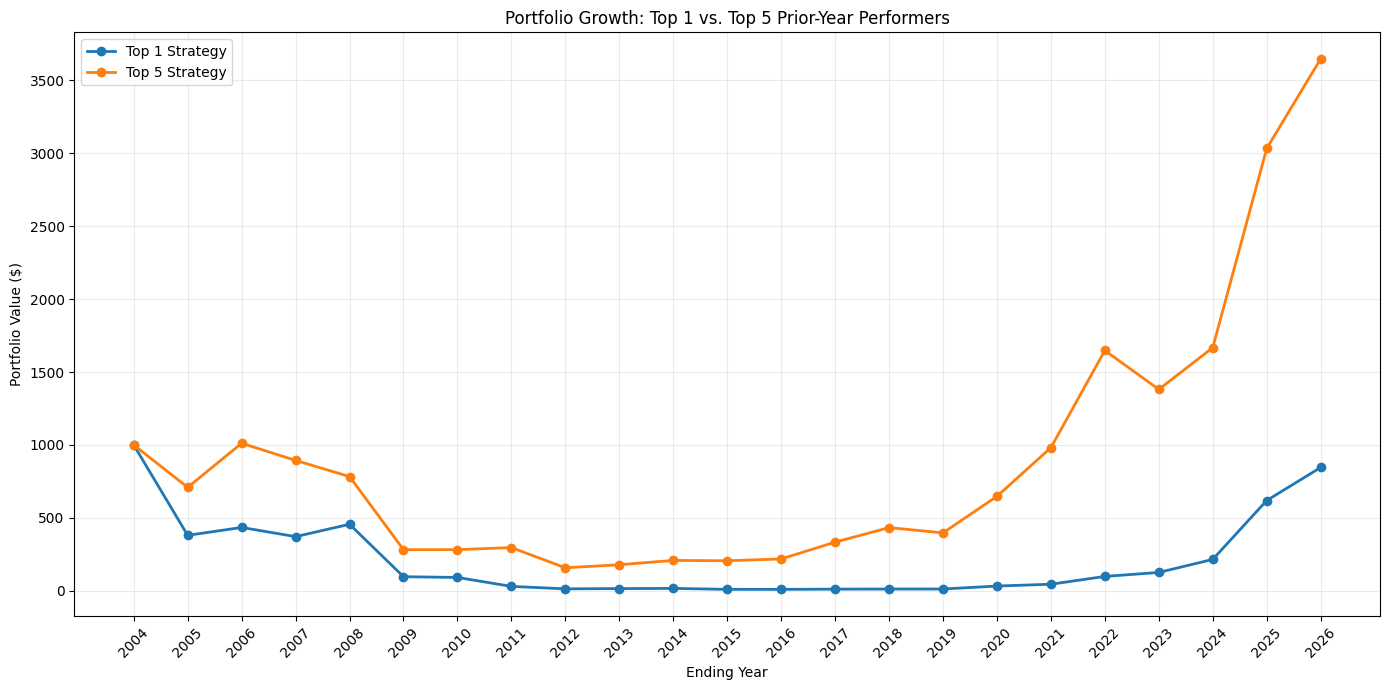

FINAL VALUES:
Top 1 Strategy: $845.71
Top 5 Strategy: $3,646.67

Graph saved to: /content/top_1_vs_top_5_portfolio_growth.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the saved strategy results
top_1_df = pd.read_csv(
    "/content/top_1_strategy_results_2003_2026.csv"
)

top_5_df = pd.read_csv(
    "/content/top_5_strategy_results_2003_2026.csv"
)

# Extract the ending year from each investment period
top_1_df["Year"] = (
    top_1_df["Investment Period"]
    .str.split("-")
    .str[1]
    .astype(int)
)

top_5_df["Year"] = (
    top_5_df["Investment Period"]
    .str.split("-")
    .str[1]
    .astype(int)
)

# Include the original $1,000 starting balance
top_1_years = [2004] + top_1_df["Year"].tolist()
top_1_balances = [1000.00] + top_1_df["Ending Balance"].tolist()

top_5_years = [2004] + top_5_df["Year"].tolist()
top_5_balances = [1000.00] + top_5_df["Ending Balance"].tolist()

# Create the line graph
plt.figure(figsize=(14, 7))

plt.plot(
    top_1_years,
    top_1_balances,
    marker="o",
    linewidth=2,
    label="Top 1 Strategy"
)

plt.plot(
    top_5_years,
    top_5_balances,
    marker="o",
    linewidth=2,
    label="Top 5 Strategy"
)

plt.title(
    "Portfolio Growth: Top 1 vs. Top 5 Prior-Year Performers"
)

plt.xlabel("Ending Year")
plt.ylabel("Portfolio Value ($)")

plt.xticks(
    range(2004, 2027),
    rotation=45
)

plt.grid(
    alpha=0.25
)

plt.legend()
plt.tight_layout()

# Save the graph
graph_path = "/content/top_1_vs_top_5_portfolio_growth.png"

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("FINAL VALUES:")
print(
    f"Top 1 Strategy: "
    f"${top_1_balances[-1]:,.2f}"
)

print(
    f"Top 5 Strategy: "
    f"${top_5_balances[-1]:,.2f}"
)

print(f"\nGraph saved to: {graph_path}")

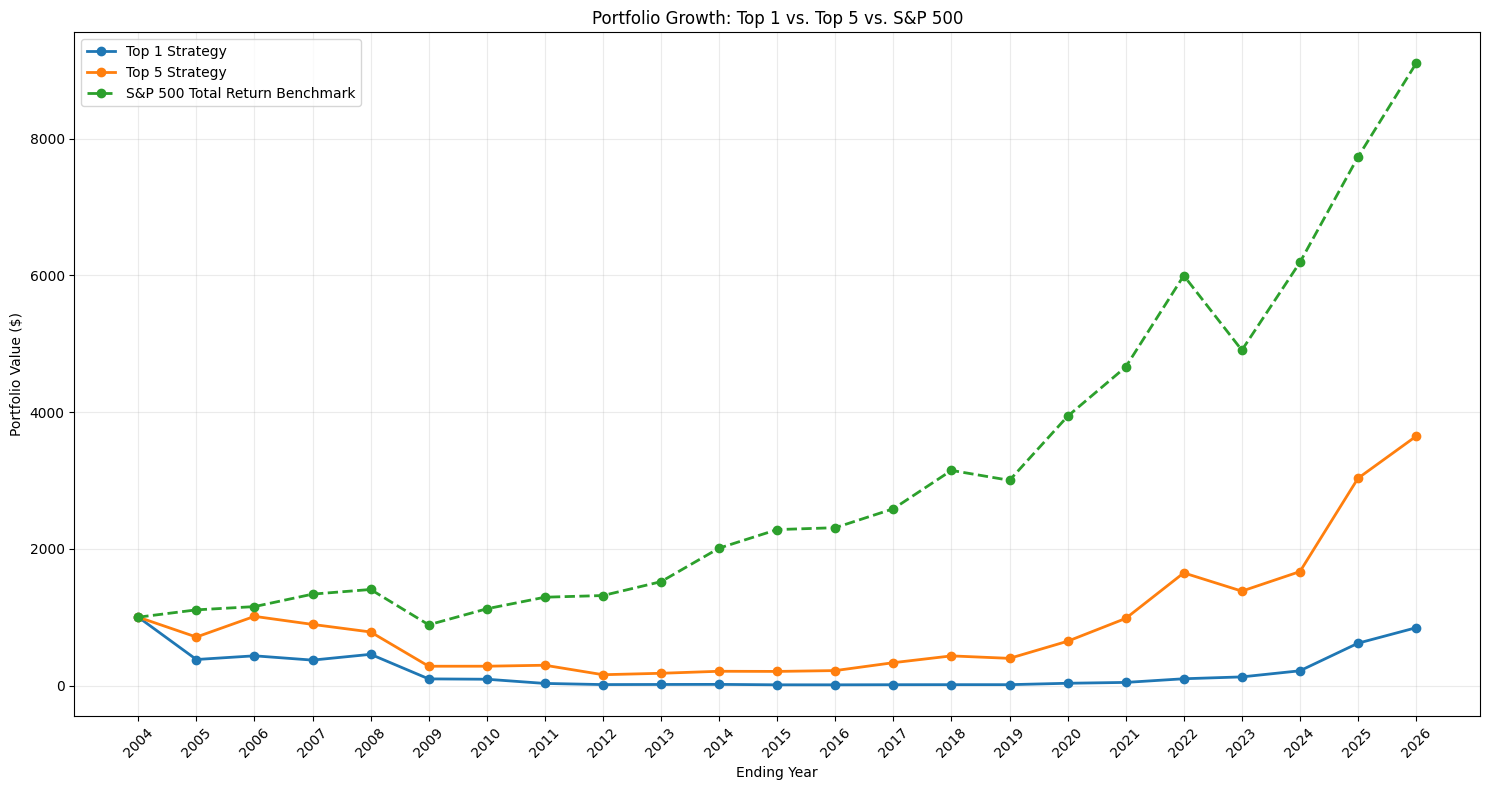

FINAL COMPARISON:
         Strategy  Starting Balance  Final Balance  Total Return (%)
   Top 1 Strategy            1000.0         845.71            -15.43
   Top 5 Strategy            1000.0        3646.67            264.67
S&P 500 Benchmark            1000.0        9101.32            810.13

FILES SAVED:
/content/top_1_vs_top_5_vs_sp500_growth.png
/content/sp500_benchmark_growth.csv
/content/top_1_top_5_sp500_final_comparison.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load saved strategy results
top_1_df = pd.read_csv(
    "/content/top_1_strategy_results_2003_2026.csv"
)

top_5_df = pd.read_csv(
    "/content/top_5_strategy_results_2003_2026.csv"
)

# Extract start and ending years from each investment period
for strategy_df in [top_1_df, top_5_df]:
    strategy_df["Start Year"] = (
        strategy_df["Investment Period"]
        .str.split("-")
        .str[0]
        .astype(int)
    )

    strategy_df["Ending Year"] = (
        strategy_df["Investment Period"]
        .str.split("-")
        .str[1]
        .astype(int)
    )

# S&P 500 annual total returns supplied by the user
sp500_annual_returns = {
    2003: 28.2,
    2004: 10.7,
    2005: 4.3,
    2006: 15.8,
    2007: 5.1,
    2008: -36.8,
    2009: 26.4,
    2010: 15.1,
    2011: 1.9,
    2012: 15.4,
    2013: 32.3,
    2014: 13.5,
    2015: 1.2,
    2016: 12.0,
    2017: 21.7,
    2018: -4.6,
    2019: 31.2,
    2020: 18.3,
    2021: 28.7,
    2022: -18.2,
    2023: 26.2,
    2024: 24.9,
    2025: 17.7
}

starting_balance = 1000.00
benchmark_balance = starting_balance
benchmark_rows = []

# Match each benchmark return to the strategy investment period
for _, row in top_1_df.iterrows():
    start_year = row["Start Year"]
    ending_year = row["Ending Year"]

    annual_return = sp500_annual_returns.get(start_year)

    if annual_return is None:
        raise ValueError(
            f"No S&P 500 benchmark return found for {start_year}"
        )

    starting_year_balance = benchmark_balance

    benchmark_balance *= (
        1 + annual_return / 100
    )

    benchmark_rows.append({
        "Investment Period": row["Investment Period"],
        "Start Year": start_year,
        "Ending Year": ending_year,
        "S&P 500 Return (%)": annual_return,
        "Starting Balance": round(
            starting_year_balance,
            2
        ),
        "Ending Balance": round(
            benchmark_balance,
            2
        )
    })

sp500_benchmark_df = pd.DataFrame(
    benchmark_rows
)

# Create line-graph data
starting_year = int(
    top_1_df["Start Year"].min()
)

top_1_years = (
    [starting_year]
    + top_1_df["Ending Year"].tolist()
)

top_1_balances = (
    [starting_balance]
    + top_1_df["Ending Balance"].tolist()
)

top_5_years = (
    [starting_year]
    + top_5_df["Ending Year"].tolist()
)

top_5_balances = (
    [starting_balance]
    + top_5_df["Ending Balance"].tolist()
)

benchmark_years = (
    [starting_year]
    + sp500_benchmark_df["Ending Year"].tolist()
)

benchmark_balances = (
    [starting_balance]
    + sp500_benchmark_df["Ending Balance"].tolist()
)

# Plot all three lines
plt.figure(figsize=(15, 8))

plt.plot(
    top_1_years,
    top_1_balances,
    marker="o",
    linewidth=2,
    label="Top 1 Strategy"
)

plt.plot(
    top_5_years,
    top_5_balances,
    marker="o",
    linewidth=2,
    label="Top 5 Strategy"
)

plt.plot(
    benchmark_years,
    benchmark_balances,
    marker="o",
    linewidth=2,
    linestyle="--",
    label="S&P 500 Total Return Benchmark"
)

plt.title(
    "Portfolio Growth: Top 1 vs. Top 5 vs. S&P 500"
)

plt.xlabel("Ending Year")
plt.ylabel("Portfolio Value ($)")

plt.xticks(
    range(starting_year, 2027),
    rotation=45
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

# Save graph
graph_path = (
    "/content/"
    "top_1_vs_top_5_vs_sp500_growth.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Create final comparison
final_comparison_df = pd.DataFrame({
    "Strategy": [
        "Top 1 Strategy",
        "Top 5 Strategy",
        "S&P 500 Benchmark"
    ],
    "Starting Balance": [
        starting_balance,
        starting_balance,
        starting_balance
    ],
    "Final Balance": [
        round(top_1_balances[-1], 2),
        round(top_5_balances[-1], 2),
        round(benchmark_balances[-1], 2)
    ]
})

final_comparison_df["Total Return (%)"] = (
    (
        final_comparison_df["Final Balance"]
        / final_comparison_df["Starting Balance"]
    )
    - 1
) * 100

final_comparison_df["Total Return (%)"] = (
    final_comparison_df["Total Return (%)"]
    .round(2)
)

# Save benchmark and comparison data
sp500_benchmark_df.to_csv(
    "/content/sp500_benchmark_growth.csv",
    index=False
)

final_comparison_df.to_csv(
    "/content/top_1_top_5_sp500_final_comparison.csv",
    index=False
)

print("FINAL COMPARISON:")
print(
    final_comparison_df.to_string(
        index=False
    )
)

print("\nFILES SAVED:")
print(graph_path)
print("/content/sp500_benchmark_growth.csv")
print(
    "/content/"
    "top_1_top_5_sp500_final_comparison.csv"
)

In [ ]:
import pandas as pd
from pathlib import Path

# Find and load the current dataset
matching_files = list(
    Path("/content").glob(
        "*sp500_googlefinance_2003_2026*.csv"
    )
)

if not matching_files:
    raise FileNotFoundError(
        "Upload the sp500_googlefinance_2003_2026 CSV "
        "to the current Colab session."
    )

file_path = matching_files[0]

df = pd.read_csv(
    file_path,
    keep_default_na=False
)

df["Symbol"] = (
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2003, 2027))

# Convert prices to numeric
for year in years:
    column = f"Price Jan {year}"

    df[column] = pd.to_numeric(
        df[column].replace(
            {
                "N/A": pd.NA,
                "Not Found": pd.NA,
                "": pd.NA
            }
        ),
        errors="coerce"
    )


def run_ranked_strategy(
    data,
    number_of_stocks,
    select_best,
    starting_balance=1000.00
):
    current_balance = float(starting_balance)
    portfolio_results = []
    stock_details = []

    for investment_year in range(2004, 2026):
        prior_column = f"Price Jan {investment_year - 1}"
        purchase_column = f"Price Jan {investment_year}"
        sale_column = f"Price Jan {investment_year + 1}"

        if current_balance <= 0:
            current_balance = 0.0
            break

        # Require prices for ranking, purchase, and sale
        valid_stocks = data[
            data[prior_column].notna()
            & data[purchase_column].notna()
            & data[sale_column].notna()
            & data[prior_column].gt(0)
            & data[purchase_column].gt(0)
            & data[sale_column].gt(0)
        ].copy()

        if valid_stocks.empty:
            portfolio_results.append(
                {
                    "Investment Period":
                        f"{investment_year}-{investment_year + 1}",
                    "Selected Stocks": "None",
                    "Starting Balance": round(current_balance, 2),
                    "Portfolio Return (%)": 0.00,
                    "Ending Balance": round(current_balance, 2)
                }
            )
            continue

        valid_stocks["Prior Year Return (%)"] = (
            (
                valid_stocks[purchase_column]
                - valid_stocks[prior_column]
            )
            / valid_stocks[prior_column]
            * 100
        )

        selected_stocks = (
            valid_stocks
            .sort_values(
                "Prior Year Return (%)",
                ascending=not select_best
            )
            .head(number_of_stocks)
            .copy()
        )

        period_starting_balance = current_balance

        investment_per_stock = (
            period_starting_balance
            / len(selected_stocks)
        )

        period_ending_balance = 0.0

        for _, stock in selected_stocks.iterrows():
            purchase_price = float(stock[purchase_column])
            sale_price = float(stock[sale_column])

            shares = investment_per_stock / purchase_price
            ending_value = shares * sale_price

            investment_return = (
                sale_price / purchase_price - 1
            ) * 100

            period_ending_balance += ending_value

            stock_details.append(
                {
                    "Investment Period":
                        f"{investment_year}-{investment_year + 1}",
                    "Symbol": stock["Symbol"],
                    "Prior Year Return (%)": round(
                        stock["Prior Year Return (%)"],
                        2
                    ),
                    "Purchase Price": round(purchase_price, 2),
                    "Sale Price": round(sale_price, 2),
                    "Amount Invested": round(
                        investment_per_stock,
                        2
                    ),
                    "Investment Return (%)": round(
                        investment_return,
                        2
                    ),
                    "Ending Value": round(ending_value, 2)
                }
            )

        portfolio_return = (
            period_ending_balance
            / period_starting_balance
            - 1
        ) * 100

        current_balance = max(
            0.0,
            period_ending_balance
        )

        portfolio_results.append(
            {
                "Investment Period":
                    f"{investment_year}-{investment_year + 1}",
                "Selected Stocks": ", ".join(
                    selected_stocks["Symbol"].astype(str)
                ),
                "Starting Balance": round(
                    period_starting_balance,
                    2
                ),
                "Investment Per Stock": round(
                    investment_per_stock,
                    2
                ),
                "Portfolio Return (%)": round(
                    portfolio_return,
                    2
                ),
                "Ending Balance": round(
                    current_balance,
                    2
                )
            }
        )

    return (
        pd.DataFrame(portfolio_results),
        pd.DataFrame(stock_details),
        current_balance
    )


# Recreate all six strategy DataFrames
top_1_df, top_1_details_df, top_1_final = (
    run_ranked_strategy(df, 1, True)
)

top_5_df, top_5_details_df, top_5_final = (
    run_ranked_strategy(df, 5, True)
)

top_10_df, top_10_details_df, top_10_final = (
    run_ranked_strategy(df, 10, True)
)

worst_1_df, worst_1_details_df, worst_1_final = (
    run_ranked_strategy(df, 1, False)
)

worst_5_df, worst_5_details_df, worst_5_final = (
    run_ranked_strategy(df, 5, False)
)

worst_10_df, worst_10_details_df, worst_10_final = (
    run_ranked_strategy(df, 10, False)
)

print(f"Loaded: {file_path.name}")

print("\nFINAL BALANCES:")
print(f"Top 1: ${top_1_final:,.2f}")
print(f"Top 5: ${top_5_final:,.2f}")
print(f"Top 10: ${top_10_final:,.2f}")
print(f"Worst 1: ${worst_1_final:,.2f}")
print(f"Worst 5: ${worst_5_final:,.2f}")
print(f"Worst 10: ${worst_10_final:,.2f}")

print("\nworst_1_df recreated successfully:")
print(worst_1_df.head().to_string(index=False))

Loaded: sp500_googlefinance_2003_2026 - sp500_googlefinance_2003_2026.csv

FINAL BALANCES:
Top 1: $845.71
Top 5: $3,646.67
Top 10: $17,055.51
Worst 1: $4,971.76
Worst 5: $19,458.38
Worst 10: $18,924.19

worst_1_df recreated successfully:
Investment Period Selected Stocks  Starting Balance  Investment Per Stock  Portfolio Return (%)  Ending Balance
        2004-2005             TEG           1000.00               1000.00                 14.58         1145.83
        2005-2006              EP           1145.83               1145.83                 50.28         1721.99
        2006-2007              RX           1721.99               1721.99                280.00         6543.55
        2007-2008             RHT           6543.55               6543.55                  0.00         6543.55
        2008-2009              XL           6543.55               6543.55                -94.35          369.39


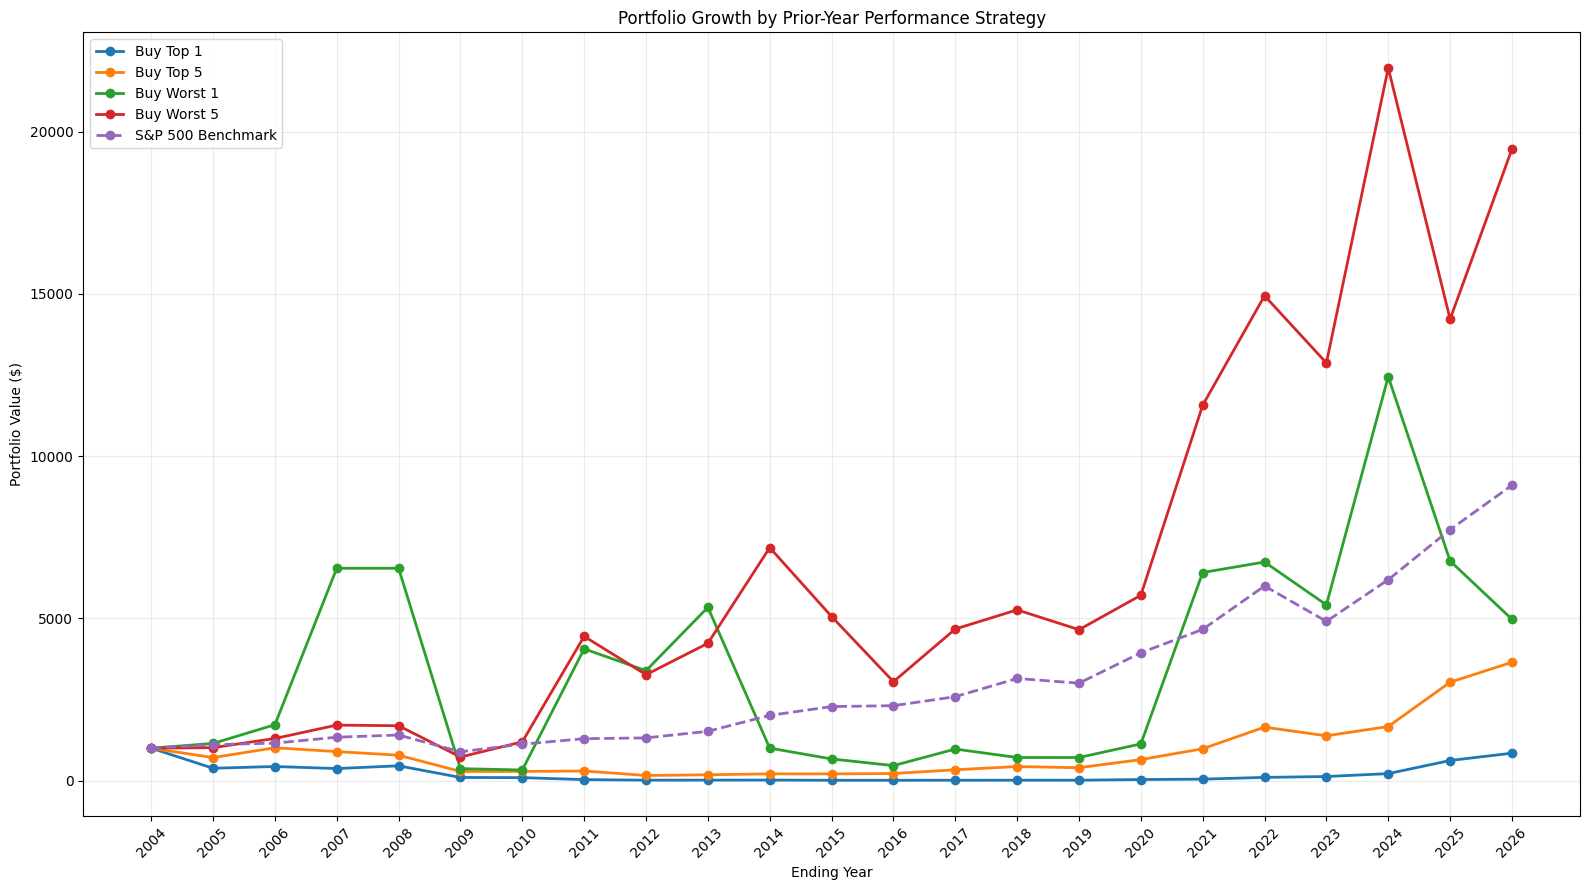

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

starting_balance = 1000.00
starting_year = 2004
ending_year = 2026

# S&P 500 annual total returns
sp500_annual_returns = {
    2004: 10.7,
    2005: 4.3,
    2006: 15.8,
    2007: 5.1,
    2008: -36.8,
    2009: 26.4,
    2010: 15.1,
    2011: 1.9,
    2012: 15.4,
    2013: 32.3,
    2014: 13.5,
    2015: 1.2,
    2016: 12.0,
    2017: 21.7,
    2018: -4.6,
    2019: 31.2,
    2020: 18.3,
    2021: 28.7,
    2022: -18.2,
    2023: 26.2,
    2024: 24.9,
    2025: 17.7
}


def prepare_strategy_line(strategy_df):
    strategy_df = strategy_df.copy()

    strategy_df["Ending Year"] = (
        strategy_df["Investment Period"]
        .str.split("-")
        .str[1]
        .astype(int)
    )

    graph_years = [starting_year]
    graph_balances = [starting_balance]

    for _, row in strategy_df.iterrows():
        graph_years.append(
            int(row["Ending Year"])
        )

        graph_balances.append(
            float(row["Ending Balance"])
        )

    # Extend stopped strategies through 2026
    last_year = graph_years[-1]
    last_balance = graph_balances[-1]

    for year in range(last_year + 1, ending_year + 1):
        graph_years.append(year)
        graph_balances.append(last_balance)

    return graph_years, graph_balances


# Prepare four strategy lines
top_1_years, top_1_balances = prepare_strategy_line(
    top_1_df
)

top_5_years, top_5_balances = prepare_strategy_line(
    top_5_df
)

worst_1_years, worst_1_balances = prepare_strategy_line(
    worst_1_df
)

worst_5_years, worst_5_balances = prepare_strategy_line(
    worst_5_df
)

# Recreate S&P 500 benchmark
benchmark_balance = starting_balance

benchmark_years = [starting_year]
benchmark_balances = [starting_balance]
benchmark_rows = []

for year in range(starting_year, ending_year):
    annual_return = sp500_annual_returns[year]
    period_starting_balance = benchmark_balance

    benchmark_balance *= (
        1 + annual_return / 100
    )

    benchmark_rows.append({
        "Investment Period": f"{year}-{year + 1}",
        "S&P 500 Return (%)": annual_return,
        "Starting Balance": round(
            period_starting_balance,
            2
        ),
        "Ending Balance": round(
            benchmark_balance,
            2
        )
    })

    benchmark_years.append(year + 1)
    benchmark_balances.append(benchmark_balance)

benchmark_df = pd.DataFrame(
    benchmark_rows
)

# Plot all strategies and benchmark
plt.figure(figsize=(16, 9))

plt.plot(
    top_1_years,
    top_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 1"
)

plt.plot(
    top_5_years,
    top_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 5"
)

plt.plot(
    worst_1_years,
    worst_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 1"
)

plt.plot(
    worst_5_years,
    worst_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 5"
)

plt.plot(
    benchmark_years,
    benchmark_balances,
    marker="o",
    linewidth=2,
    linestyle="--",
    label="S&P 500 Benchmark"
)

plt.title(
    "Portfolio Growth by Prior-Year Performance Strategy"
)

plt.xlabel("Ending Year")
plt.ylabel("Portfolio Value ($)")

plt.xticks(
    range(starting_year, ending_year + 1),
    rotation=45
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

# Save graph
graph_path = (
    "/content/all_four_strategies_vs_sp500.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Final comparison
final_comparison_df = pd.DataFrame({
    "Strategy": [
        "Buy Top 1",
        "Buy Top 5",
        "Buy Worst 1"],})


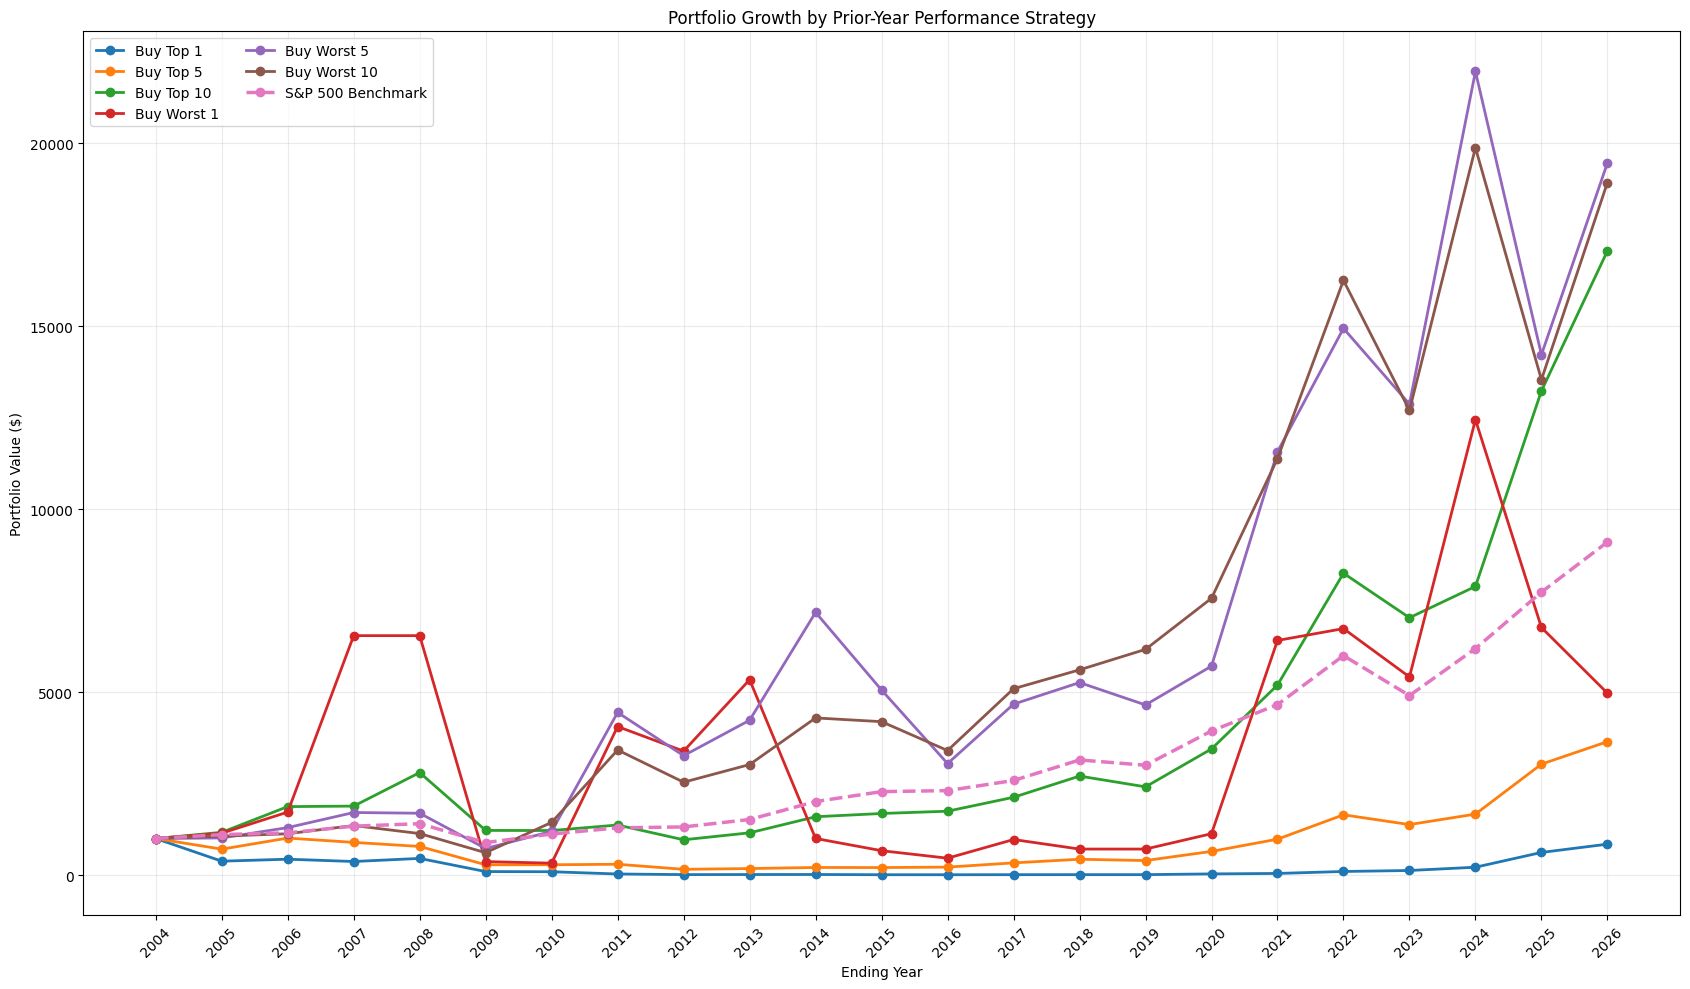

FINAL STRATEGY COMPARISON:
         Strategy  Starting Balance  Final Balance  Total Return (%)
      Buy Worst 5            1000.0       19458.38           1845.84
     Buy Worst 10            1000.0       18924.19           1792.42
       Buy Top 10            1000.0       17055.51           1605.55
S&P 500 Benchmark            1000.0        9101.32            810.13
      Buy Worst 1            1000.0        4971.76            397.18
        Buy Top 5            1000.0        3646.67            264.67
        Buy Top 1            1000.0         845.71            -15.43

FILES SAVED:
/content/top_worst_1_5_10_vs_sp500.png
/content/top_10_strategy_results.csv
/content/top_10_strategy_details.csv
/content/worst_10_strategy_results.csv
/content/worst_10_strategy_details.csv
/content/all_1_5_10_strategies_comparison.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. LOAD PRICE DATA
# ============================================================

file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(
    file_path,
    keep_default_na=False
)

df["Symbol"] = (
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2003, 2027))

# Convert valid prices to numeric
for year in years:
    column = f"Price Jan {year}"

    df[column] = pd.to_numeric(
        df[column].replace({
            "N/A": pd.NA,
            "Not Found": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )


# ============================================================
# 2. STRATEGY FUNCTION
# ============================================================

def run_ranked_strategy(
    data,
    number_of_stocks,
    select_best=True,
    starting_balance=1000.00
):
    current_balance = float(starting_balance)
    portfolio_results = []
    stock_details = []

    # Prior-year performance selects stocks purchased that January
    for selection_year in range(2004, 2026):
        prior_column = f"Price Jan {selection_year - 1}"
        purchase_column = f"Price Jan {selection_year}"
        sale_column = f"Price Jan {selection_year + 1}"

        if current_balance <= 0:
            current_balance = 0.0
            break

        # Require valid prices for ranking, purchase, and sale
        valid_stocks = data[
            data[prior_column].notna()
            & data[purchase_column].notna()
            & data[sale_column].notna()
            & data[prior_column].gt(0)
            & data[purchase_column].gt(0)
            & data[sale_column].gt(0)
        ].copy()

        if valid_stocks.empty:
            portfolio_results.append({
                "Selection Period":
                    f"{selection_year - 1}-{selection_year}",
                "Investment Period":
                    f"{selection_year}-{selection_year + 1}",
                "Number of Stocks": 0,
                "Selected Stocks": "None",
                "Starting Balance": round(current_balance, 2),
                "Investment Per Stock": 0.00,
                "Portfolio Return (%)": 0.00,
                "Ending Balance": round(current_balance, 2)
            })

            continue

        # Calculate prior-year performance
        valid_stocks["Prior Year Return (%)"] = (
            (
                valid_stocks[purchase_column]
                - valid_stocks[prior_column]
            )
            / valid_stocks[prior_column]
            * 100
        )

        # Select best or worst performers
        selected_stocks = (
            valid_stocks
            .sort_values(
                "Prior Year Return (%)",
                ascending=not select_best
            )
            .head(number_of_stocks)
            .copy()
        )

        period_starting_balance = current_balance
        number_selected = len(selected_stocks)

        investment_per_stock = (
            period_starting_balance / number_selected
        )

        period_ending_balance = 0.0

        for _, stock in selected_stocks.iterrows():
            symbol = stock["Symbol"]
            purchase_price = float(stock[purchase_column])
            sale_price = float(stock[sale_column])

            shares_purchased = (
                investment_per_stock / purchase_price
            )

            ending_value = (
                shares_purchased * sale_price
            )

            investment_return = (
                (sale_price - purchase_price)
                / purchase_price
                * 100
            )

            period_ending_balance += ending_value

            stock_details.append({
                "Selection Period":
                    f"{selection_year - 1}-{selection_year}",
                "Investment Period":
                    f"{selection_year}-{selection_year + 1}",
                "Symbol": symbol,
                "Prior Year Return (%)": round(
                    stock["Prior Year Return (%)"],
                    2
                ),
                "Purchase Price": round(purchase_price, 2),
                "Sale Price": round(sale_price, 2),
                "Amount Invested": round(
                    investment_per_stock,
                    2
                ),
                "Shares Purchased": round(
                    shares_purchased,
                    6
                ),
                "Investment Return (%)": round(
                    investment_return,
                    2
                ),
                "Ending Value": round(ending_value, 2)
            })

        period_ending_balance = max(
            0.0,
            period_ending_balance
        )

        portfolio_return = (
            period_ending_balance
            / period_starting_balance
            - 1
        ) * 100

        portfolio_results.append({
            "Selection Period":
                f"{selection_year - 1}-{selection_year}",
            "Investment Period":
                f"{selection_year}-{selection_year + 1}",
            "Number of Stocks": number_selected,
            "Selected Stocks": ", ".join(
                selected_stocks["Symbol"].astype(str)
            ),
            "Starting Balance": round(
                period_starting_balance,
                2
            ),
            "Investment Per Stock": round(
                investment_per_stock,
                2
            ),
            "Portfolio Return (%)": round(
                portfolio_return,
                2
            ),
            "Ending Balance": round(
                period_ending_balance,
                2
            )
        })

        current_balance = period_ending_balance

    return (
        pd.DataFrame(portfolio_results),
        pd.DataFrame(stock_details),
        current_balance
    )


# ============================================================
# 3. RUN ALL SIX STRATEGIES
# ============================================================

top_1_df, top_1_details_df, top_1_final = (
    run_ranked_strategy(df, 1, True)
)

top_5_df, top_5_details_df, top_5_final = (
    run_ranked_strategy(df, 5, True)
)

top_10_df, top_10_details_df, top_10_final = (
    run_ranked_strategy(df, 10, True)
)

worst_1_df, worst_1_details_df, worst_1_final = (
    run_ranked_strategy(df, 1, False)
)

worst_5_df, worst_5_details_df, worst_5_final = (
    run_ranked_strategy(df, 5, False)
)

worst_10_df, worst_10_details_df, worst_10_final = (
    run_ranked_strategy(df, 10, False)
)


# ============================================================
# 4. S&P 500 BENCHMARK
# ============================================================

sp500_annual_returns = {
    2004: 10.7,
    2005: 4.3,
    2006: 15.8,
    2007: 5.1,
    2008: -36.8,
    2009: 26.4,
    2010: 15.1,
    2011: 1.9,
    2012: 15.4,
    2013: 32.3,
    2014: 13.5,
    2015: 1.2,
    2016: 12.0,
    2017: 21.7,
    2018: -4.6,
    2019: 31.2,
    2020: 18.3,
    2021: 28.7,
    2022: -18.2,
    2023: 26.2,
    2024: 24.9,
    2025: 17.7
}

starting_balance = 1000.00
benchmark_balance = starting_balance

benchmark_years = [2004]
benchmark_balances = [starting_balance]
benchmark_rows = []

for year in range(2004, 2026):
    annual_return = sp500_annual_returns[year]
    period_starting_balance = benchmark_balance

    benchmark_balance *= (
        1 + annual_return / 100
    )

    benchmark_rows.append({
        "Investment Period": f"{year}-{year + 1}",
        "S&P 500 Return (%)": annual_return,
        "Starting Balance": round(
            period_starting_balance,
            2
        ),
        "Ending Balance": round(
            benchmark_balance,
            2
        )
    })

    benchmark_years.append(year + 1)
    benchmark_balances.append(benchmark_balance)

benchmark_df = pd.DataFrame(benchmark_rows)


# ============================================================
# 5. PREPARE LINE DATA
# ============================================================

def prepare_line_data(strategy_df):
    strategy_df = strategy_df.copy()

    strategy_df["Ending Year"] = (
        strategy_df["Investment Period"]
        .str.split("-")
        .str[1]
        .astype(int)
    )

    graph_years = (
        [2004]
        + strategy_df["Ending Year"].tolist()
    )

    graph_balances = (
        [starting_balance]
        + strategy_df["Ending Balance"].tolist()
    )

    # Extend stopped strategies through 2026
    last_year = graph_years[-1]
    last_balance = graph_balances[-1]

    for year in range(last_year + 1, 2027):
        graph_years.append(year)
        graph_balances.append(last_balance)

    return graph_years, graph_balances


top_1_years, top_1_balances = prepare_line_data(top_1_df)
top_5_years, top_5_balances = prepare_line_data(top_5_df)
top_10_years, top_10_balances = prepare_line_data(top_10_df)

worst_1_years, worst_1_balances = prepare_line_data(
    worst_1_df
)

worst_5_years, worst_5_balances = prepare_line_data(
    worst_5_df
)

worst_10_years, worst_10_balances = prepare_line_data(
    worst_10_df
)


# ============================================================
# 6. PLOT ALL STRATEGIES
# ============================================================

plt.figure(figsize=(17, 10))

plt.plot(
    top_1_years,
    top_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 1"
)

plt.plot(
    top_5_years,
    top_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 5"
)

plt.plot(
    top_10_years,
    top_10_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 10"
)

plt.plot(
    worst_1_years,
    worst_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 1"
)

plt.plot(
    worst_5_years,
    worst_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 5"
)

plt.plot(
    worst_10_years,
    worst_10_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 10"
)

plt.plot(
    benchmark_years,
    benchmark_balances,
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="S&P 500 Benchmark"
)

plt.title(
    "Portfolio Growth by Prior-Year Performance Strategy"
)

plt.xlabel("Ending Year")
plt.ylabel("Portfolio Value ($)")

plt.xticks(
    range(2004, 2027),
    rotation=45
)

plt.grid(alpha=0.25)

plt.legend(
    loc="upper left",
    ncol=2
)

plt.tight_layout()

graph_path = (
    "/content/"
    "top_worst_1_5_10_vs_sp500.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FINAL COMPARISON
# ============================================================

final_comparison_df = pd.DataFrame({
    "Strategy": [
        "Buy Top 1",
        "Buy Top 5",
        "Buy Top 10",
        "Buy Worst 1",
        "Buy Worst 5",
        "Buy Worst 10",
        "S&P 500 Benchmark"
    ],
    "Starting Balance": [
        starting_balance
    ] * 7,
    "Final Balance": [
        round(top_1_final, 2),
        round(top_5_final, 2),
        round(top_10_final, 2),
        round(worst_1_final, 2),
        round(worst_5_final, 2),
        round(worst_10_final, 2),
        round(benchmark_balance, 2)
    ]
})

final_comparison_df["Total Return (%)"] = (
    (
        final_comparison_df["Final Balance"]
        / final_comparison_df["Starting Balance"]
    )
    - 1
) * 100

final_comparison_df["Total Return (%)"] = (
    final_comparison_df["Total Return (%)"]
    .round(2)
)

final_comparison_df = (
    final_comparison_df
    .sort_values(
        "Final Balance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. SAVE RESULTS
# ============================================================

top_10_df.to_csv(
    "/content/top_10_strategy_results.csv",
    index=False
)

top_10_details_df.to_csv(
    "/content/top_10_strategy_details.csv",
    index=False
)

worst_10_df.to_csv(
    "/content/worst_10_strategy_results.csv",
    index=False
)

worst_10_details_df.to_csv(
    "/content/worst_10_strategy_details.csv",
    index=False
)

final_comparison_df.to_csv(
    "/content/all_1_5_10_strategies_comparison.csv",
    index=False
)

print("FINAL STRATEGY COMPARISON:")
print(final_comparison_df.to_string(index=False))

print("\nFILES SAVED:")
print(graph_path)
print("/content/top_10_strategy_results.csv")
print("/content/top_10_strategy_details.csv")
print("/content/worst_10_strategy_results.csv")
print("/content/worst_10_strategy_details.csv")
print("/content/all_1_5_10_strategies_comparison.csv")

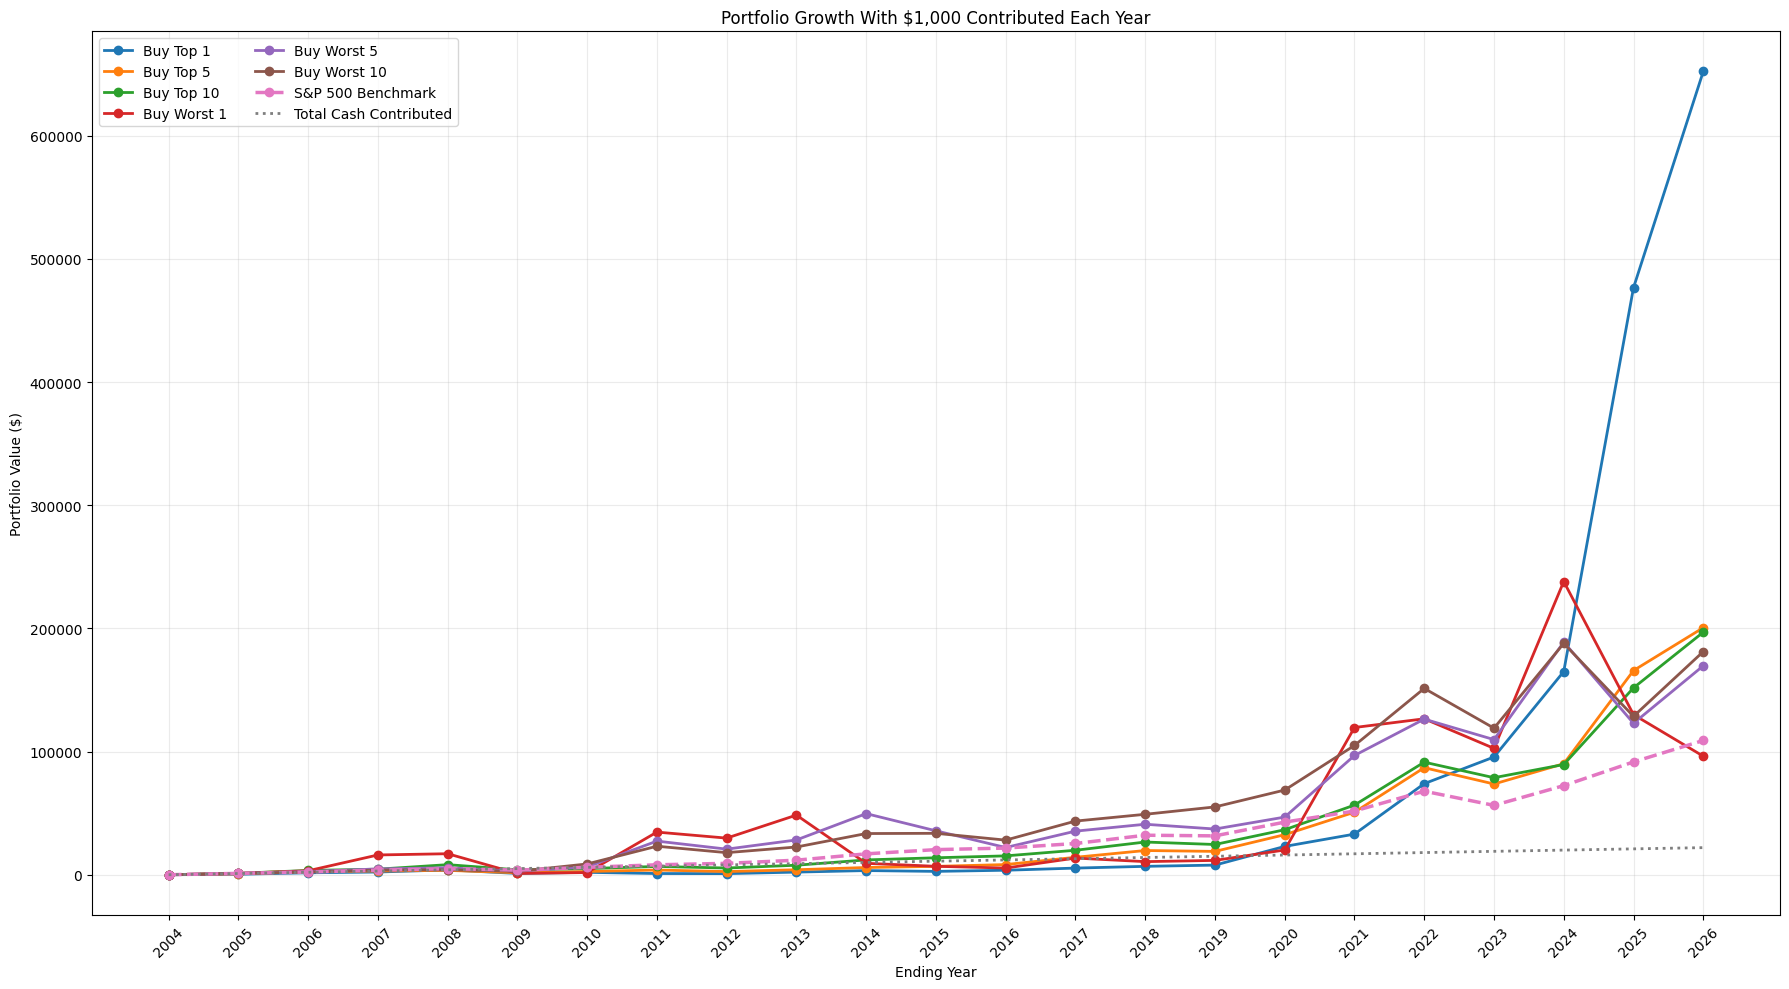

FINAL COMPARISON WITH ANNUAL CONTRIBUTIONS:
         Strategy  Total Contributions  Final Balance  Net Gain/Loss  Gain on Contributions (%)
        Buy Top 1              22000.0      652098.19      630098.19                    2864.08
        Buy Top 5              22000.0      200546.69      178546.69                     811.58
       Buy Top 10              22000.0      196890.70      174890.70                     794.96
     Buy Worst 10              22000.0      181149.84      159149.84                     723.41
      Buy Worst 5              22000.0      169619.95      147619.95                     671.00
S&P 500 Benchmark              22000.0      108977.69       86977.69                     395.35
      Buy Worst 1              22000.0       96239.01       74239.01                     337.45

FILES SAVED:
/content/annual_1000_contributions_all_strategies.png
/content/annual_1000_contributions_final_comparison.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. LOAD AND CLEAN PRICE DATA
# ============================================================

file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(
    file_path,
    keep_default_na=False
)

df["Symbol"] = (
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2003, 2027))

for year in years:
    column = f"Price Jan {year}"

    df[column] = pd.to_numeric(
        df[column].replace({
            "N/A": pd.NA,
            "Not Found": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )


# ============================================================
# 2. STRATEGY FUNCTION WITH ANNUAL CONTRIBUTIONS
# ============================================================

def run_ranked_strategy_with_contributions(
    data,
    number_of_stocks,
    select_best=True,
    annual_contribution=1000.00
):
    current_balance = 0.0
    total_contributions = 0.0

    portfolio_results = []
    stock_details = []

    # 2003-2004 performance selects stocks purchased in Jan 2004.
    # The first $1,000 contribution is made in Jan 2004.
    for selection_year in range(2004, 2026):
        prior_column = f"Price Jan {selection_year - 1}"
        purchase_column = f"Price Jan {selection_year}"
        sale_column = f"Price Jan {selection_year + 1}"

        # Add $1,000 before making the annual investment
        rolled_balance = current_balance
        total_contributions += annual_contribution

        available_balance = (
            rolled_balance + annual_contribution
        )

        valid_stocks = data[
            data[prior_column].notna()
            & data[purchase_column].notna()
            & data[sale_column].notna()
            & data[prior_column].gt(0)
            & data[purchase_column].gt(0)
            & data[sale_column].gt(0)
        ].copy()

        if valid_stocks.empty:
            current_balance = available_balance

            portfolio_results.append({
                "Selection Period":
                    f"{selection_year - 1}-{selection_year}",
                "Investment Period":
                    f"{selection_year}-{selection_year + 1}",
                "Number of Stocks": 0,
                "Selected Stocks": "None",
                "Rolled Balance": round(rolled_balance, 2),
                "Annual Contribution": round(
                    annual_contribution,
                    2
                ),
                "Total Contributions": round(
                    total_contributions,
                    2
                ),
                "Amount Invested": round(
                    available_balance,
                    2
                ),
                "Portfolio Return (%)": 0.00,
                "Ending Balance": round(
                    current_balance,
                    2
                )
            })

            continue

        # Calculate prior-year performance used for selection
        valid_stocks["Prior Year Return (%)"] = (
            (
                valid_stocks[purchase_column]
                - valid_stocks[prior_column]
            )
            / valid_stocks[prior_column]
            * 100
        )

        selected_stocks = (
            valid_stocks
            .sort_values(
                "Prior Year Return (%)",
                ascending=not select_best
            )
            .head(number_of_stocks)
            .copy()
        )

        number_selected = len(selected_stocks)

        investment_per_stock = (
            available_balance / number_selected
        )

        period_ending_balance = 0.0

        for _, stock in selected_stocks.iterrows():
            symbol = stock["Symbol"]

            purchase_price = float(
                stock[purchase_column]
            )

            sale_price = float(
                stock[sale_column]
            )

            shares_purchased = (
                investment_per_stock / purchase_price
            )

            ending_value = (
                shares_purchased * sale_price
            )

            investment_return = (
                (sale_price - purchase_price)
                / purchase_price
                * 100
            )

            period_ending_balance += ending_value

            stock_details.append({
                "Selection Period":
                    f"{selection_year - 1}-{selection_year}",
                "Investment Period":
                    f"{selection_year}-{selection_year + 1}",
                "Symbol": symbol,
                "Prior Year Return (%)": round(
                    stock["Prior Year Return (%)"],
                    2
                ),
                "Purchase Price": round(
                    purchase_price,
                    2
                ),
                "Sale Price": round(
                    sale_price,
                    2
                ),
                "Amount Invested": round(
                    investment_per_stock,
                    2
                ),
                "Shares Purchased": round(
                    shares_purchased,
                    6
                ),
                "Investment Return (%)": round(
                    investment_return,
                    2
                ),
                "Ending Value": round(
                    ending_value,
                    2
                )
            })

        portfolio_return = (
            period_ending_balance
            / available_balance
            - 1
        ) * 100

        current_balance = period_ending_balance

        portfolio_results.append({
            "Selection Period":
                f"{selection_year - 1}-{selection_year}",
            "Investment Period":
                f"{selection_year}-{selection_year + 1}",
            "Number of Stocks": number_selected,
            "Selected Stocks": ", ".join(
                selected_stocks["Symbol"].astype(str)
            ),
            "Rolled Balance": round(
                rolled_balance,
                2
            ),
            "Annual Contribution": round(
                annual_contribution,
                2
            ),
            "Total Contributions": round(
                total_contributions,
                2
            ),
            "Amount Invested": round(
                available_balance,
                2
            ),
            "Investment Per Stock": round(
                investment_per_stock,
                2
            ),
            "Portfolio Return (%)": round(
                portfolio_return,
                2
            ),
            "Ending Balance": round(
                current_balance,
                2
            )
        })

    return (
        pd.DataFrame(portfolio_results),
        pd.DataFrame(stock_details),
        current_balance,
        total_contributions
    )


# ============================================================
# 3. RUN ALL SIX STRATEGIES
# ============================================================

top_1_contrib_df, top_1_contrib_details_df, top_1_final, total_added = (
    run_ranked_strategy_with_contributions(
        df,
        number_of_stocks=1,
        select_best=True
    )
)

top_5_contrib_df, top_5_contrib_details_df, top_5_final, _ = (
    run_ranked_strategy_with_contributions(
        df,
        number_of_stocks=5,
        select_best=True
    )
)

top_10_contrib_df, top_10_contrib_details_df, top_10_final, _ = (
    run_ranked_strategy_with_contributions(
        df,
        number_of_stocks=10,
        select_best=True
    )
)

worst_1_contrib_df, worst_1_contrib_details_df, worst_1_final, _ = (
    run_ranked_strategy_with_contributions(
        df,
        number_of_stocks=1,
        select_best=False
    )
)

worst_5_contrib_df, worst_5_contrib_details_df, worst_5_final, _ = (
    run_ranked_strategy_with_contributions(
        df,
        number_of_stocks=5,
        select_best=False
    )
)

worst_10_contrib_df, worst_10_contrib_details_df, worst_10_final, _ = (
    run_ranked_strategy_with_contributions(
        df,
        number_of_stocks=10,
        select_best=False
    )
)


# ============================================================
# 4. S&P 500 BENCHMARK WITH $1,000 ADDED EACH YEAR
# ============================================================

sp500_annual_returns = {
    2004: 10.7,
    2005: 4.3,
    2006: 15.8,
    2007: 5.1,
    2008: -36.8,
    2009: 26.4,
    2010: 15.1,
    2011: 1.9,
    2012: 15.4,
    2013: 32.3,
    2014: 13.5,
    2015: 1.2,
    2016: 12.0,
    2017: 21.7,
    2018: -4.6,
    2019: 31.2,
    2020: 18.3,
    2021: 28.7,
    2022: -18.2,
    2023: 26.2,
    2024: 24.9,
    2025: 17.7
}

annual_contribution = 1000.00
benchmark_balance = 0.0
benchmark_total_contributions = 0.0
benchmark_rows = []

for year in range(2004, 2026):
    rolled_balance = benchmark_balance

    benchmark_total_contributions += annual_contribution

    available_balance = (
        rolled_balance + annual_contribution
    )

    annual_return = sp500_annual_returns[year]

    benchmark_balance = (
        available_balance
        * (1 + annual_return / 100)
    )

    benchmark_rows.append({
        "Investment Period": f"{year}-{year + 1}",
        "Rolled Balance": round(
            rolled_balance,
            2
        ),
        "Annual Contribution": round(
            annual_contribution,
            2
        ),
        "Total Contributions": round(
            benchmark_total_contributions,
            2
        ),
        "Amount Invested": round(
            available_balance,
            2
        ),
        "S&P 500 Return (%)": annual_return,
        "Ending Balance": round(
            benchmark_balance,
            2
        )
    })

benchmark_contrib_df = pd.DataFrame(
    benchmark_rows
)


# ============================================================
# 5. PREPARE GRAPH DATA
# ============================================================

def prepare_contribution_line(strategy_df):
    graph_years = [2004]

    # Beginning value before the first contribution
    graph_balances = [0.0]

    strategy_copy = strategy_df.copy()

    strategy_copy["Ending Year"] = (
        strategy_copy["Investment Period"]
        .str.split("-")
        .str[1]
        .astype(int)
    )

    graph_years.extend(
        strategy_copy["Ending Year"].tolist()
    )

    graph_balances.extend(
        strategy_copy["Ending Balance"].tolist()
    )

    return graph_years, graph_balances


top_1_years, top_1_balances = prepare_contribution_line(
    top_1_contrib_df
)

top_5_years, top_5_balances = prepare_contribution_line(
    top_5_contrib_df
)

top_10_years, top_10_balances = prepare_contribution_line(
    top_10_contrib_df
)

worst_1_years, worst_1_balances = prepare_contribution_line(
    worst_1_contrib_df
)

worst_5_years, worst_5_balances = prepare_contribution_line(
    worst_5_contrib_df
)

worst_10_years, worst_10_balances = prepare_contribution_line(
    worst_10_contrib_df
)

benchmark_years = (
    [2004]
    + list(range(2005, 2027))
)

benchmark_balances = (
    [0.0]
    + benchmark_contrib_df["Ending Balance"].tolist()
)

# Total cash contributed by each point
contribution_years = list(range(2004, 2027))

contribution_line = [
    0.0
] + [
    annual_contribution * count
    for count in range(1, 23)
]


# ============================================================
# 6. PLOT UPDATED GRAPH
# ============================================================

plt.figure(figsize=(18, 10))

plt.plot(
    top_1_years,
    top_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 1"
)

plt.plot(
    top_5_years,
    top_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 5"
)

plt.plot(
    top_10_years,
    top_10_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 10"
)

plt.plot(
    worst_1_years,
    worst_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 1"
)

plt.plot(
    worst_5_years,
    worst_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 5"
)

plt.plot(
    worst_10_years,
    worst_10_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 10"
)

plt.plot(
    benchmark_years,
    benchmark_balances,
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="S&P 500 Benchmark"
)

# Shows total cash contributed without investment growth
plt.plot(
    contribution_years,
    contribution_line,
    linewidth=2,
    linestyle=":",
    label="Total Cash Contributed"
)

plt.title(
    "Portfolio Growth With $1,000 Contributed Each Year"
)

plt.xlabel("Ending Year")
plt.ylabel("Portfolio Value ($)")

plt.xticks(
    range(2004, 2027),
    rotation=45
)

plt.grid(alpha=0.25)

plt.legend(
    loc="upper left",
    ncol=2
)

plt.tight_layout()

graph_path = (
    "/content/"
    "annual_1000_contributions_all_strategies.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FINAL COMPARISON
# ============================================================

final_comparison_df = pd.DataFrame({
    "Strategy": [
        "Buy Top 1",
        "Buy Top 5",
        "Buy Top 10",
        "Buy Worst 1",
        "Buy Worst 5",
        "Buy Worst 10",
        "S&P 500 Benchmark"
    ],
    "Total Contributions": [
        total_added
    ] * 7,
    "Final Balance": [
        round(top_1_final, 2),
        round(top_5_final, 2),
        round(top_10_final, 2),
        round(worst_1_final, 2),
        round(worst_5_final, 2),
        round(worst_10_final, 2),
        round(benchmark_balance, 2)
    ]
})

final_comparison_df["Net Gain/Loss"] = (
    final_comparison_df["Final Balance"]
    - final_comparison_df["Total Contributions"]
).round(2)

final_comparison_df["Gain on Contributions (%)"] = (
    (
        final_comparison_df["Final Balance"]
        / final_comparison_df["Total Contributions"]
    )
    - 1
) * 100

final_comparison_df["Gain on Contributions (%)"] = (
    final_comparison_df[
        "Gain on Contributions (%)"
    ].round(2)
)

final_comparison_df = (
    final_comparison_df
    .sort_values(
        "Final Balance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. SAVE RESULTS
# ============================================================

final_comparison_path = (
    "/content/"
    "annual_1000_contributions_final_comparison.csv"
)

final_comparison_df.to_csv(
    final_comparison_path,
    index=False
)

top_1_contrib_df.to_csv(
    "/content/top_1_with_annual_contributions.csv",
    index=False
)

top_5_contrib_df.to_csv(
    "/content/top_5_with_annual_contributions.csv",
    index=False
)

top_10_contrib_df.to_csv(
    "/content/top_10_with_annual_contributions.csv",
    index=False
)

worst_1_contrib_df.to_csv(
    "/content/worst_1_with_annual_contributions.csv",
    index=False
)

worst_5_contrib_df.to_csv(
    "/content/worst_5_with_annual_contributions.csv",
    index=False
)

worst_10_contrib_df.to_csv(
    "/content/worst_10_with_annual_contributions.csv",
    index=False
)

benchmark_contrib_df.to_csv(
    "/content/sp500_with_annual_contributions.csv",
    index=False
)

print("FINAL COMPARISON WITH ANNUAL CONTRIBUTIONS:")
print(final_comparison_df.to_string(index=False))

print("\nFILES SAVED:")
print(graph_path)
print(final_comparison_path)

ROLLOVER VALIDATION:
Top 1 maximum rollover difference: $0.00
Top 5 maximum rollover difference: $0.00
Top 10 maximum rollover difference: $0.00
Worst 1 maximum rollover difference: $0.00
Worst 5 maximum rollover difference: $0.00
Worst 10 maximum rollover difference: $0.00
S&P 500 maximum rollover difference: $0.00


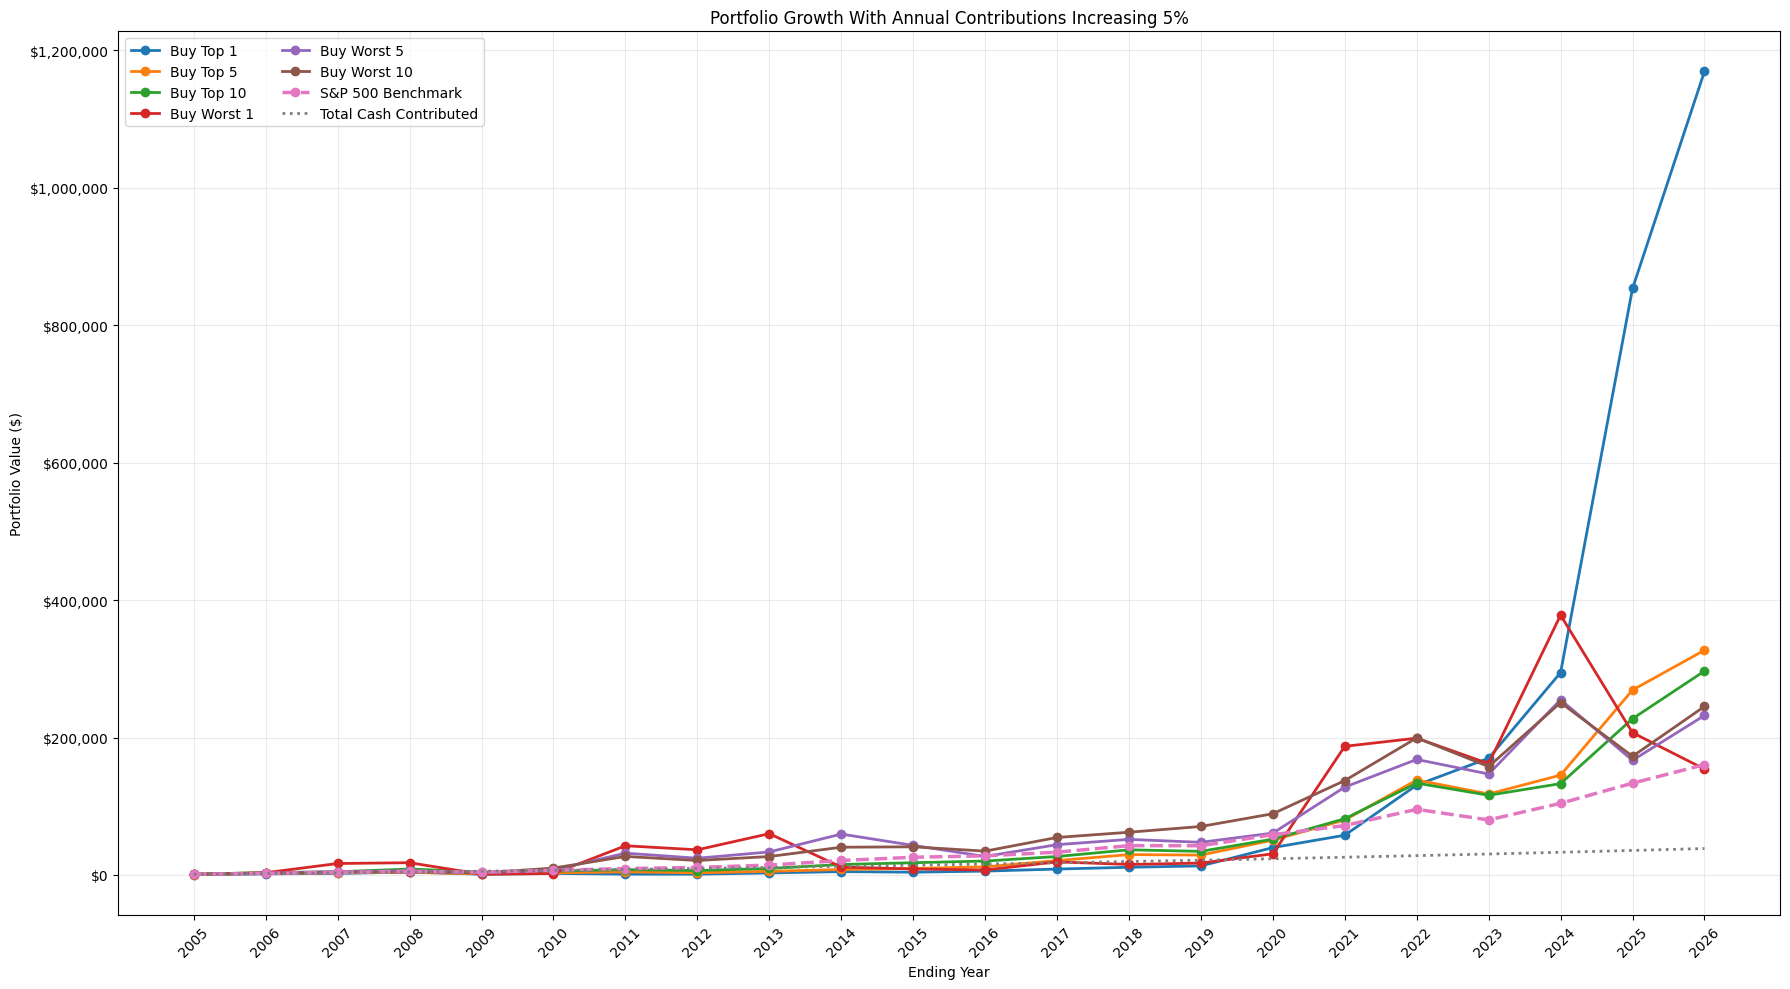


FINAL COMPARISON:
         Strategy  Total Contributions  Final Balance  Net Gain/Loss  Gain on Contributions (%)
        Buy Top 1             38505.21     1168954.41     1130449.20                    2935.83
        Buy Top 5             38505.21      326992.29      288487.08                     749.22
       Buy Top 10             38505.21      296737.35      258232.14                     670.64
     Buy Worst 10             38505.21      245213.23      206708.02                     536.83
      Buy Worst 5             38505.21      232081.22      193576.01                     502.73
S&P 500 Benchmark             38505.21      160521.68      122016.47                     316.88
      Buy Worst 1             38505.21      154142.41      115637.20                     300.32

CONTRIBUTION SUMMARY:
First annual contribution: $1,000.00
Annual increase: 5%
Total contributions: $38,505.21

FILES SAVED:
/content/growing_contributions_rollover_dollars.png
/content/growing_contributions_roll

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# 1. LOAD AND CLEAN PRICE DATA
# ============================================================

file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df = pd.read_csv(
    file_path,
    keep_default_na=False
)

df["Symbol"] = (
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2003, 2027))

for year in years:
    price_column = f"Price Jan {year}"

    df[price_column] = pd.to_numeric(
        df[price_column].replace({
            "N/A": pd.NA,
            "Not Found": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )


# ============================================================
# 2. STRATEGY SETTINGS
# ============================================================

first_contribution = 1000.00
annual_contribution_growth = 0.05

first_investment_year = 2004
last_investment_year = 2025


# ============================================================
# 3. STRATEGY FUNCTION
# ============================================================

def run_growing_contribution_strategy(
    data,
    number_of_stocks,
    select_best
):
    # No money exists before the first 2004 contribution
    ending_balance_from_prior_year = 0.0
    total_contributions = 0.0

    annual_results = []
    position_details = []

    for investment_year in range(
        first_investment_year,
        last_investment_year + 1
    ):
        ranking_start_column = (
            f"Price Jan {investment_year - 1}"
        )

        purchase_column = (
            f"Price Jan {investment_year}"
        )

        sale_column = (
            f"Price Jan {investment_year + 1}"
        )

        # Contribution sequence:
        # 2004 = $1,000
        # 2005 = $1,050
        # 2006 = $1,102.50
        contribution_number = (
            investment_year - first_investment_year
        )

        annual_contribution = (
            first_contribution
            * (1 + annual_contribution_growth)
            ** contribution_number
        )

        # Explicitly roll the old balance into this year
        rolled_balance = ending_balance_from_prior_year

        # Add the new annual contribution
        total_amount_invested = (
            rolled_balance + annual_contribution
        )

        total_contributions += annual_contribution

        # Require valid prices for:
        # 1. Previous-year ranking
        # 2. Current-year purchase
        # 3. Following-year sale
        eligible_stocks = data[
            data[ranking_start_column].notna()
            & data[purchase_column].notna()
            & data[sale_column].notna()
            & data[ranking_start_column].gt(0)
            & data[purchase_column].gt(0)
            & data[sale_column].gt(0)
        ].copy()

        if eligible_stocks.empty:
            ending_balance_from_prior_year = (
                total_amount_invested
            )

            annual_results.append({
                "Investment Period":
                    f"{investment_year}-{investment_year + 1}",
                "Selected Stocks": "None",
                "Rolled Balance": round(
                    rolled_balance,
                    2
                ),
                "Annual Contribution": round(
                    annual_contribution,
                    2
                ),
                "Total Amount Invested": round(
                    total_amount_invested,
                    2
                ),
                "Portfolio Return (%)": 0.00,
                "Ending Balance": round(
                    ending_balance_from_prior_year,
                    2
                ),
                "Total Contributions": round(
                    total_contributions,
                    2
                )
            })

            continue

        # Determine prior-year returns
        eligible_stocks["Prior Year Return (%)"] = (
            (
                eligible_stocks[purchase_column]
                - eligible_stocks[ranking_start_column]
            )
            / eligible_stocks[ranking_start_column]
            * 100
        )

        selected_stocks = (
            eligible_stocks
            .sort_values(
                "Prior Year Return (%)",
                ascending=not select_best
            )
            .head(number_of_stocks)
            .copy()
        )

        investment_per_stock = (
            total_amount_invested
            / len(selected_stocks)
        )

        new_ending_balance = 0.0

        for _, stock in selected_stocks.iterrows():
            symbol = stock["Symbol"]

            purchase_price = float(
                stock[purchase_column]
            )

            sale_price = float(
                stock[sale_column]
            )

            shares_purchased = (
                investment_per_stock / purchase_price
            )

            ending_value = (
                shares_purchased * sale_price
            )

            stock_return = (
                sale_price / purchase_price - 1
            ) * 100

            new_ending_balance += ending_value

            position_details.append({
                "Investment Period":
                    f"{investment_year}-{investment_year + 1}",
                "Symbol": symbol,
                "Prior Year Return (%)": round(
                    stock["Prior Year Return (%)"],
                    2
                ),
                "Purchase Price": round(
                    purchase_price,
                    2
                ),
                "Sale Price": round(
                    sale_price,
                    2
                ),
                "Amount Invested": round(
                    investment_per_stock,
                    2
                ),
                "Shares Purchased": round(
                    shares_purchased,
                    6
                ),
                "Investment Return (%)": round(
                    stock_return,
                    2
                ),
                "Ending Value": round(
                    ending_value,
                    2
                )
            })

        portfolio_return = (
            new_ending_balance
            / total_amount_invested
            - 1
        ) * 100

        annual_results.append({
            "Investment Period":
                f"{investment_year}-{investment_year + 1}",
            "Selected Stocks": ", ".join(
                selected_stocks["Symbol"].astype(str)
            ),
            "Rolled Balance": round(
                rolled_balance,
                2
            ),
            "Annual Contribution": round(
                annual_contribution,
                2
            ),
            "Total Amount Invested": round(
                total_amount_invested,
                2
            ),
            "Portfolio Return (%)": round(
                portfolio_return,
                2
            ),
            "Ending Balance": round(
                new_ending_balance,
                2
            ),
            "Total Contributions": round(
                total_contributions,
                2
            )
        })

        # This ending balance becomes next year's rolled balance
        ending_balance_from_prior_year = (
            new_ending_balance
        )

    return (
        pd.DataFrame(annual_results),
        pd.DataFrame(position_details),
        ending_balance_from_prior_year,
        total_contributions
    )


# ============================================================
# 4. RUN SIX STRATEGIES
# ============================================================

top_1_df, top_1_details_df, top_1_final, total_added = (
    run_growing_contribution_strategy(
        df,
        number_of_stocks=1,
        select_best=True
    )
)

top_5_df, top_5_details_df, top_5_final, _ = (
    run_growing_contribution_strategy(
        df,
        number_of_stocks=5,
        select_best=True
    )
)

top_10_df, top_10_details_df, top_10_final, _ = (
    run_growing_contribution_strategy(
        df,
        number_of_stocks=10,
        select_best=True
    )
)

worst_1_df, worst_1_details_df, worst_1_final, _ = (
    run_growing_contribution_strategy(
        df,
        number_of_stocks=1,
        select_best=False
    )
)

worst_5_df, worst_5_details_df, worst_5_final, _ = (
    run_growing_contribution_strategy(
        df,
        number_of_stocks=5,
        select_best=False
    )
)

worst_10_df, worst_10_details_df, worst_10_final, _ = (
    run_growing_contribution_strategy(
        df,
        number_of_stocks=10,
        select_best=False
    )
)


# ============================================================
# 5. S&P 500 BENCHMARK WITH THE SAME CONTRIBUTIONS
# ============================================================

sp500_annual_returns = {
    2004: 10.7,
    2005: 4.3,
    2006: 15.8,
    2007: 5.1,
    2008: -36.8,
    2009: 26.4,
    2010: 15.1,
    2011: 1.9,
    2012: 15.4,
    2013: 32.3,
    2014: 13.5,
    2015: 1.2,
    2016: 12.0,
    2017: 21.7,
    2018: -4.6,
    2019: 31.2,
    2020: 18.3,
    2021: 28.7,
    2022: -18.2,
    2023: 26.2,
    2024: 24.9,
    2025: 17.7
}

benchmark_rolled_balance = 0.0
benchmark_total_contributions = 0.0
benchmark_results = []

for investment_year in range(
    first_investment_year,
    last_investment_year + 1
):
    contribution_number = (
        investment_year - first_investment_year
    )

    annual_contribution = (
        first_contribution
        * (1 + annual_contribution_growth)
        ** contribution_number
    )

    total_amount_invested = (
        benchmark_rolled_balance
        + annual_contribution
    )

    benchmark_total_contributions += (
        annual_contribution
    )

    annual_return = (
        sp500_annual_returns[investment_year]
    )

    benchmark_ending_balance = (
        total_amount_invested
        * (1 + annual_return / 100)
    )

    benchmark_results.append({
        "Investment Period":
            f"{investment_year}-{investment_year + 1}",
        "Rolled Balance": round(
            benchmark_rolled_balance,
            2
        ),
        "Annual Contribution": round(
            annual_contribution,
            2
        ),
        "Total Amount Invested": round(
            total_amount_invested,
            2
        ),
        "S&P 500 Return (%)": annual_return,
        "Ending Balance": round(
            benchmark_ending_balance,
            2
        ),
        "Total Contributions": round(
            benchmark_total_contributions,
            2
        )
    })

    benchmark_rolled_balance = (
        benchmark_ending_balance
    )

benchmark_df = pd.DataFrame(
    benchmark_results
)

benchmark_final = benchmark_rolled_balance


# ============================================================
# 6. VALIDATE ROLLOVER CALCULATIONS
# ============================================================

def validate_rollover(strategy_df, strategy_name):
    validation_df = strategy_df.copy()

    validation_df["Expected Rolled Balance"] = (
        validation_df["Ending Balance"]
        .shift(1)
        .fillna(0.0)
    )

    validation_df["Rollover Difference"] = (
        validation_df["Rolled Balance"]
        - validation_df["Expected Rolled Balance"]
    ).round(2)

    maximum_difference = (
        validation_df["Rollover Difference"]
        .abs()
        .max()
    )

    print(
        f"{strategy_name} maximum rollover difference: "
        f"${maximum_difference:,.2f}"
    )


print("ROLLOVER VALIDATION:")
validate_rollover(top_1_df, "Top 1")
validate_rollover(top_5_df, "Top 5")
validate_rollover(top_10_df, "Top 10")
validate_rollover(worst_1_df, "Worst 1")
validate_rollover(worst_5_df, "Worst 5")
validate_rollover(worst_10_df, "Worst 10")
validate_rollover(benchmark_df, "S&P 500")


# ============================================================
# 7. PREPARE GRAPH DATA
# ============================================================

def prepare_graph_data(strategy_df):
    graph_df = strategy_df.copy()

    graph_df["Ending Year"] = (
        graph_df["Investment Period"]
        .str.split("-")
        .str[1]
        .astype(int)
    )

    return (
        graph_df["Ending Year"].tolist(),
        graph_df["Ending Balance"].tolist()
    )


top_1_years, top_1_balances = prepare_graph_data(
    top_1_df
)

top_5_years, top_5_balances = prepare_graph_data(
    top_5_df
)

top_10_years, top_10_balances = prepare_graph_data(
    top_10_df
)

worst_1_years, worst_1_balances = prepare_graph_data(
    worst_1_df
)

worst_5_years, worst_5_balances = prepare_graph_data(
    worst_5_df
)

worst_10_years, worst_10_balances = prepare_graph_data(
    worst_10_df
)

benchmark_years, benchmark_balances = (
    prepare_graph_data(benchmark_df)
)

# Cash contribution line
contribution_years = (
    benchmark_df["Investment Period"]
    .str.split("-")
    .str[1]
    .astype(int)
    .tolist()
)

cumulative_contributions = (
    benchmark_df["Total Contributions"]
    .tolist()
)


# ============================================================
# 8. PLOT IN DOLLARS
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 10)
)

ax.plot(
    top_1_years,
    top_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 1"
)

ax.plot(
    top_5_years,
    top_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 5"
)

ax.plot(
    top_10_years,
    top_10_balances,
    marker="o",
    linewidth=2,
    label="Buy Top 10"
)

ax.plot(
    worst_1_years,
    worst_1_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 1"
)

ax.plot(
    worst_5_years,
    worst_5_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 5"
)

ax.plot(
    worst_10_years,
    worst_10_balances,
    marker="o",
    linewidth=2,
    label="Buy Worst 10"
)

ax.plot(
    benchmark_years,
    benchmark_balances,
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="S&P 500 Benchmark"
)

ax.plot(
    contribution_years,
    cumulative_contributions,
    linewidth=2,
    linestyle=":",
    label="Total Cash Contributed"
)

ax.set_title(
    "Portfolio Growth With Annual Contributions Increasing 5%"
)

ax.set_xlabel("Ending Year")
ax.set_ylabel("Portfolio Value ($)")

ax.set_xticks(
    range(2005, 2027)
)

ax.tick_params(
    axis="x",
    rotation=45
)

# Format the y-axis explicitly as dollars
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"${value:,.0f}"
    )
)

ax.grid(alpha=0.25)

ax.legend(
    loc="upper left",
    ncol=2
)

plt.tight_layout()

graph_path = (
    "/content/"
    "growing_contributions_rollover_dollars.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. FINAL COMPARISON
# ============================================================

final_comparison_df = pd.DataFrame({
    "Strategy": [
        "Buy Top 1",
        "Buy Top 5",
        "Buy Top 10",
        "Buy Worst 1",
        "Buy Worst 5",
        "Buy Worst 10",
        "S&P 500 Benchmark"
    ],
    "Total Contributions": [
        round(total_added, 2)
    ] * 7,
    "Final Balance": [
        round(top_1_final, 2),
        round(top_5_final, 2),
        round(top_10_final, 2),
        round(worst_1_final, 2),
        round(worst_5_final, 2),
        round(worst_10_final, 2),
        round(benchmark_final, 2)
    ]
})

final_comparison_df["Net Gain/Loss"] = (
    final_comparison_df["Final Balance"]
    - final_comparison_df["Total Contributions"]
).round(2)

final_comparison_df[
    "Gain on Contributions (%)"
] = (
    (
        final_comparison_df["Final Balance"]
        / final_comparison_df["Total Contributions"]
    )
    - 1
) * 100

final_comparison_df[
    "Gain on Contributions (%)"
] = (
    final_comparison_df[
        "Gain on Contributions (%)"
    ].round(2)
)

final_comparison_df = (
    final_comparison_df
    .sort_values(
        "Final Balance",
        ascending=False
    )
    .reset_index(drop=True)
)

output_path = (
    "/content/"
    "growing_contributions_rollover_comparison.csv"
)

final_comparison_df.to_csv(
    output_path,
    index=False
)

print("\nFINAL COMPARISON:")
print(
    final_comparison_df.to_string(
        index=False
    )
)

print("\nCONTRIBUTION SUMMARY:")
print(
    f"First annual contribution: "
    f"${first_contribution:,.2f}"
)
print(
    f"Annual increase: "
    f"{annual_contribution_growth:.0%}"
)
print(
    f"Total contributions: "
    f"${total_added:,.2f}"
)

print("\nFILES SAVED:")
print(graph_path)
print(output_path)

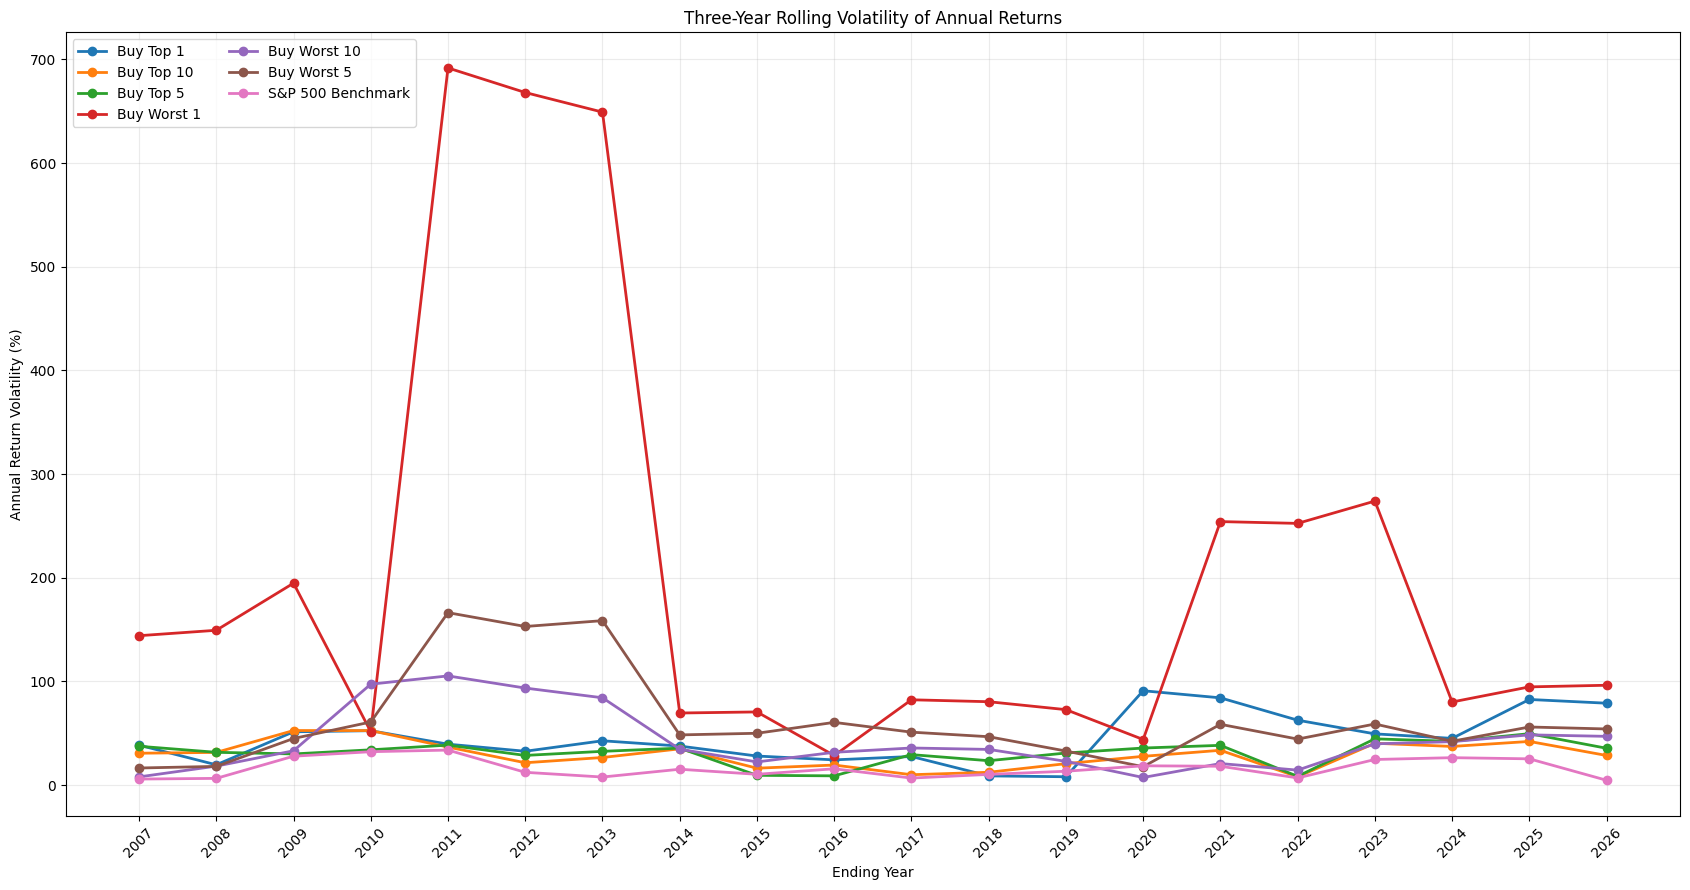

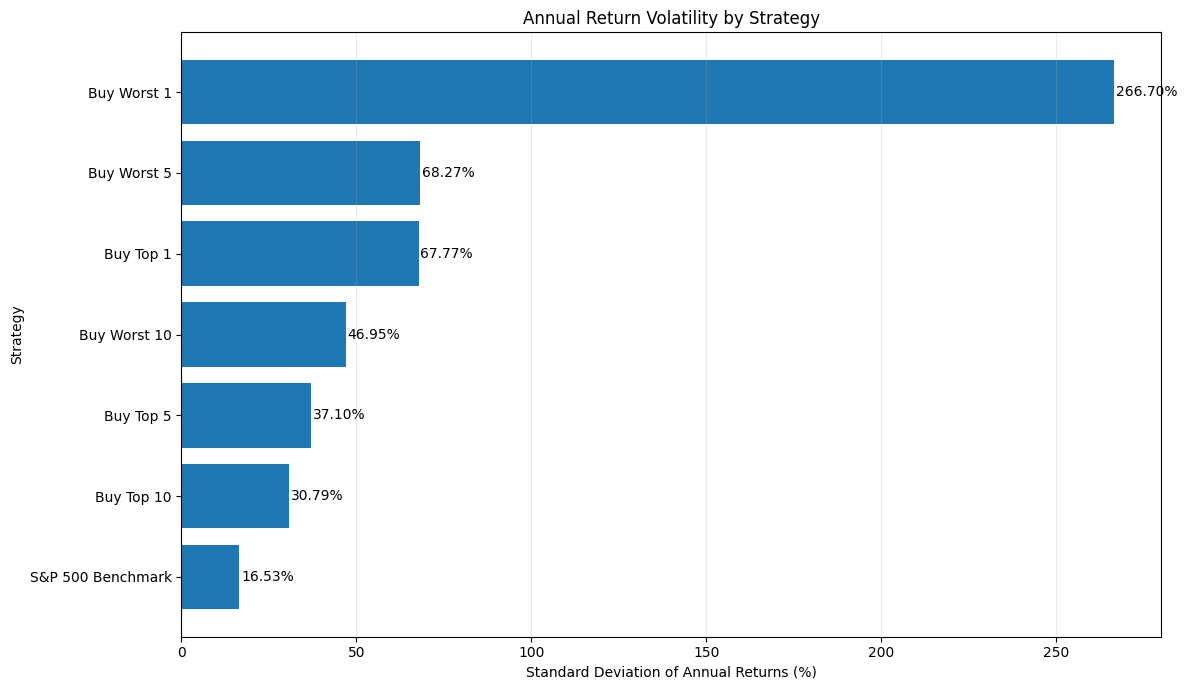

STRATEGY VOLATILITY SUMMARY:
         Strategy  Average Annual Return (%)  Annual Volatility (%)  Downside Volatility (%)  Best Year Return (%)  Worst Year Return (%)  Positive Years  Negative Years
      Buy Worst 1                      87.73                 266.70                    27.75               1142.99                 -94.35              10              10
      Buy Worst 5                      27.72                  68.27                    17.79                271.83                 -57.01              14               8
        Buy Top 1                      18.01                  67.77                    29.85                187.13                 -78.72              13               8
     Buy Worst 10                      22.05                  46.95                    13.58                137.16                 -46.05              15               7
        Buy Top 5                      12.81                  37.10                    21.57                 81.90       

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. COLLECT ANNUAL RETURNS FOR EACH STRATEGY
# ============================================================

strategy_data = {
    "Buy Top 1": top_1_df,
    "Buy Top 5": top_5_df,
    "Buy Top 10": top_10_df,
    "Buy Worst 1": worst_1_df,
    "Buy Worst 5": worst_5_df,
    "Buy Worst 10": worst_10_df
}

annual_returns_list = []

for strategy_name, strategy_df in strategy_data.items():
    strategy_returns = strategy_df[
        [
            "Investment Period",
            "Portfolio Return (%)"
        ]
    ].copy()

    strategy_returns["Strategy"] = strategy_name

    strategy_returns["Ending Year"] = (
        strategy_returns["Investment Period"]
        .str.split("-")
        .str[1]
        .astype(int)
    )

    annual_returns_list.append(strategy_returns)

# Add S&P 500 benchmark returns
benchmark_returns = benchmark_df[
    [
        "Investment Period",
        "S&P 500 Return (%)"
    ]
].copy()

benchmark_returns = benchmark_returns.rename(
    columns={
        "S&P 500 Return (%)": "Portfolio Return (%)"
    }
)

benchmark_returns["Strategy"] = "S&P 500 Benchmark"

benchmark_returns["Ending Year"] = (
    benchmark_returns["Investment Period"]
    .str.split("-")
    .str[1]
    .astype(int)
)

annual_returns_list.append(benchmark_returns)

# Combine all annual returns
all_annual_returns_df = pd.concat(
    annual_returns_list,
    ignore_index=True
)

all_annual_returns_df["Portfolio Return (%)"] = (
    pd.to_numeric(
        all_annual_returns_df["Portfolio Return (%)"],
        errors="coerce"
    )
)


# ============================================================
# 2. CALCULATE OVERALL VOLATILITY STATISTICS
# ============================================================

volatility_rows = []

for strategy_name, group in all_annual_returns_df.groupby(
    "Strategy"
):
    returns = group[
        "Portfolio Return (%)"
    ].dropna()

    negative_returns = returns[
        returns < 0
    ]

    volatility_rows.append({
        "Strategy": strategy_name,
        "Average Annual Return (%)": round(
            returns.mean(),
            2
        ),
        "Annual Volatility (%)": round(
            returns.std(ddof=1),
            2
        ),
        "Downside Volatility (%)": round(
            negative_returns.std(ddof=1),
            2
        ) if len(negative_returns) > 1 else 0.00,
        "Best Year Return (%)": round(
            returns.max(),
            2
        ),
        "Worst Year Return (%)": round(
            returns.min(),
            2
        ),
        "Positive Years": int(
            (returns > 0).sum()
        ),
        "Negative Years": int(
            (returns < 0).sum()
        )
    })

volatility_summary_df = pd.DataFrame(
    volatility_rows
)

volatility_summary_df = (
    volatility_summary_df
    .sort_values(
        "Annual Volatility (%)",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 3. CALCULATE 3-YEAR ROLLING VOLATILITY
# ============================================================

rolling_volatility_list = []

for strategy_name, group in all_annual_returns_df.groupby(
    "Strategy"
):
    group = group.sort_values(
        "Ending Year"
    ).copy()

    group["3-Year Rolling Volatility (%)"] = (
        group["Portfolio Return (%)"]
        .rolling(
            window=3,
            min_periods=3
        )
        .std(ddof=1)
    )

    rolling_volatility_list.append(
        group[
            [
                "Strategy",
                "Ending Year",
                "3-Year Rolling Volatility (%)"
            ]
        ]
    )

rolling_volatility_df = pd.concat(
    rolling_volatility_list,
    ignore_index=True
)


# ============================================================
# 4. PLOT 3-YEAR ROLLING VOLATILITY
# ============================================================

plt.figure(figsize=(17, 9))

for strategy_name in rolling_volatility_df[
    "Strategy"
].unique():
    strategy_plot = rolling_volatility_df[
        rolling_volatility_df["Strategy"]
        == strategy_name
    ]

    plt.plot(
        strategy_plot["Ending Year"],
        strategy_plot[
            "3-Year Rolling Volatility (%)"
        ],
        marker="o",
        linewidth=2,
        label=strategy_name
    )

plt.title(
    "Three-Year Rolling Volatility of Annual Returns"
)

plt.xlabel("Ending Year")
plt.ylabel("Annual Return Volatility (%)")

plt.xticks(
    range(2007, 2027),
    rotation=45
)

plt.grid(alpha=0.25)

plt.legend(
    loc="upper left",
    ncol=2
)

plt.tight_layout()

rolling_graph_path = (
    "/content/"
    "three_year_rolling_volatility.png"
)

plt.savefig(
    rolling_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. PLOT OVERALL VOLATILITY COMPARISON
# ============================================================

volatility_chart_df = (
    volatility_summary_df
    .sort_values(
        "Annual Volatility (%)",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    volatility_chart_df["Strategy"],
    volatility_chart_df[
        "Annual Volatility (%)"
    ]
)

plt.title(
    "Annual Return Volatility by Strategy"
)

plt.xlabel(
    "Standard Deviation of Annual Returns (%)"
)

plt.ylabel("Strategy")

for bar, value in zip(
    bars,
    volatility_chart_df[
        "Annual Volatility (%)"
    ]
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

summary_graph_path = (
    "/content/"
    "strategy_annual_volatility_comparison.png"
)

plt.savefig(
    summary_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. SAVE RESULTS
# ============================================================

volatility_summary_path = (
    "/content/"
    "strategy_volatility_summary.csv"
)

rolling_volatility_path = (
    "/content/"
    "strategy_rolling_volatility.csv"
)

annual_returns_path = (
    "/content/"
    "strategy_annual_returns.csv"
)

volatility_summary_df.to_csv(
    volatility_summary_path,
    index=False
)

rolling_volatility_df.to_csv(
    rolling_volatility_path,
    index=False
)

all_annual_returns_df.to_csv(
    annual_returns_path,
    index=False
)


# ============================================================
# 7. DISPLAY SUMMARY
# ============================================================

print("STRATEGY VOLATILITY SUMMARY:")

print(
    volatility_summary_df.to_string(
        index=False
    )
)

print("\nFILES SAVED:")
print(rolling_graph_path)
print(summary_graph_path)
print(volatility_summary_path)
print(rolling_volatility_path)
print(annual_returns_path)

In [ ]:
import pandas as pd

# Define the six strategy result DataFrames
strategy_results = {
    "Buy Top 1": top_1_df,
    "Buy Top 5": top_5_df,
    "Buy Top 10": top_10_df,
    "Buy Worst 1": worst_1_df,
    "Buy Worst 5": worst_5_df,
    "Buy Worst 10": worst_10_df
}

best_worst_rows = []

for strategy_name, strategy_df in strategy_results.items():
    strategy_df = strategy_df.copy()

    # Ensure returns are numeric
    strategy_df["Portfolio Return (%)"] = pd.to_numeric(
        strategy_df["Portfolio Return (%)"],
        errors="coerce"
    )

    # Remove rows without a valid return
    valid_results = strategy_df.dropna(
        subset=["Portfolio Return (%)"]
    )

    if valid_results.empty:
        continue

    # Find the best and worst years
    best_row = valid_results.loc[
        valid_results["Portfolio Return (%)"].idxmax()
    ]

    worst_row = valid_results.loc[
        valid_results["Portfolio Return (%)"].idxmin()
    ]

    best_worst_rows.append({
        "Strategy": strategy_name,
        "Best Investment Period": best_row["Investment Period"],
        "Best Year Return (%)": round(
            best_row["Portfolio Return (%)"],
            2
        ),
        "Best Year Selected Stocks": best_row["Selected Stocks"],
        "Best Year Ending Balance": round(
            best_row["Ending Balance"],
            2
        ),
        "Worst Investment Period": worst_row["Investment Period"],
        "Worst Year Return (%)": round(
            worst_row["Portfolio Return (%)"],
            2
        ),
        "Worst Year Selected Stocks": worst_row["Selected Stocks"],
        "Worst Year Ending Balance": round(
            worst_row["Ending Balance"],
            2
        )
    })

# Create the summary table
best_worst_summary_df = pd.DataFrame(
    best_worst_rows
)

# Sort by best annual return
best_worst_summary_df = (
    best_worst_summary_df
    .sort_values(
        "Best Year Return (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

# Save the results
output_path = (
    "/content/"
    "six_strategies_best_worst_years.csv"
)

best_worst_summary_df.to_csv(
    output_path,
    index=False
)

print("BEST AND WORST YEAR BY STRATEGY:")
print(
    best_worst_summary_df.to_string(
        index=False
    )
)

print(f"\nSaved to: {output_path}")

BEST AND WORST YEAR BY STRATEGY:
    Strategy Best Investment Period  Best Year Return (%)                             Best Year Selected Stocks  Best Year Ending Balance Worst Investment Period  Worst Year Return (%)                        Worst Year Selected Stocks  Worst Year Ending Balance
 Buy Worst 1              2010-2011               1142.99                                                   PGN                  42535.49               2008-2009                 -94.35                                                XL                    1078.36
 Buy Worst 5              2010-2011                271.83                                PGN, HBAN, C, ZION, XL                  31805.89               2008-2009                 -57.01                           XL, CPWR, MBI, PHM, LEN                    3110.45
   Buy Top 1              2024-2025                187.13                                                  NVDA                 853333.10               2008-2009                 -78

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# 1. STRATEGY DATAFRAMES
# ============================================================

strategy_data = {
    "Buy Top 1": top_1_df,
    "Buy Top 5": top_5_df,
    "Buy Top 10": top_10_df,
    "Buy Worst 1": worst_1_df,
    "Buy Worst 5": worst_5_df,
    "Buy Worst 10": worst_10_df
}

# Prepare benchmark in the same format as the strategies
benchmark_scorecard_df = benchmark_df.copy()

benchmark_scorecard_df = benchmark_scorecard_df.rename(
    columns={
        "S&P 500 Return (%)": "Portfolio Return (%)"
    }
)

strategy_data["S&P 500 Benchmark"] = (
    benchmark_scorecard_df
)


# ============================================================
# 2. MAXIMUM DRAWDOWN FUNCTION
# ============================================================

def calculate_max_drawdown(balance_series):
    balance_series = pd.to_numeric(
        balance_series,
        errors="coerce"
    ).dropna()

    if balance_series.empty:
        return np.nan

    running_peak = balance_series.cummax()

    drawdown = (
        balance_series / running_peak - 1
    ) * 100

    return drawdown.min()


# ============================================================
# 3. BUILD SCORECARD
# ============================================================

scorecard_rows = []

benchmark_returns = pd.to_numeric(
    benchmark_scorecard_df["Portfolio Return (%)"],
    errors="coerce"
).reset_index(drop=True)

for strategy_name, strategy_df in strategy_data.items():
    strategy_df = strategy_df.copy()

    returns = pd.to_numeric(
        strategy_df["Portfolio Return (%)"],
        errors="coerce"
    ).dropna().reset_index(drop=True)

    balances = pd.to_numeric(
        strategy_df["Ending Balance"],
        errors="coerce"
    ).dropna()

    total_contributions = pd.to_numeric(
        strategy_df["Total Contributions"],
        errors="coerce"
    ).dropna()

    final_balance = (
        balances.iloc[-1]
        if not balances.empty
        else np.nan
    )

    final_contributions = (
        total_contributions.iloc[-1]
        if not total_contributions.empty
        else np.nan
    )

    net_gain = (
        final_balance - final_contributions
    )

    gain_on_contributions = (
        (
            final_balance / final_contributions
        ) - 1
    ) * 100

    # Match strategy returns against benchmark by period
    period_comparison = strategy_df[
        [
            "Investment Period",
            "Portfolio Return (%)"
        ]
    ].copy()

    period_comparison[
        "Portfolio Return (%)"
    ] = pd.to_numeric(
        period_comparison["Portfolio Return (%)"],
        errors="coerce"
    )

    benchmark_period_returns = (
        benchmark_scorecard_df[
            [
                "Investment Period",
                "Portfolio Return (%)"
            ]
        ]
        .rename(
            columns={
                "Portfolio Return (%)":
                    "Benchmark Return (%)"
            }
        )
    )

    period_comparison = period_comparison.merge(
        benchmark_period_returns,
        on="Investment Period",
        how="inner"
    )

    years_beating_benchmark = (
        period_comparison["Portfolio Return (%)"]
        > period_comparison["Benchmark Return (%)"]
    ).sum()

    years_below_benchmark = (
        period_comparison["Portfolio Return (%)"]
        < period_comparison["Benchmark Return (%)"]
    ).sum()

    years_equal_benchmark = (
        period_comparison["Portfolio Return (%)"]
        == period_comparison["Benchmark Return (%)"]
    ).sum()

    # Find best and worst periods
    best_index = returns.idxmax()
    worst_index = returns.idxmin()

    best_period = strategy_df.loc[
        best_index,
        "Investment Period"
    ]

    worst_period = strategy_df.loc[
        worst_index,
        "Investment Period"
    ]

    scorecard_rows.append({
        "Strategy": strategy_name,
        "Total Contributions": round(
            final_contributions,
            2
        ),
        "Final Balance": round(
            final_balance,
            2
        ),
        "Net Gain/Loss": round(
            net_gain,
            2
        ),
        "Gain on Contributions (%)": round(
            gain_on_contributions,
            2
        ),
        "Average Annual Return (%)": round(
            returns.mean(),
            2
        ),
        "Median Annual Return (%)": round(
            returns.median(),
            2
        ),
        "Annual Volatility (%)": round(
            returns.std(ddof=1),
            2
        ),
        "Best Year Return (%)": round(
            returns.max(),
            2
        ),
        "Best Investment Period": best_period,
        "Worst Year Return (%)": round(
            returns.min(),
            2
        ),
        "Worst Investment Period": worst_period,
        "Maximum Drawdown (%)": round(
            calculate_max_drawdown(balances),
            2
        ),
        "Positive Years": int(
            (returns > 0).sum()
        ),
        "Negative Years": int(
            (returns < 0).sum()
        ),
        "Flat Years": int(
            (returns == 0).sum()
        ),
        "Years Beating S&P 500": int(
            years_beating_benchmark
        ),
        "Years Below S&P 500": int(
            years_below_benchmark
        ),
        "Years Equal to S&P 500": int(
            years_equal_benchmark
        )
    })


# ============================================================
# 4. CREATE FINAL SCORECARD
# ============================================================

strategy_scorecard_df = pd.DataFrame(
    scorecard_rows
)

strategy_scorecard_df = (
    strategy_scorecard_df
    .sort_values(
        "Final Balance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. ADD RANKINGS
# ============================================================

strategy_scorecard_df[
    "Final Balance Rank"
] = (
    strategy_scorecard_df["Final Balance"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

strategy_scorecard_df[
    "Average Return Rank"
] = (
    strategy_scorecard_df[
        "Average Annual Return (%)"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

strategy_scorecard_df[
    "Lowest Volatility Rank"
] = (
    strategy_scorecard_df[
        "Annual Volatility (%)"
    ]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

strategy_scorecard_df[
    "Lowest Drawdown Rank"
] = (
    strategy_scorecard_df[
        "Maximum Drawdown (%)"
    ]
    .abs()
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)


# ============================================================
# 6. ARRANGE COLUMNS
# ============================================================

strategy_scorecard_df = strategy_scorecard_df[
    [
        "Strategy",
        "Total Contributions",
        "Final Balance",
        "Net Gain/Loss",
        "Gain on Contributions (%)",
        "Average Annual Return (%)",
        "Median Annual Return (%)",
        "Annual Volatility (%)",
        "Maximum Drawdown (%)",
        "Best Year Return (%)",
        "Best Investment Period",
        "Worst Year Return (%)",
        "Worst Investment Period",
        "Positive Years",
        "Negative Years",
        "Flat Years",
        "Years Beating S&P 500",
        "Years Below S&P 500",
        "Years Equal to S&P 500",
        "Final Balance Rank",
        "Average Return Rank",
        "Lowest Volatility Rank",
        "Lowest Drawdown Rank"
    ]
]


# ============================================================
# 7. SAVE SCORECARD
# ============================================================

output_path = (
    "/content/final_strategy_scorecard.csv"
)

strategy_scorecard_df.to_csv(
    output_path,
    index=False
)


# ============================================================
# 8. DISPLAY SCORECARD
# ============================================================

print("FINAL STRATEGY SCORECARD:")

print(
    strategy_scorecard_df.to_string(
        index=False
    )
)

print(f"\nSaved to: {output_path}")

FINAL STRATEGY SCORECARD:
         Strategy  Total Contributions  Final Balance  Net Gain/Loss  Gain on Contributions (%)  Average Annual Return (%)  Median Annual Return (%)  Annual Volatility (%)  Maximum Drawdown (%)  Best Year Return (%) Best Investment Period  Worst Year Return (%) Worst Investment Period  Positive Years  Negative Years  Flat Years  Years Beating S&P 500  Years Below S&P 500  Years Equal to S&P 500  Final Balance Rank  Average Return Rank  Lowest Volatility Rank  Lowest Drawdown Rank
        Buy Top 1             38505.21     1168954.41     1130449.20                    2935.83                      18.01                     10.23                  67.77                -72.70                187.13              2024-2025                 -78.72               2008-2009              13               8           1                     11                   11                       0                   1                    5                       5                     6
    

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# 1. LOAD AND CLEAN PRICE DATA
# ============================================================

file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

price_df = pd.read_csv(
    file_path,
    keep_default_na=False
)

price_df["Symbol"] = (
    price_df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2003, 2027))

for year in years:
    column = f"Price Jan {year}"

    price_df[column] = pd.to_numeric(
        price_df[column].replace({
            "N/A": pd.NA,
            "Not Found": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )


# ============================================================
# 2. S&P 500 BENCHMARK RETURNS
# ============================================================

sp500_annual_returns = {
    2004: 10.7,
    2005: 4.3,
    2006: 15.8,
    2007: 5.1,
    2008: -36.8,
    2009: 26.4,
    2010: 15.1,
    2011: 1.9,
    2012: 15.4,
    2013: 32.3,
    2014: 13.5,
    2015: 1.2,
    2016: 12.0,
    2017: 21.7,
    2018: -4.6,
    2019: 31.2,
    2020: 18.3,
    2021: 28.7,
    2022: -18.2,
    2023: 26.2,
    2024: 24.9,
    2025: 17.7
}

first_investment_year = 2004
last_investment_year = 2025


# ============================================================
# 3. GENERIC STRATEGY FUNCTION
# ============================================================

def run_ranked_strategy(
    data,
    number_of_stocks,
    select_best,
    contribution_function
):
    current_balance = 0.0
    total_contributions = 0.0

    annual_results = []
    stock_details = []

    for investment_year in range(
        first_investment_year,
        last_investment_year + 1
    ):
        prior_column = f"Price Jan {investment_year - 1}"
        purchase_column = f"Price Jan {investment_year}"
        sale_column = f"Price Jan {investment_year + 1}"

        rolled_balance = current_balance

        annual_contribution = float(
            contribution_function(investment_year)
        )

        total_contributions += annual_contribution

        amount_invested = (
            rolled_balance + annual_contribution
        )

        eligible_stocks = data[
            data[prior_column].notna()
            & data[purchase_column].notna()
            & data[sale_column].notna()
            & data[prior_column].gt(0)
            & data[purchase_column].gt(0)
            & data[sale_column].gt(0)
        ].copy()

        if eligible_stocks.empty:
            current_balance = amount_invested

            annual_results.append({
                "Investment Period":
                    f"{investment_year}-{investment_year + 1}",
                "Selected Stocks": "None",
                "Rolled Balance": round(rolled_balance, 2),
                "Annual Contribution": round(
                    annual_contribution,
                    2
                ),
                "Total Contributions": round(
                    total_contributions,
                    2
                ),
                "Amount Invested": round(
                    amount_invested,
                    2
                ),
                "Portfolio Return (%)": 0.00,
                "Ending Balance": round(
                    current_balance,
                    2
                )
            })

            continue

        eligible_stocks["Prior Year Return (%)"] = (
            (
                eligible_stocks[purchase_column]
                - eligible_stocks[prior_column]
            )
            / eligible_stocks[prior_column]
            * 100
        )

        selected_stocks = (
            eligible_stocks
            .sort_values(
                "Prior Year Return (%)",
                ascending=not select_best
            )
            .head(number_of_stocks)
            .copy()
        )

        investment_per_stock = (
            amount_invested / len(selected_stocks)
        )

        ending_balance = 0.0

        for _, stock in selected_stocks.iterrows():
            purchase_price = float(
                stock[purchase_column]
            )

            sale_price = float(
                stock[sale_column]
            )

            shares = (
                investment_per_stock / purchase_price
            )

            ending_value = (
                shares * sale_price
            )

            investment_return = (
                sale_price / purchase_price - 1
            ) * 100

            ending_balance += ending_value

            stock_details.append({
                "Investment Period":
                    f"{investment_year}-{investment_year + 1}",
                "Symbol": stock["Symbol"],
                "Prior Year Return (%)": round(
                    stock["Prior Year Return (%)"],
                    2
                ),
                "Purchase Price": round(
                    purchase_price,
                    2
                ),
                "Sale Price": round(
                    sale_price,
                    2
                ),
                "Amount Invested": round(
                    investment_per_stock,
                    2
                ),
                "Investment Return (%)": round(
                    investment_return,
                    2
                ),
                "Ending Value": round(
                    ending_value,
                    2
                )
            })

        portfolio_return = (
            ending_balance / amount_invested - 1
        ) * 100

        current_balance = ending_balance

        annual_results.append({
            "Investment Period":
                f"{investment_year}-{investment_year + 1}",
            "Selected Stocks": ", ".join(
                selected_stocks["Symbol"].astype(str)
            ),
            "Rolled Balance": round(rolled_balance, 2),
            "Annual Contribution": round(
                annual_contribution,
                2
            ),
            "Total Contributions": round(
                total_contributions,
                2
            ),
            "Amount Invested": round(
                amount_invested,
                2
            ),
            "Portfolio Return (%)": round(
                portfolio_return,
                2
            ),
            "Ending Balance": round(
                current_balance,
                2
            )
        })

    return (
        pd.DataFrame(annual_results),
        pd.DataFrame(stock_details)
    )


# ============================================================
# 4. CONTRIBUTION FUNCTIONS
# ============================================================

def initial_1000_only(year):
    """
    Invest $1,000 in 2004 and contribute nothing afterward.
    """
    if year == first_investment_year:
        return 1000.00

    return 0.00


def growing_annual_contributions(year):
    """
    Begin with $1,000 in 2004 and increase the contribution
    by 5% each subsequent year.
    """
    contribution_number = (
        year - first_investment_year
    )

    return (
        1000.00
        * (1.05 ** contribution_number)
    )


# ============================================================
# 5. RUN ALL SIX STRATEGIES FOR ONE SCENARIO
# ============================================================

strategy_definitions = {
    "Buy Top 1": {
        "number_of_stocks": 1,
        "select_best": True
    },
    "Buy Top 5": {
        "number_of_stocks": 5,
        "select_best": True
    },
    "Buy Top 10": {
        "number_of_stocks": 10,
        "select_best": True
    },
    "Buy Worst 1": {
        "number_of_stocks": 1,
        "select_best": False
    },
    "Buy Worst 5": {
        "number_of_stocks": 5,
        "select_best": False
    },
    "Buy Worst 10": {
        "number_of_stocks": 10,
        "select_best": False
    }
}


def run_scenario(contribution_function):
    scenario_results = {}
    scenario_details = {}

    for strategy_name, settings in strategy_definitions.items():
        results_df, details_df = run_ranked_strategy(
            data=price_df,
            number_of_stocks=settings["number_of_stocks"],
            select_best=settings["select_best"],
            contribution_function=contribution_function
        )

        scenario_results[strategy_name] = results_df
        scenario_details[strategy_name] = details_df

    return scenario_results, scenario_details


no_contribution_results, no_contribution_details = (
    run_scenario(initial_1000_only)
)

growing_contribution_results, growing_contribution_details = (
    run_scenario(growing_annual_contributions)
)


# ============================================================
# 6. RUN BENCHMARK FOR EACH SCENARIO
# ============================================================

def run_benchmark(contribution_function):
    current_balance = 0.0
    total_contributions = 0.0
    benchmark_rows = []

    for investment_year in range(
        first_investment_year,
        last_investment_year + 1
    ):
        rolled_balance = current_balance

        annual_contribution = float(
            contribution_function(investment_year)
        )

        total_contributions += annual_contribution

        amount_invested = (
            rolled_balance + annual_contribution
        )

        annual_return = (
            sp500_annual_returns[investment_year]
        )

        current_balance = (
            amount_invested
            * (1 + annual_return / 100)
        )

        benchmark_rows.append({
            "Investment Period":
                f"{investment_year}-{investment_year + 1}",
            "Selected Stocks": "S&P 500",
            "Rolled Balance": round(
                rolled_balance,
                2
            ),
            "Annual Contribution": round(
                annual_contribution,
                2
            ),
            "Total Contributions": round(
                total_contributions,
                2
            ),
            "Amount Invested": round(
                amount_invested,
                2
            ),
            "Portfolio Return (%)": annual_return,
            "Ending Balance": round(
                current_balance,
                2
            )
        })

    return pd.DataFrame(benchmark_rows)


no_contribution_results[
    "S&P 500 Benchmark"
] = run_benchmark(initial_1000_only)

growing_contribution_results[
    "S&P 500 Benchmark"
] = run_benchmark(growing_annual_contributions)


# ============================================================
# 7. MAXIMUM DRAWDOWN FROM ANNUAL RETURNS
# ============================================================

def calculate_return_drawdown(returns):
    returns = pd.to_numeric(
        returns,
        errors="coerce"
    ).dropna()

    if returns.empty:
        return np.nan

    growth_index = (
        1 + returns / 100
    ).cumprod()

    running_peak = growth_index.cummax()

    drawdown = (
        growth_index / running_peak - 1
    ) * 100

    return drawdown.min()


# ============================================================
# 8. BUILD SCORECARD
# ============================================================

def build_scorecard(
    scenario_name,
    scenario_results
):
    benchmark_df = scenario_results[
        "S&P 500 Benchmark"
    ]

    benchmark_period_returns = (
        benchmark_df[
            [
                "Investment Period",
                "Portfolio Return (%)"
            ]
        ]
        .rename(
            columns={
                "Portfolio Return (%)":
                    "Benchmark Return (%)"
            }
        )
    )

    scorecard_rows = []

    for strategy_name, results_df in scenario_results.items():
        results_df = results_df.copy()

        results_df["Portfolio Return (%)"] = (
            pd.to_numeric(
                results_df["Portfolio Return (%)"],
                errors="coerce"
            )
        )

        results_df["Ending Balance"] = (
            pd.to_numeric(
                results_df["Ending Balance"],
                errors="coerce"
            )
        )

        results_df["Total Contributions"] = (
            pd.to_numeric(
                results_df["Total Contributions"],
                errors="coerce"
            )
        )

        returns = (
            results_df["Portfolio Return (%)"]
            .dropna()
        )

        final_balance = (
            results_df["Ending Balance"].iloc[-1]
        )

        total_contributions = (
            results_df["Total Contributions"].iloc[-1]
        )

        net_gain = (
            final_balance - total_contributions
        )

        gain_on_contributions = (
            final_balance / total_contributions - 1
        ) * 100

        comparison_df = results_df[
            [
                "Investment Period",
                "Portfolio Return (%)"
            ]
        ].merge(
            benchmark_period_returns,
            on="Investment Period",
            how="inner"
        )

        years_beating_benchmark = (
            comparison_df["Portfolio Return (%)"]
            > comparison_df["Benchmark Return (%)"]
        ).sum()

        best_index = (
            results_df["Portfolio Return (%)"]
            .idxmax()
        )

        worst_index = (
            results_df["Portfolio Return (%)"]
            .idxmin()
        )

        scorecard_rows.append({
            "Scenario": scenario_name,
            "Strategy": strategy_name,
            "Total Contributions": round(
                total_contributions,
                2
            ),
            "Final Balance": round(
                final_balance,
                2
            ),
            "Net Gain/Loss": round(
                net_gain,
                2
            ),
            "Gain on Contributions (%)": round(
                gain_on_contributions,
                2
            ),
            "Average Annual Return (%)": round(
                returns.mean(),
                2
            ),
            "Median Annual Return (%)": round(
                returns.median(),
                2
            ),
            "Annual Volatility (%)": round(
                returns.std(ddof=1),
                2
            ),
            "Maximum Drawdown (%)": round(
                calculate_return_drawdown(returns),
                2
            ),
            "Best Year Return (%)": round(
                returns.max(),
                2
            ),
            "Best Investment Period": (
                results_df.loc[
                    best_index,
                    "Investment Period"
                ]
            ),
            "Worst Year Return (%)": round(
                returns.min(),
                2
            ),
            "Worst Investment Period": (
                results_df.loc[
                    worst_index,
                    "Investment Period"
                ]
            ),
            "Positive Years": int(
                (returns > 0).sum()
            ),
            "Negative Years": int(
                (returns < 0).sum()
            ),
            "Flat Years": int(
                (returns == 0).sum()
            ),
            "Years Beating S&P 500": int(
                years_beating_benchmark
            )
        })

    scorecard_df = pd.DataFrame(
        scorecard_rows
    )

    scorecard_df["Final Balance Rank"] = (
        scorecard_df["Final Balance"]
        .rank(
            method="min",
            ascending=False
        )
        .astype(int)
    )

    scorecard_df["Lowest Volatility Rank"] = (
        scorecard_df["Annual Volatility (%)"]
        .rank(
            method="min",
            ascending=True
        )
        .astype(int)
    )

    return (
        scorecard_df
        .sort_values(
            "Final Balance",
            ascending=False
        )
        .reset_index(drop=True)
    )


no_contribution_scorecard_df = build_scorecard(
    scenario_name="Initial $1,000 Only",
    scenario_results=no_contribution_results
)

growing_contribution_scorecard_df = build_scorecard(
    scenario_name="$1,000 Annual Contribution, Growing 5%",
    scenario_results=growing_contribution_results
)


# ============================================================
# 9. COMBINE BOTH SCORECARDS
# ============================================================

combined_scorecard_df = pd.concat(
    [
        no_contribution_scorecard_df,
        growing_contribution_scorecard_df
    ],
    ignore_index=True
)


# ============================================================
# 10. CREATE DIRECT FINAL-BALANCE COMPARISON
# ============================================================

direct_comparison_df = (
    combined_scorecard_df.pivot(
        index="Strategy",
        columns="Scenario",
        values="Final Balance"
    )
    .reset_index()
)

direct_comparison_df["Difference"] = (
    direct_comparison_df[
        "$1,000 Annual Contribution, Growing 5%"
    ]
    - direct_comparison_df[
        "Initial $1,000 Only"
    ]
).round(2)

direct_comparison_df = (
    direct_comparison_df
    .sort_values(
        "$1,000 Annual Contribution, Growing 5%",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 11. SAVE OUTPUTS
# ============================================================

no_contribution_path = (
    "/content/"
    "strategy_scorecard_initial_1000_only.csv"
)

growing_contribution_path = (
    "/content/"
    "strategy_scorecard_growing_contributions.csv"
)

combined_path = (
    "/content/"
    "strategy_scorecard_both_scenarios.csv"
)

direct_comparison_path = (
    "/content/"
    "strategy_final_balance_scenario_comparison.csv"
)

no_contribution_scorecard_df.to_csv(
    no_contribution_path,
    index=False
)

growing_contribution_scorecard_df.to_csv(
    growing_contribution_path,
    index=False
)

combined_scorecard_df.to_csv(
    combined_path,
    index=False
)

direct_comparison_df.to_csv(
    direct_comparison_path,
    index=False
)


# ============================================================
# 12. DISPLAY RESULTS
# ============================================================

print("SCORECARD: INITIAL $1,000 ONLY")
print(
    no_contribution_scorecard_df.to_string(
        index=False
    )
)

print(
    "\nSCORECARD: $1,000 ANNUAL CONTRIBUTION "
    "INCREASING 5% EACH YEAR"
)

print(
    growing_contribution_scorecard_df.to_string(
        index=False
    )
)

print("\nDIRECT FINAL-BALANCE COMPARISON")

print(
    direct_comparison_df.to_string(
        index=False
    )
)

print("\nFILES SAVED:")
print(no_contribution_path)
print(growing_contribution_path)
print(combined_path)
print(direct_comparison_path)

SCORECARD: INITIAL $1,000 ONLY
           Scenario          Strategy  Total Contributions  Final Balance  Net Gain/Loss  Gain on Contributions (%)  Average Annual Return (%)  Median Annual Return (%)  Annual Volatility (%)  Maximum Drawdown (%)  Best Year Return (%) Best Investment Period  Worst Year Return (%) Worst Investment Period  Positive Years  Negative Years  Flat Years  Years Beating S&P 500  Final Balance Rank  Lowest Volatility Rank
Initial $1,000 Only       Buy Worst 5               1000.0       19458.38       18458.38                    1845.84                      27.72                     25.33                  68.27                -57.54                271.83              2010-2011                 -57.01               2008-2009              14               8           0                     12                   1                       6
Initial $1,000 Only      Buy Worst 10               1000.0       18924.19       17924.19                    1792.42                    

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# 1. LOAD AND CLEAN PRICE DATA
# ============================================================

file_path = Path(
    "/content/"
    "sp500_googlefinance_2003_2026 - "
    "sp500_googlefinance_2003_2026.csv"
)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

price_df = pd.read_csv(
    file_path,
    keep_default_na=False
)

price_df["Symbol"] = (
    price_df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

years = list(range(2003, 2027))

for year in years:
    column = f"Price Jan {year}"

    price_df[column] = pd.to_numeric(
        price_df[column].replace({
            "N/A": pd.NA,
            "Not Found": pd.NA,
            "": pd.NA
        }),
        errors="coerce"
    )


# ============================================================
# 2. SETTINGS
# ============================================================

first_investment_year = 2004
last_investment_year = 2025

equal_lump_sum = 38505.21

first_annual_contribution = 1000.00
annual_contribution_growth = 0.05


# ============================================================
# 3. S&P 500 BENCHMARK RETURNS
# ============================================================

sp500_annual_returns = {
    2004: 10.7,
    2005: 4.3,
    2006: 15.8,
    2007: 5.1,
    2008: -36.8,
    2009: 26.4,
    2010: 15.1,
    2011: 1.9,
    2012: 15.4,
    2013: 32.3,
    2014: 13.5,
    2015: 1.2,
    2016: 12.0,
    2017: 21.7,
    2018: -4.6,
    2019: 31.2,
    2020: 18.3,
    2021: 28.7,
    2022: -18.2,
    2023: 26.2,
    2024: 24.9,
    2025: 17.7
}


# ============================================================
# 4. CONTRIBUTION FUNCTIONS
# ============================================================

def equal_lump_sum_contribution(year):
    """
    Contribute $38,505.21 in January 2004 only.
    """
    if year == first_investment_year:
        return equal_lump_sum

    return 0.00


def growing_annual_contribution(year):
    """
    Begin with $1,000 in January 2004 and increase
    the contribution by 5% each year.
    """
    contribution_number = (
        year - first_investment_year
    )

    return (
        first_annual_contribution
        * (1 + annual_contribution_growth)
        ** contribution_number
    )


# ============================================================
# 5. GENERIC RANKED STRATEGY FUNCTION
# ============================================================

def run_ranked_strategy(
    data,
    number_of_stocks,
    select_best,
    contribution_function
):
    current_balance = 0.0
    total_contributions = 0.0

    annual_results = []
    stock_details = []

    for investment_year in range(
        first_investment_year,
        last_investment_year + 1
    ):
        prior_column = f"Price Jan {investment_year - 1}"
        purchase_column = f"Price Jan {investment_year}"
        sale_column = f"Price Jan {investment_year + 1}"

        rolled_balance = current_balance

        annual_contribution = float(
            contribution_function(investment_year)
        )

        total_contributions += annual_contribution

        amount_invested = (
            rolled_balance + annual_contribution
        )

        eligible_stocks = data[
            data[prior_column].notna()
            & data[purchase_column].notna()
            & data[sale_column].notna()
            & data[prior_column].gt(0)
            & data[purchase_column].gt(0)
            & data[sale_column].gt(0)
        ].copy()

        if eligible_stocks.empty:
            current_balance = amount_invested

            annual_results.append({
                "Investment Period":
                    f"{investment_year}-{investment_year + 1}",
                "Selected Stocks": "None",
                "Rolled Balance": round(rolled_balance, 2),
                "Contribution": round(
                    annual_contribution,
                    2
                ),
                "Total Contributions": round(
                    total_contributions,
                    2
                ),
                "Amount Invested": round(
                    amount_invested,
                    2
                ),
                "Portfolio Return (%)": 0.00,
                "Ending Balance": round(
                    current_balance,
                    2
                )
            })

            continue

        eligible_stocks["Prior Year Return (%)"] = (
            (
                eligible_stocks[purchase_column]
                - eligible_stocks[prior_column]
            )
            / eligible_stocks[prior_column]
            * 100
        )

        selected_stocks = (
            eligible_stocks
            .sort_values(
                "Prior Year Return (%)",
                ascending=not select_best
            )
            .head(number_of_stocks)
            .copy()
        )

        investment_per_stock = (
            amount_invested / len(selected_stocks)
        )

        ending_balance = 0.0

        for _, stock in selected_stocks.iterrows():
            purchase_price = float(
                stock[purchase_column]
            )

            sale_price = float(
                stock[sale_column]
            )

            shares = (
                investment_per_stock
                / purchase_price
            )

            ending_value = (
                shares * sale_price
            )

            stock_return = (
                sale_price / purchase_price - 1
            ) * 100

            ending_balance += ending_value

            stock_details.append({
                "Investment Period":
                    f"{investment_year}-{investment_year + 1}",
                "Symbol": stock["Symbol"],
                "Prior Year Return (%)": round(
                    stock["Prior Year Return (%)"],
                    2
                ),
                "Purchase Price": round(
                    purchase_price,
                    2
                ),
                "Sale Price": round(
                    sale_price,
                    2
                ),
                "Amount Invested": round(
                    investment_per_stock,
                    2
                ),
                "Investment Return (%)": round(
                    stock_return,
                    2
                ),
                "Ending Value": round(
                    ending_value,
                    2
                )
            })

        portfolio_return = (
            ending_balance / amount_invested - 1
        ) * 100

        current_balance = ending_balance

        annual_results.append({
            "Investment Period":
                f"{investment_year}-{investment_year + 1}",
            "Selected Stocks": ", ".join(
                selected_stocks["Symbol"].astype(str)
            ),
            "Rolled Balance": round(rolled_balance, 2),
            "Contribution": round(
                annual_contribution,
                2
            ),
            "Total Contributions": round(
                total_contributions,
                2
            ),
            "Amount Invested": round(
                amount_invested,
                2
            ),
            "Portfolio Return (%)": round(
                portfolio_return,
                2
            ),
            "Ending Balance": round(
                current_balance,
                2
            )
        })

    return (
        pd.DataFrame(annual_results),
        pd.DataFrame(stock_details)
    )


# ============================================================
# 6. STRATEGY DEFINITIONS
# ============================================================

strategy_definitions = {
    "Buy Top 1": {
        "number_of_stocks": 1,
        "select_best": True
    },
    "Buy Top 5": {
        "number_of_stocks": 5,
        "select_best": True
    },
    "Buy Top 10": {
        "number_of_stocks": 10,
        "select_best": True
    },
    "Buy Worst 1": {
        "number_of_stocks": 1,
        "select_best": False
    },
    "Buy Worst 5": {
        "number_of_stocks": 5,
        "select_best": False
    },
    "Buy Worst 10": {
        "number_of_stocks": 10,
        "select_best": False
    }
}


# ============================================================
# 7. RUN ALL STRATEGIES FOR A SCENARIO
# ============================================================

def run_scenario(contribution_function):
    scenario_results = {}

    for strategy_name, settings in (
        strategy_definitions.items()
    ):
        results_df, details_df = run_ranked_strategy(
            data=price_df,
            number_of_stocks=(
                settings["number_of_stocks"]
            ),
            select_best=settings["select_best"],
            contribution_function=contribution_function
        )

        scenario_results[strategy_name] = results_df

    return scenario_results


lump_sum_results = run_scenario(
    equal_lump_sum_contribution
)

growing_contribution_results = run_scenario(
    growing_annual_contribution
)


# ============================================================
# 8. BENCHMARK FUNCTION
# ============================================================

def run_benchmark(contribution_function):
    current_balance = 0.0
    total_contributions = 0.0
    benchmark_rows = []

    for investment_year in range(
        first_investment_year,
        last_investment_year + 1
    ):
        rolled_balance = current_balance

        contribution = float(
            contribution_function(investment_year)
        )

        total_contributions += contribution

        amount_invested = (
            rolled_balance + contribution
        )

        annual_return = (
            sp500_annual_returns[investment_year]
        )

        current_balance = (
            amount_invested
            * (1 + annual_return / 100)
        )

        benchmark_rows.append({
            "Investment Period":
                f"{investment_year}-{investment_year + 1}",
            "Selected Stocks": "S&P 500",
            "Rolled Balance": round(
                rolled_balance,
                2
            ),
            "Contribution": round(
                contribution,
                2
            ),
            "Total Contributions": round(
                total_contributions,
                2
            ),
            "Amount Invested": round(
                amount_invested,
                2
            ),
            "Portfolio Return (%)": annual_return,
            "Ending Balance": round(
                current_balance,
                2
            )
        })

    return pd.DataFrame(benchmark_rows)


lump_sum_results["S&P 500 Benchmark"] = (
    run_benchmark(equal_lump_sum_contribution)
)

growing_contribution_results[
    "S&P 500 Benchmark"
] = run_benchmark(growing_annual_contribution)


# ============================================================
# 9. MAXIMUM DRAWDOWN FUNCTION
# ============================================================

def calculate_max_drawdown(returns):
    returns = pd.to_numeric(
        returns,
        errors="coerce"
    ).dropna()

    growth_index = (
        1 + returns / 100
    ).cumprod()

    running_peak = growth_index.cummax()

    drawdown = (
        growth_index / running_peak - 1
    ) * 100

    return drawdown.min()


# ============================================================
# 10. BUILD SCORECARD
# ============================================================

def build_scorecard(
    scenario_name,
    scenario_results
):
    benchmark_df = scenario_results[
        "S&P 500 Benchmark"
    ]

    benchmark_period_returns = (
        benchmark_df[
            [
                "Investment Period",
                "Portfolio Return (%)"
            ]
        ]
        .rename(
            columns={
                "Portfolio Return (%)":
                    "Benchmark Return (%)"
            }
        )
    )

    scorecard_rows = []

    for strategy_name, results_df in (
        scenario_results.items()
    ):
        results_df = results_df.copy()

        results_df["Portfolio Return (%)"] = (
            pd.to_numeric(
                results_df["Portfolio Return (%)"],
                errors="coerce"
            )
        )

        results_df["Ending Balance"] = (
            pd.to_numeric(
                results_df["Ending Balance"],
                errors="coerce"
            )
        )

        returns = (
            results_df["Portfolio Return (%)"]
            .dropna()
        )

        final_balance = (
            results_df["Ending Balance"].iloc[-1]
        )

        total_contributions = (
            pd.to_numeric(
                results_df["Total Contributions"],
                errors="coerce"
            ).iloc[-1]
        )

        comparison_df = results_df[
            [
                "Investment Period",
                "Portfolio Return (%)"
            ]
        ].merge(
            benchmark_period_returns,
            on="Investment Period",
            how="inner"
        )

        best_index = (
            results_df["Portfolio Return (%)"]
            .idxmax()
        )

        worst_index = (
            results_df["Portfolio Return (%)"]
            .idxmin()
        )

        scorecard_rows.append({
            "Scenario": scenario_name,
            "Strategy": strategy_name,
            "Total Contributions": round(
                total_contributions,
                2
            ),
            "Final Balance": round(
                final_balance,
                2
            ),
            "Net Gain/Loss": round(
                final_balance
                - total_contributions,
                2
            ),
            "Gain on Contributions (%)": round(
                (
                    final_balance
                    / total_contributions
                    - 1
                ) * 100,
                2
            ),
            "Average Annual Return (%)": round(
                returns.mean(),
                2
            ),
            "Median Annual Return (%)": round(
                returns.median(),
                2
            ),
            "Annual Volatility (%)": round(
                returns.std(ddof=1),
                2
            ),
            "Maximum Drawdown (%)": round(
                calculate_max_drawdown(returns),
                2
            ),
            "Best Year Return (%)": round(
                returns.max(),
                2
            ),
            "Best Investment Period": (
                results_df.loc[
                    best_index,
                    "Investment Period"
                ]
            ),
            "Worst Year Return (%)": round(
                returns.min(),
                2
            ),
            "Worst Investment Period": (
                results_df.loc[
                    worst_index,
                    "Investment Period"
                ]
            ),
            "Positive Years": int(
                (returns > 0).sum()
            ),
            "Negative Years": int(
                (returns < 0).sum()
            ),
            "Years Beating S&P 500": int(
                (
                    comparison_df[
                        "Portfolio Return (%)"
                    ]
                    > comparison_df[
                        "Benchmark Return (%)"
                    ]
                ).sum()
            )
        })

    scorecard_df = pd.DataFrame(
        scorecard_rows
    )

    scorecard_df["Final Balance Rank"] = (
        scorecard_df["Final Balance"]
        .rank(
            method="min",
            ascending=False
        )
        .astype(int)
    )

    return (
        scorecard_df
        .sort_values(
            "Final Balance",
            ascending=False
        )
        .reset_index(drop=True)
    )


lump_sum_scorecard_df = build_scorecard(
    scenario_name="$38,505.21 Initial Lump Sum",
    scenario_results=lump_sum_results
)

growing_scorecard_df = build_scorecard(
    scenario_name=(
        "$1,000 Annual Contribution, Growing 5%"
    ),
    scenario_results=growing_contribution_results
)


# ============================================================
# 11. DIRECT COMPARISON
# ============================================================

comparison_rows = []

for strategy_name in lump_sum_results:
    lump_sum_row = lump_sum_scorecard_df[
        lump_sum_scorecard_df["Strategy"]
        == strategy_name
    ].iloc[0]

    growing_row = growing_scorecard_df[
        growing_scorecard_df["Strategy"]
        == strategy_name
    ].iloc[0]

    comparison_rows.append({
        "Strategy": strategy_name,
        "Lump Sum Contributions": (
            lump_sum_row["Total Contributions"]
        ),
        "Lump Sum Final Balance": (
            lump_sum_row["Final Balance"]
        ),
        "Growing Contributions Total": (
            growing_row["Total Contributions"]
        ),
        "Growing Contributions Final Balance": (
            growing_row["Final Balance"]
        ),
        "Lump Sum Minus Growing Contributions": round(
            lump_sum_row["Final Balance"]
            - growing_row["Final Balance"],
            2
        ),
        "Lump Sum Advantage (%)": round(
            (
                lump_sum_row["Final Balance"]
                / growing_row["Final Balance"]
                - 1
            ) * 100,
            2
        )
    })

direct_comparison_df = pd.DataFrame(
    comparison_rows
)

direct_comparison_df = (
    direct_comparison_df
    .sort_values(
        "Lump Sum Final Balance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

lump_sum_output = (
    "/content/"
    "strategy_scorecard_38505_initial_lump_sum.csv"
)

growing_output = (
    "/content/"
    "strategy_scorecard_growing_contributions_equal_total.csv"
)

comparison_output = (
    "/content/"
    "equal_total_lump_sum_vs_contributions.csv"
)

lump_sum_scorecard_df.to_csv(
    lump_sum_output,
    index=False
)

growing_scorecard_df.to_csv(
    growing_output,
    index=False
)

direct_comparison_df.to_csv(
    comparison_output,
    index=False
)


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("SCORECARD: $38,505.21 INITIAL LUMP SUM")
print(
    lump_sum_scorecard_df.to_string(
        index=False
    )
)

print(
    "\nSCORECARD: CONTRIBUTIONS STARTING AT "
    "$1,000 AND GROWING 5%"
)

print(
    growing_scorecard_df.to_string(
        index=False
    )
)

print("\nEQUAL-TOTAL CONTRIBUTION COMPARISON")
print(
    direct_comparison_df.to_string(
        index=False
    )
)

print("\nFILES SAVED:")
print(lump_sum_output)
print(growing_output)
print(comparison_output)

SCORECARD: $38,505.21 INITIAL LUMP SUM
                   Scenario          Strategy  Total Contributions  Final Balance  Net Gain/Loss  Gain on Contributions (%)  Average Annual Return (%)  Median Annual Return (%)  Annual Volatility (%)  Maximum Drawdown (%)  Best Year Return (%) Best Investment Period  Worst Year Return (%) Worst Investment Period  Positive Years  Negative Years  Years Beating S&P 500  Final Balance Rank
$38,505.21 Initial Lump Sum       Buy Worst 5             38505.21      749249.06      710743.85                    1845.84                      27.72                     25.33                  68.27                -57.54                271.83              2010-2011                 -57.01               2008-2009              14               8                     12                   1
$38,505.21 Initial Lump Sum      Buy Worst 10             38505.21      728679.80      690174.59                    1792.42                      22.05                     14.55       

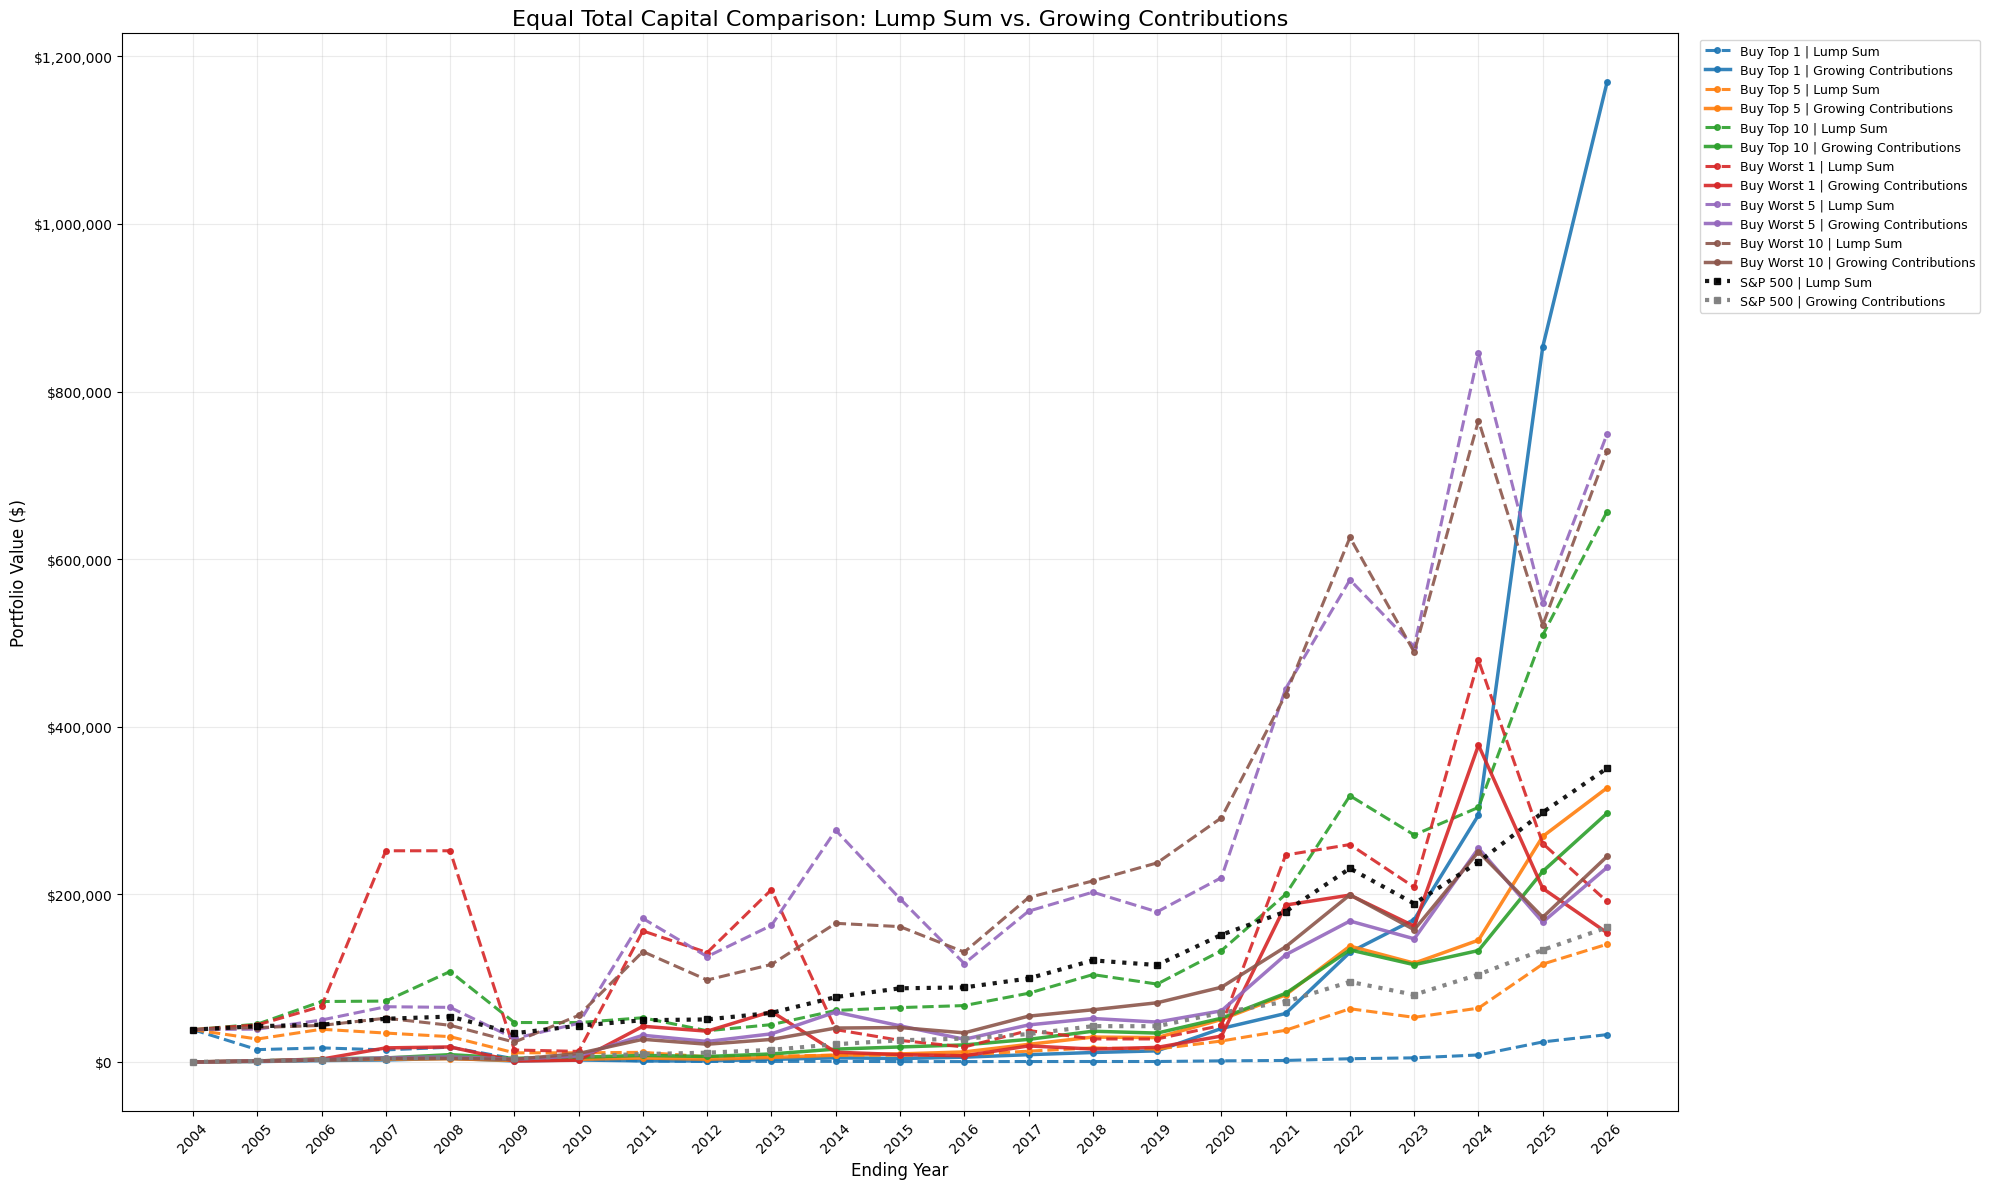

FINAL DOLLAR COMPARISON:
         Strategy  Lump Sum Final Balance  Growing Contributions Final Balance  Dollar Difference Better Capital Timing
      Buy Worst 5               749249.06                            232081.22          517167.84              Lump Sum
     Buy Worst 10               728679.80                            245213.23          483466.57              Lump Sum
       Buy Top 10               656726.16                            296737.35          359988.81              Lump Sum
S&P 500 Benchmark               350448.37                            160521.68          189926.69              Lump Sum
      Buy Worst 1               191438.59                            154142.41           37296.18              Lump Sum
        Buy Top 5               140415.66                            326992.29         -186576.63 Growing Contributions
        Buy Top 1                32564.07                           1168954.41        -1136390.34 Growing Contributions

LINE FORMATTIN

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ============================================================
# 1. SETTINGS
# ============================================================

first_year = 2004
last_year = 2026

# The following dictionaries must already exist from
# the previous scorecard script:
#
# lump_sum_results
# growing_contribution_results
#
# Each dictionary contains:
# Buy Top 1
# Buy Top 5
# Buy Top 10
# Buy Worst 1
# Buy Worst 5
# Buy Worst 10
# S&P 500 Benchmark

strategy_names = [
    "Buy Top 1",
    "Buy Top 5",
    "Buy Top 10",
    "Buy Worst 1",
    "Buy Worst 5",
    "Buy Worst 10"
]

# Keep the same color for each strategy under both scenarios
strategy_colors = {
    "Buy Top 1": "tab:blue",
    "Buy Top 5": "tab:orange",
    "Buy Top 10": "tab:green",
    "Buy Worst 1": "tab:red",
    "Buy Worst 5": "tab:purple",
    "Buy Worst 10": "tab:brown"
}


# ============================================================
# 2. PREPARE GRAPH DATA
# ============================================================

def prepare_graph_data(results_df, starting_value):
    """
    Returns the starting year/value followed by each annual
    ending year and ending balance.
    """

    graph_df = results_df.copy()

    graph_df["Ending Year"] = (
        graph_df["Investment Period"]
        .astype(str)
        .str.split("-")
        .str[1]
        .astype(int)
    )

    graph_df["Ending Balance"] = pd.to_numeric(
        graph_df["Ending Balance"],
        errors="coerce"
    )

    graph_years = (
        [first_year]
        + graph_df["Ending Year"].tolist()
    )

    graph_balances = (
        [starting_value]
        + graph_df["Ending Balance"].tolist()
    )

    return graph_years, graph_balances


# ============================================================
# 3. CREATE GRAPH
# ============================================================

fig, ax = plt.subplots(figsize=(20, 12))

for strategy_name in strategy_names:
    color = strategy_colors[strategy_name]

    # --------------------------------------------------------
    # Lump-sum scenario: dashed line
    # --------------------------------------------------------

    lump_years, lump_balances = prepare_graph_data(
        lump_sum_results[strategy_name],
        starting_value=38505.21
    )

    ax.plot(
        lump_years,
        lump_balances,
        color=color,
        linestyle="--",
        linewidth=2.2,
        marker="o",
        markersize=4,
        alpha=0.90,
        label=f"{strategy_name} | Lump Sum"
    )

    # --------------------------------------------------------
    # Growing-contribution scenario: solid line
    # --------------------------------------------------------

    contribution_years, contribution_balances = (
        prepare_graph_data(
            growing_contribution_results[strategy_name],
            starting_value=0.00
        )
    )

    ax.plot(
        contribution_years,
        contribution_balances,
        color=color,
        linestyle="-",
        linewidth=2.5,
        marker="o",
        markersize=4,
        alpha=0.90,
        label=f"{strategy_name} | Growing Contributions"
    )


# ============================================================
# 4. ADD BOTH S&P 500 BENCHMARKS
# ============================================================

# Lump-sum benchmark
benchmark_lump_years, benchmark_lump_balances = (
    prepare_graph_data(
        lump_sum_results["S&P 500 Benchmark"],
        starting_value=38505.21
    )
)

ax.plot(
    benchmark_lump_years,
    benchmark_lump_balances,
    color="black",
    linestyle=":",
    linewidth=3,
    marker="s",
    markersize=5,
    alpha=0.90,
    label="S&P 500 | Lump Sum"
)

# Growing-contribution benchmark
benchmark_contribution_years, benchmark_contribution_balances = (
    prepare_graph_data(
        growing_contribution_results[
            "S&P 500 Benchmark"
        ],
        starting_value=0.00
    )
)

ax.plot(
    benchmark_contribution_years,
    benchmark_contribution_balances,
    color="gray",
    linestyle=":",
    linewidth=3,
    marker="s",
    markersize=5,
    alpha=0.95,
    label="S&P 500 | Growing Contributions"
)


# ============================================================
# 5. FORMAT THE GRAPH
# ============================================================

ax.set_title(
    "Equal Total Capital Comparison: Lump Sum vs. Growing Contributions",
    fontsize=16
)

ax.set_xlabel(
    "Ending Year",
    fontsize=12
)

ax.set_ylabel(
    "Portfolio Value ($)",
    fontsize=12
)

ax.set_xticks(
    range(first_year, last_year + 1)
)

ax.tick_params(
    axis="x",
    rotation=45
)

# Display dollar values on the y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:,.0f}"
    )
)

ax.grid(
    alpha=0.25
)

# Move the crowded legend outside the chart
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=9,
    frameon=True
)

plt.tight_layout()


# ============================================================
# 6. SAVE AND DISPLAY GRAPH
# ============================================================

graph_path = (
    "/content/"
    "all_strategies_lump_sum_vs_contributions.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. CREATE FINAL DOLLAR COMPARISON
# ============================================================

comparison_rows = []

for strategy_name in (
    strategy_names + ["S&P 500 Benchmark"]
):
    lump_final = pd.to_numeric(
        lump_sum_results[strategy_name][
            "Ending Balance"
        ],
        errors="coerce"
    ).iloc[-1]

    contribution_final = pd.to_numeric(
        growing_contribution_results[strategy_name][
            "Ending Balance"
        ],
        errors="coerce"
    ).iloc[-1]

    comparison_rows.append({
        "Strategy": strategy_name,
        "Lump Sum Final Balance": round(
            lump_final,
            2
        ),
        "Growing Contributions Final Balance": round(
            contribution_final,
            2
        ),
        "Dollar Difference": round(
            lump_final - contribution_final,
            2
        ),
        "Better Capital Timing": (
            "Lump Sum"
            if lump_final > contribution_final
            else "Growing Contributions"
            if contribution_final > lump_final
            else "Equal"
        )
    })

graph_comparison_df = pd.DataFrame(
    comparison_rows
)

graph_comparison_df = (
    graph_comparison_df
    .sort_values(
        "Lump Sum Final Balance",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_path = (
    "/content/"
    "lump_sum_vs_contributions_graph_comparison.csv"
)

graph_comparison_df.to_csv(
    comparison_path,
    index=False
)

print("FINAL DOLLAR COMPARISON:")
print(
    graph_comparison_df.to_string(
        index=False
    )
)

print("\nLINE FORMATTING:")
print("Solid lines: growing annual contributions")
print("Dashed lines: $38,505.21 initial lump sum")
print("Dotted lines: S&P 500 benchmarks")

print("\nFILES SAVED:")
print(graph_path)
print(comparison_path)

In [2]:
from google.colab import drive
from pathlib import Path
import pickle
import shutil

# Mount Google Drive
drive.mount("/content/drive")

# Permanent project folder
project_folder = Path(
    "/content/drive/MyDrive/SP500_Python_Project"
)

project_folder.mkdir(
    parents=True,
    exist_ok=True
)

# Variables to save if they currently exist
variable_names = [
    "df",
    "price_df",
    "top_1_df",
    "top_5_df",
    "top_10_df",
    "worst_1_df",
    "worst_5_df",
    "worst_10_df",
    "top_1_details_df",
    "top_5_details_df",
    "top_10_details_df",
    "worst_1_details_df",
    "worst_5_details_df",
    "worst_10_details_df",
    "benchmark_df",
    "lump_sum_results",
    "growing_contribution_results",
    "growth_category_counts_df",
    "growth_category_counts_with_total_df",
    "strategy_scorecard_df"
]

project_state = {}

for variable_name in variable_names:
    if variable_name in globals():
        project_state[variable_name] = globals()[variable_name]

# Save Python variables
state_path = project_folder / "sp500_project_state.pkl"

with open(state_path, "wb") as file:
    pickle.dump(project_state, file)

# Copy all CSV and PNG outputs from Colab to Drive
files_copied = []

for pattern in ["*.csv", "*.png"]:
    for source_file in Path("/content").glob(pattern):
        destination_file = (
            project_folder / source_file.name
        )

        shutil.copy2(
            source_file,
            destination_file
        )

        files_copied.append(source_file.name)

print("PROJECT SAVED")
print(f"Variables saved: {len(project_state):,}")
print(f"Files copied: {len(files_copied):,}")
print(f"Drive folder: {project_folder}")
print(f"State file: {state_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT SAVED
Variables saved: 20
Files copied: 76
Drive folder: /content/drive/MyDrive/SP500_Python_Project
State file: /content/drive/MyDrive/SP500_Python_Project/sp500_project_state.pkl


In [1]:
from google.colab import drive
from pathlib import Path
import pickle
import shutil

# Mount Google Drive
drive.mount("/content/drive")

project_folder = Path(
    "/content/drive/MyDrive/SP500_Python_Project"
)

state_path = project_folder / "sp500_project_state.pkl"

if not state_path.exists():
    raise FileNotFoundError(
        f"Saved project state not found: {state_path}"
    )

# Restore saved Python variables
with open(state_path, "rb") as file:
    restored_state = pickle.load(file)

globals().update(restored_state)

# Copy saved CSV and PNG files back into /content
for pattern in ["*.csv", "*.png"]:
    for saved_file in project_folder.glob(pattern):
        shutil.copy2(
            saved_file,
            Path("/content") / saved_file.name
        )

print("PROJECT RESTORED")
print(f"Variables restored: {len(restored_state):,}")

print("\nRESTORED VARIABLES:")
print(sorted(restored_state.keys()))

print("\nFILES AVAILABLE IN /content:")
for file_path in sorted(Path("/content").glob("*.csv")):
    print(file_path.name)

Mounted at /content/drive
PROJECT RESTORED
Variables restored: 20

RESTORED VARIABLES:
['benchmark_df', 'df', 'growing_contribution_results', 'growth_category_counts_df', 'growth_category_counts_with_total_df', 'lump_sum_results', 'price_df', 'strategy_scorecard_df', 'top_10_details_df', 'top_10_df', 'top_1_details_df', 'top_1_df', 'top_5_details_df', 'top_5_df', 'worst_10_details_df', 'worst_10_df', 'worst_1_details_df', 'worst_1_df', 'worst_5_details_df', 'worst_5_df']

FILES AVAILABLE IN /content:
S&P 500 Data DUMP - Downloadable DAta.csv
S&P 500 Data DUMP - Sheet1.csv
all_1_5_10_strategies_comparison.csv
annual_1000_contributions_final_comparison.csv
best_previous_year_strategy_results.csv
equal_total_lump_sum_vs_contributions.csv
final_strategy_scorecard.csv
growing_contributions_rollover_comparison.csv
growth_10_to_15_stock_details.csv
growth_10_to_15_strategy_results.csv
lump_sum_vs_contributions_graph_comparison.csv
missing_historical_sp500_rows.csv
over_100_percent_growth_stoc